<a href="https://colab.research.google.com/github/vinechai/sreality_EDA/blob/main/notebooks/03_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
# Save cleaned dataset to Drive
cleaned_path_drive = '/content/drive/My Drive/Colab Notebooks/data/processed/cleaned_apartments_praha.csv'
data.to_csv(cleaned_path_drive, index=False)
print(f" Cleaned dataset saved to: {cleaned_path_drive}")
"""

'\n# Save cleaned dataset to Drive\ncleaned_path_drive = \'/content/drive/My Drive/Colab Notebooks/data/processed/cleaned_apartments_praha.csv\'\ndata.to_csv(cleaned_path_drive, index=False)\nprint(f" Cleaned dataset saved to: {cleaned_path_drive}")\n'

In [ ]:
"""
# Save locally to your repo folder
cleaned_path_local = '../data/processed/cleaned_apartments_praha.csv'
data.to_csv(cleaned_path_local, index=False)
print(f" Cleaned dataset saved locally to: {cleaned_path_local}")
"""

'\n# Save locally to your repo folder\ncleaned_path_local = \'../data/processed/cleaned_apartments_praha.csv\'\ndata.to_csv(cleaned_path_local, index=False)\nprint(f" Cleaned dataset saved locally to: {cleaned_path_local}")\n'

In [ ]:
# Standard libraries
import os
import sys
import time
import copy
import math

from time import time #  project timer


# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Sklearn (models & preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 250)

# Set random seed for reproducibility
SEED = 42

# Project paths
DATA_DIR = os.path.join("data")
RAW_FILE = os.path.join(DATA_DIR, "updated_apartments_praha.csv")



from IPython.display import display, HTML
import missingno as msno
import re


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, HTML

!pip install dython
from dython import nominal # Correlations between categorical variables

# 3. Exploratory Data Analysis (EDA)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

cleaned_model_ready_path = '/content/drive/My Drive/Colab Notebooks/data/processed/cleaned_model_ready.parquet'
data = pd.read_parquet(cleaned_model_ready_path)
print("✅ Cleaned dataset loaded for EDA.")

Mounted at /content/drive
✅ Cleaned dataset loaded for EDA.


In [ ]:
"""
import pandas as pd

data = pd.read_csv('../data/processed/cleaned_apartments_praha.csv')
print("✅ Cleaned dataset loaded for EDA.")
"""

'\nimport pandas as pd\n\ndata = pd.read_csv(\'../data/processed/cleaned_apartments_praha.csv\')\nprint("✅ Cleaned dataset loaded for EDA.")\n'

In [ ]:
"""
#Instead of hardcoding paths everywhere, create a small config.py file in your repo root:
# config.py
DATA_RAW = "data/raw/updated_apartments_praha.csv"
DATA_PROCESSED = "data/processed/cleaned_apartments_praha.csv"
MODEL_PATH = "src/model.joblib"

from config import DATA_PROCESSED
data = pd.read_csv(DATA_PROCESSED)
"""

'\n#Instead of hardcoding paths everywhere, create a small config.py file in your repo root:\n# config.py\nDATA_RAW = "data/raw/updated_apartments_praha.csv"\nDATA_PROCESSED = "data/processed/cleaned_apartments_praha.csv"\nMODEL_PATH = "src/model.joblib"\n\nfrom config import DATA_PROCESSED\ndata = pd.read_csv(DATA_PROCESSED)\n'

### 3.1 Non-Numeric Data Exploration



In [ ]:
# Identify categorical variables
categorical = data.select_dtypes(include=['object', 'category']).columns
print('There are {} categorical variables \n'.format(len(categorical)))


There are 13 categorical variables 



/tmp/ipython-input-1766386935.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = data.select_dtypes(include=['object', 'category']).columns


In [ ]:
categorical

Index(['building', 'property_status', 'ownership', 'property_location',
       'water', 'heating', 'gas', 'energy_performance_rating', 'waste',
       'street', 'district', 'cadastral_area', 'layout'],
      dtype='str')

##### 3.1.1 Missing Values in Categorical Columns

In [ ]:
# Calculate percentage of missing values
cat_missing = data[categorical].isna().mean() * 100

# Display columns with missing values
missing_cats = cat_missing[cat_missing > 0].sort_values(ascending=False)
if not missing_cats.empty:
    print("Categorical columns with missing values (%):")
    display(missing_cats.to_frame("Missing %"))
else:
    print("No missing values found in categorical variables.")


Categorical columns with missing values (%):


,Missing %
gas,75.034965
water,54.662005
waste,49.230769
energy_performance_rating,18.578089
ownership,8.321678
building,8.321678
property_status,8.321678
street,3.752914
property_location,1.398601
cadastral_area,1.305361


##### 3.1.2 Explore Categorical Variables

In [ ]:
from IPython.display import display, HTML

exclude_columns = ['location', 'street', 'cadastral_area']

for var in categorical:
    if var in exclude_columns:
        continue  # skip identifiers

    # Frequency and percentage
    value_counts = data[var].value_counts(dropna=False)
    value_perc = (value_counts / len(data) * 100).round(2)

    summary = pd.concat([value_counts, value_perc], axis=1, keys=['Count', 'Percentage'])
    print(f"\n {var} — {data[var].nunique()} unique values:")
    display(HTML(summary.to_html()))



 building — 6 unique values:


,Count,Percentage
building,,
Brick,2089,48.69
Mixed,1009,23.52
Panel,542,12.63
NaN,357,8.32
Framed structure,283,6.60
Stone,7,0.16
Wooden,3,0.07



 property_status — 8 unique values:


,Count,Percentage
property_status,,
In very good condition,1299,30.28
New homes,917,21.38
Under construction,567,13.22
Renovated,454,10.58
In good condition,387,9.02
NaN,357,8.32
New development projects,187,4.36
For renovation,91,2.12
In renovation,31,0.72



 ownership — 3 unique values:


...

,Count,Percentage
waste,,
Sewerage,2167,50.51
NaN,2112,49.23
other,11,0.26



 district — 10 unique values:


,Count,Percentage
district,,
Praha 5,867,20.21
Praha 9,785,18.30
Praha 4,709,16.53
Praha 10,470,10.96
Praha 6,349,8.14
Praha 3,310,7.23
Praha 8,281,6.55
Praha 1,201,4.69
Praha 2,188,4.38



 layout — 12 unique values:


,Count,Percentage
layout,,
2+kt,1367,31.86
3+kt,1038,24.20
1+kt,554,12.91
4+kt,422,9.84
3+1,340,7.93
2+1,243,5.66
1+1,86,2.00
4+1,84,1.96
5+kt,80,1.86


##### 3.1.3 Correlation Analysis for Categorical Variables.


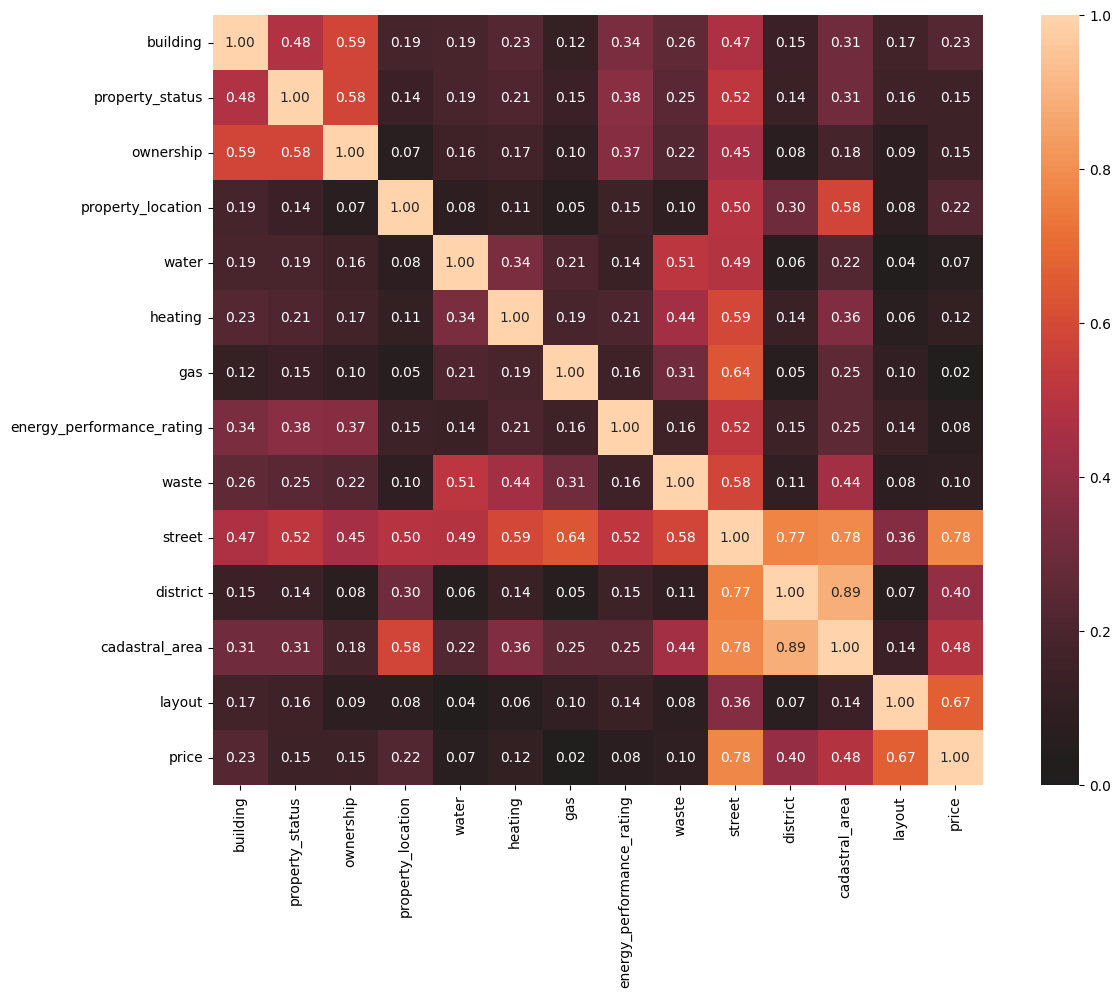

price                        1.000000
street                       0.779754
layout                       0.667226
cadastral_area               0.484804
district                     0.401993
building                     0.226889
property_location            0.222617
property_status              0.154704
ownership                    0.149665
heating                      0.116555
waste                        0.100604
energy_performance_rating    0.076412
water                        0.066434
gas                          0.019686
Name: price, dtype: float64


In [ ]:
# Correlation for non-numeric variables
# copy dataset for categorical associations
data_corr = data.copy()

# changing missing values in categorical variables to 'Missing'
for var in categorical:
    data_corr[var] = data_corr[var].fillna('Missing') #better don't use inplace = True, better assign value to a variable;

target = 'price'
categorical = categorical.tolist()
cols = categorical + [target]

corr_nom = nominal.associations(data_corr[cols],figsize=(15,10))


# Extract correlations with the target
category_correlations = corr_nom["corr"][target].sort_values(ascending=False)
print(category_correlations)


Findings:

1. High cardinality of location based features
- street shows a very strong correlation with price (0.78), but it has 1397 unique values, making it a high-cardinality variable.

- district and cadastral_area correlate moderately with price (0.40 and 0.49), and are also highly correlated with each other (~0.89), meaning they provide largely overlapping location information.

We'll need a further analysis to understand which location variable is more suitable for modelling.

2. Low-correlation variables with excessive missing data.

Variables related to building utilities (gas, water, heating, waste) have very low correlation with price.

These variables also contain substantial missing data and many rare categories, making them unreliable predictors. Dropping them might be justified.


3. Energy performance rating as a numeric variable
- energy_performance_rating shows weak correlation with price (0.08), but it is inherently ordinal (A is the highest score, G is the lowest)

Convert it to numeric but only after train/test split



##### 3.1.4 Visualize Target by Categories

In [ ]:
def var_boxplot(var, data, target, title, xrotate=0, show_freq_table=True):
    """
    Boxplot of target by categorical variable, ordered by median target value.
    """
    temp = data.copy()

    order = (
        temp.groupby(var)[target]
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(14, 7))
    sns.boxplot(
        x=var,
        y=target,
        data=temp,
        order=order,
        linewidth=1.5
    )

    plt.title(title, fontsize=16, weight='bold')
    plt.xlabel(var)
    plt.ylabel(target.capitalize())
    plt.xticks(rotation=xrotate)
    plt.tight_layout()
    plt.show()

    if show_freq_table:
        value_counts = pd.concat([
            temp[var].value_counts(),
            temp[var].value_counts(normalize=True).mul(100)
        ], axis=1, keys=['Count', 'Percentage'])

        print(f"\n{var}: {temp[var].nunique()} unique values")
        display(HTML(value_counts.to_html()))



def var_boxplot_top_n(
    var, data, target, title,
    top_n=None, bottom_n=None, min_count=0,
    xrotate=45
):
    """Boxplot for top or bottom N categories by target median."""
    temp = data.copy()

    # Count observations per category
    counts = temp[var].value_counts()
    valid_categories = counts[counts >= min_count].index

    temp = temp[temp[var].isin(valid_categories)]

    group_medians = temp.groupby(var)[target].median()

    # Determine which categories to include
    if top_n is not None:
        selected = group_medians.nlargest(top_n).index
    elif bottom_n is not None:
        selected = group_medians.nsmallest(bottom_n).index
    else:
        raise ValueError("Specify either top_n or bottom_n.")

    # Group the rest under 'Other'
    temp[var + '_grouped'] = temp[var].where(temp[var].isin(selected), 'Other')

    # Ordering for boxplot
    order = (
        temp.groupby(var + '_grouped')[target]
        .median()
        .sort_values(ascending=False)
        .index
    )

    # Plot
    plt.figure(figsize=(14, 7))
    sns.boxplot(
        x=var + '_grouped',
        y=target,
        data=temp,
        order=order,
        linewidth=1.5
    )
    plt.title(title, fontsize=15, weight='bold')
    plt.xticks(rotation=xrotate)
    plt.show()

For most categorical comparisons we'll use price per square meter instead of total price.
This helps reduce the dominant effect of apartment size and will make it easier to understand the effect of location, building quality, and ownership effects and so on.
Total price is still used where appropriate and remains the final modeling target.

In [ ]:
data['price_per_m2'] = data['price'] / data['square_meters']

### Property Status

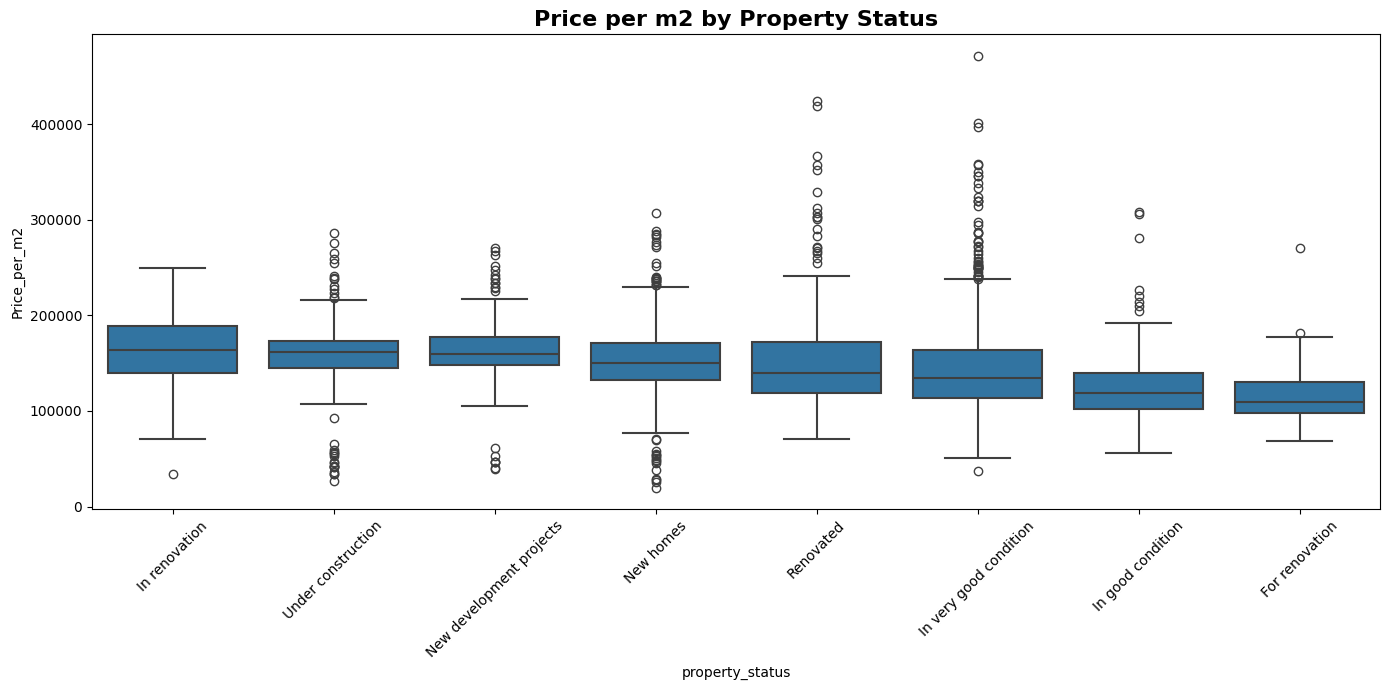


property_status: 8 unique values


,Count,Percentage
property_status,,
In very good condition,1299,33.028223
New homes,917,23.315535
Under construction,567,14.416476
Renovated,454,11.543351
In good condition,387,9.839817
New development projects,187,4.754640
For renovation,91,2.313755
In renovation,31,0.788202


In [ ]:
var_boxplot(
    var='property_status',
    data=data,
    target='price_per_m2',
    title='Price per m2 by Property Status',
    xrotate=45
)

Apartments labeled as 'In renovation' show the highest median price per square meter. However, this category contains very few observations (only 31).

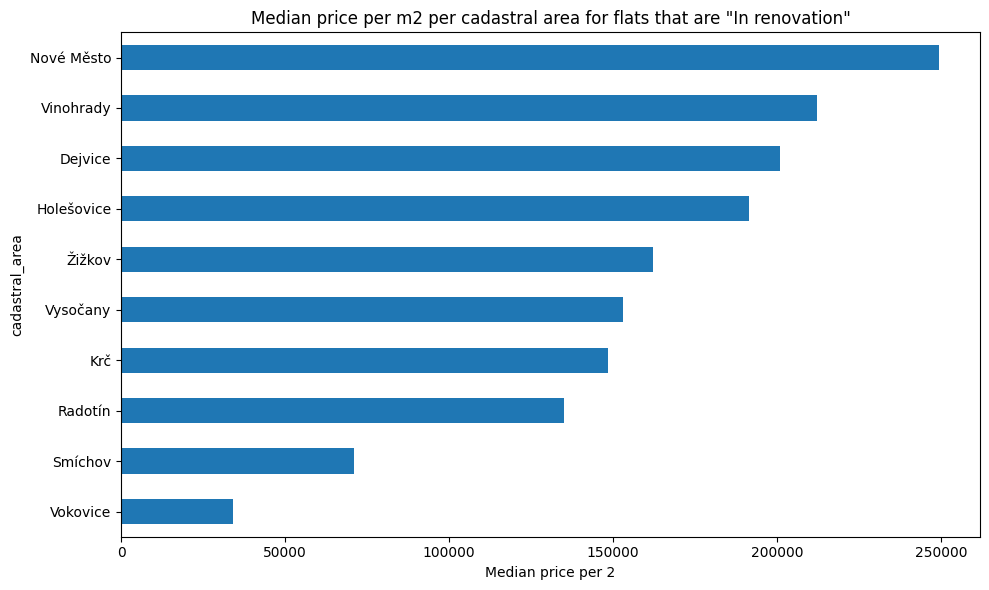

In [ ]:
temp = data[data['property_status'] == 'In renovation'].copy()
group_medians = temp.groupby('cadastral_area')['price_per_m2'].median()
group_medians

group_medians.sort_values().plot(kind='barh', figsize=(10, 6))
plt.xlabel('Median price per 2')
plt.title('Median price per m2 per cadastral area for flats that are "In renovation"')
plt.tight_layout()
plt.show()

Apartments labeled as 'In renovation' are heavily concentrated in expensive central areas such as Nové Město, Vinohrady, and Dejvice and might include some premium and luxury flats.

A small number of very expensive properties in these locations strongly influences the distribution, making the median less representative. Because of that we should be careful when interpreting results for 'In renovation' category.

'Under construction' properties also show high prices, which is expected given their similarity to new homes in terms of quality and location.

### Property location

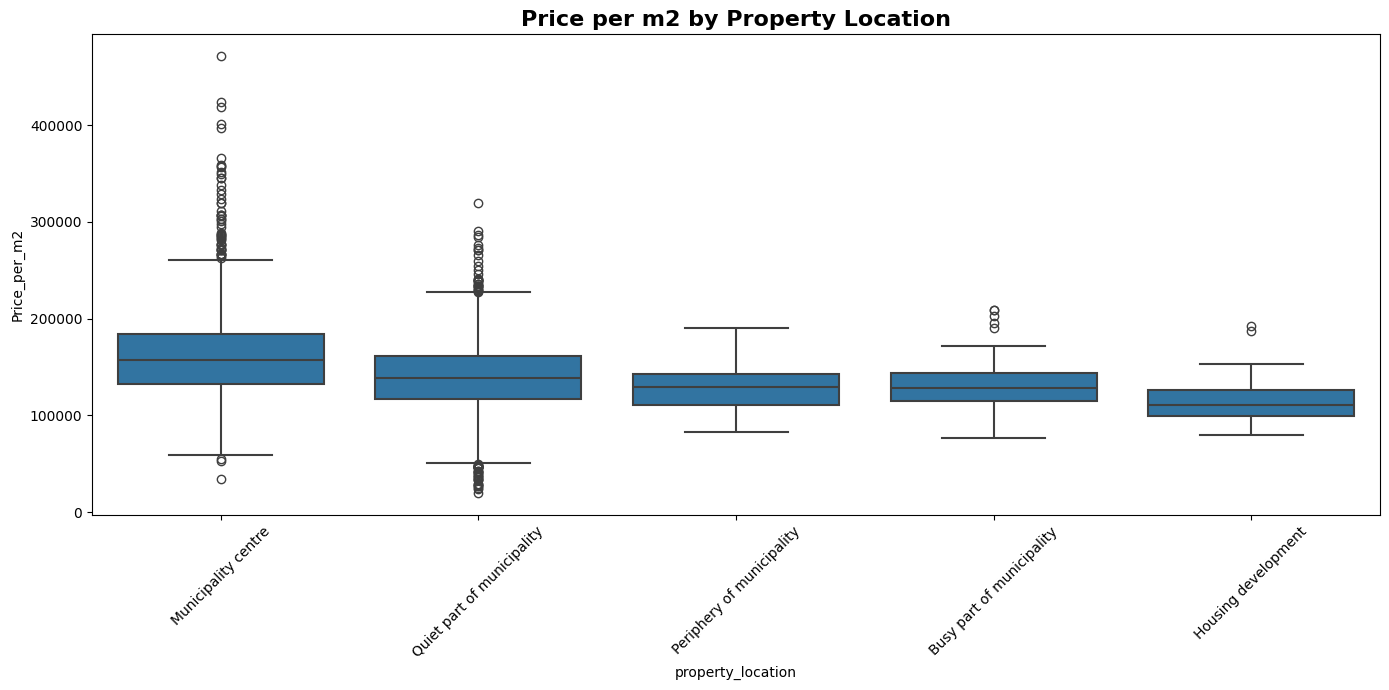


property_location: 5 unique values


,Count,Percentage
property_location,,
Quiet part of municipality,2608,61.654846
Municipality centre,1429,33.782506
Housing development,114,2.695035
Periphery of municipality,41,0.969267
Busy part of municipality,38,0.898345


In [ ]:
var_boxplot(
    var='property_location',
    data=data,
    target='price_per_m2',
    title='Price per m2 by Property Location',
    xrotate=45
)


- Properties located in the municipality center are the most expensive, which is expected.
- Housing developments show the lowest median prices, despite often being newer buildings. But it's possible that housing development means something different in this classification, needs further investigation
- properties in busy parts of the municipality also tend to have lower prices.
- there're 2 very small categories - “Busy part of municipality” and “Periphery of municipality”, so their interpretation and analysis is limited.



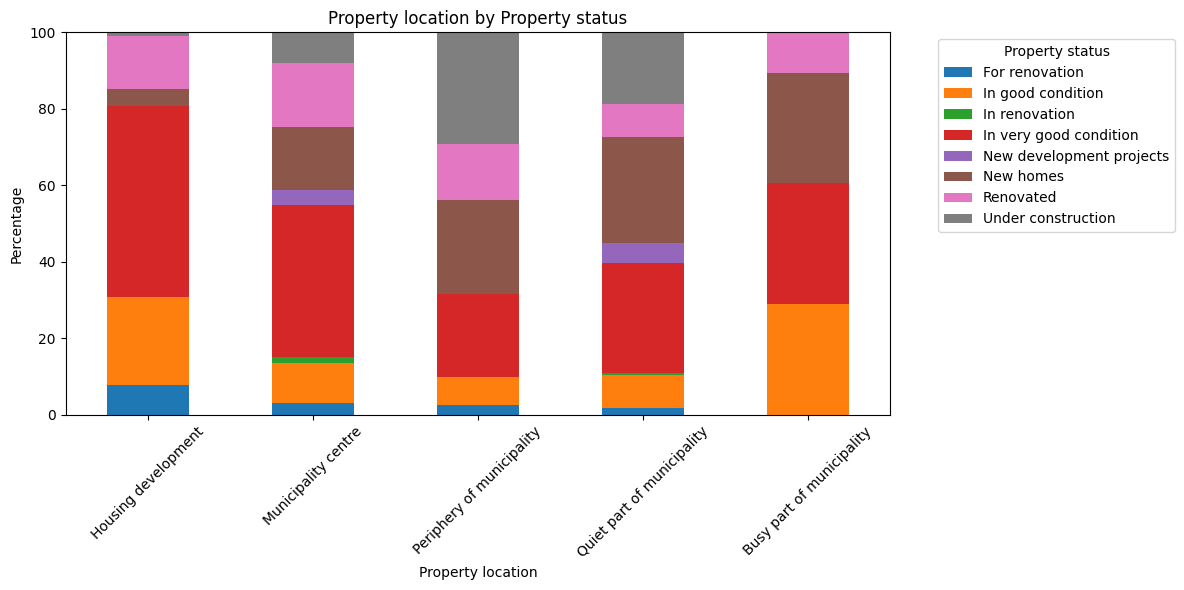

In [ ]:
location_dist = (
    pd.crosstab(data['property_location'], data['property_status'], normalize='index').sort_values(by = 'New homes') * 100
).round(2)

pd.set_option('display.max_rows', 500)

location_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color = sns.color_palette("tab10")
    )

plt.ylabel('Percentage')
plt.xlabel('Property location')
plt.xticks(rotation=45)
plt.title('Property location by Property status')
plt.legend(title='Property status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

As we can see very small number of flats in 'Housing development' are actually new homes, in fact this category has the smallest share of new homes. It's not clear what housing development exactly means but it's clear that the label does not consistently correspond to modern developments and may include older apartments. Also it has high number of 'For renovation' and 'In good condition' properties, which are the cheapest based on the previous analysis.

Due to limited availability of construction year data, this interpretation cannot be precise.

As we can see, the only categories that give us reliable information and price difference are the 2 biggest categories - "Quiet part of municipality"	and
"Municipality centre". Other categories might be ambigious in definition or too small to draw conclusions. So any analysis results that include this variable should be interpreted cautiously.

### Cadastral Area

Some cadastral areas contain very few observations in the dataset (for example Velká Chuchle has only 2 and it ends up with some of the highest median price). To avoid misleading conclusions we'll only include areas with at least five listings. The boxplot function was altered and now includes min_count parameter.

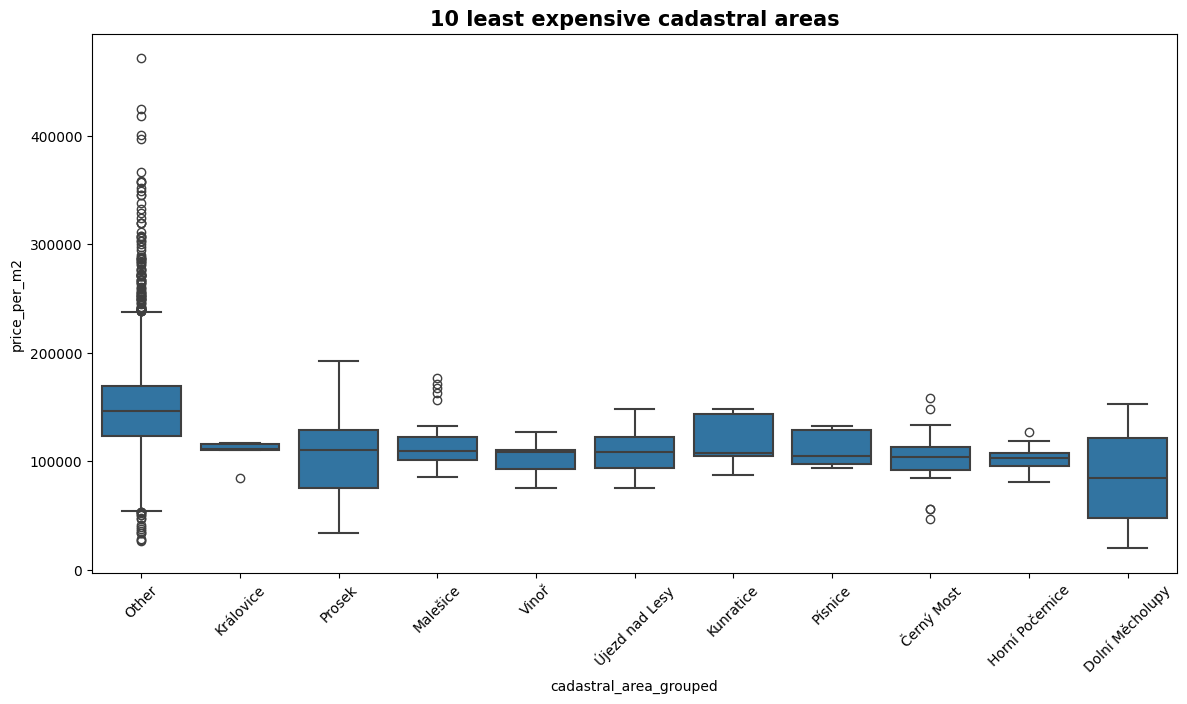

In [ ]:
var_boxplot_top_n(
    var="cadastral_area",
    data=data,
    target="price_per_m2",
    bottom_n=10,
    min_count=5,
    title="10 least expensive cadastral areas"
)

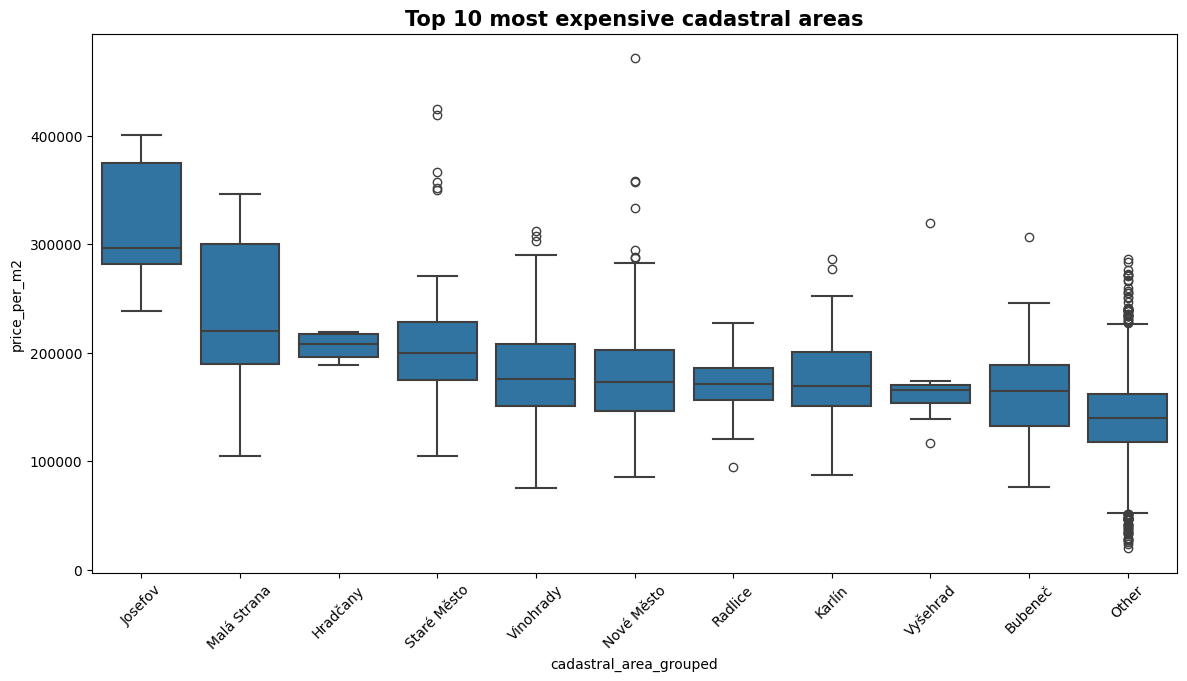

In [ ]:
var_boxplot_top_n(
    var="cadastral_area",
    data=data,
    target="price_per_m2",
    top_n=10,
    min_count=5,
    title="Top 10 most expensive cadastral areas"
)

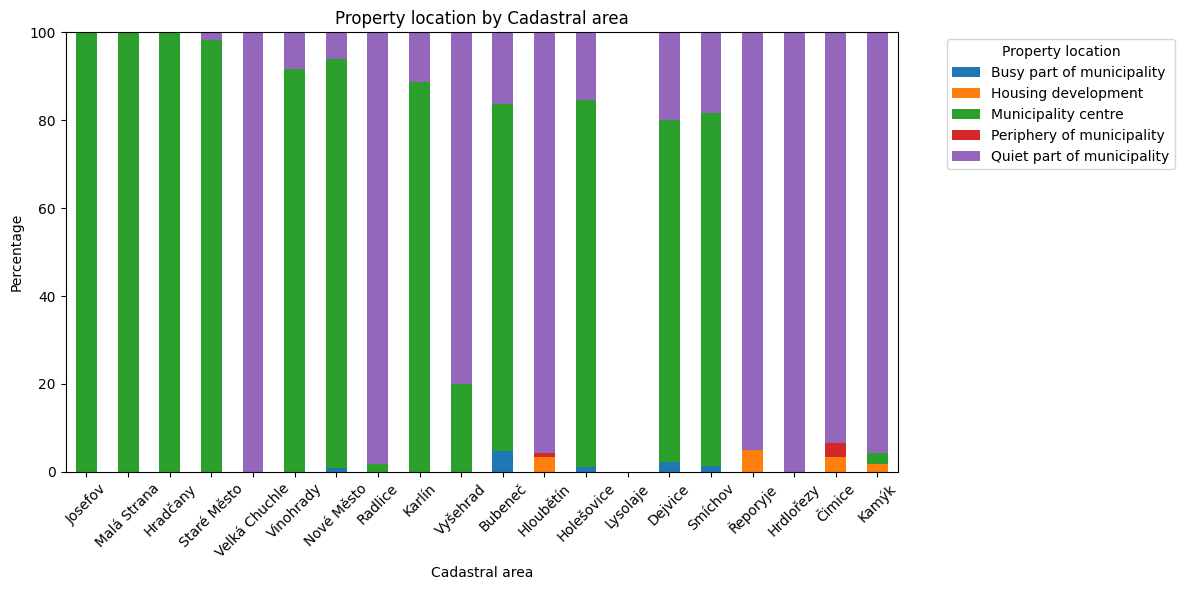

In [ ]:
top_areas = (
    data.groupby('cadastral_area')['price_per_m2']
    .median()
    .nlargest(20)
    .index
)

data_top = data[data['cadastral_area'].isin(top_areas)]


district_dist = (
    pd.crosstab(data_top['cadastral_area'], data_top['property_location'], normalize='index').sort_values(by = 'Municipality centre', ascending = False) * 100).round(2).reindex(top_areas.tolist())
district_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color = sns.color_palette()
)

plt.ylabel('Percentage')
plt.xlabel('Cadastral area')
plt.xticks(rotation=45)
plt.title('Property location by Cadastral area')
plt.legend(title='Property location', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


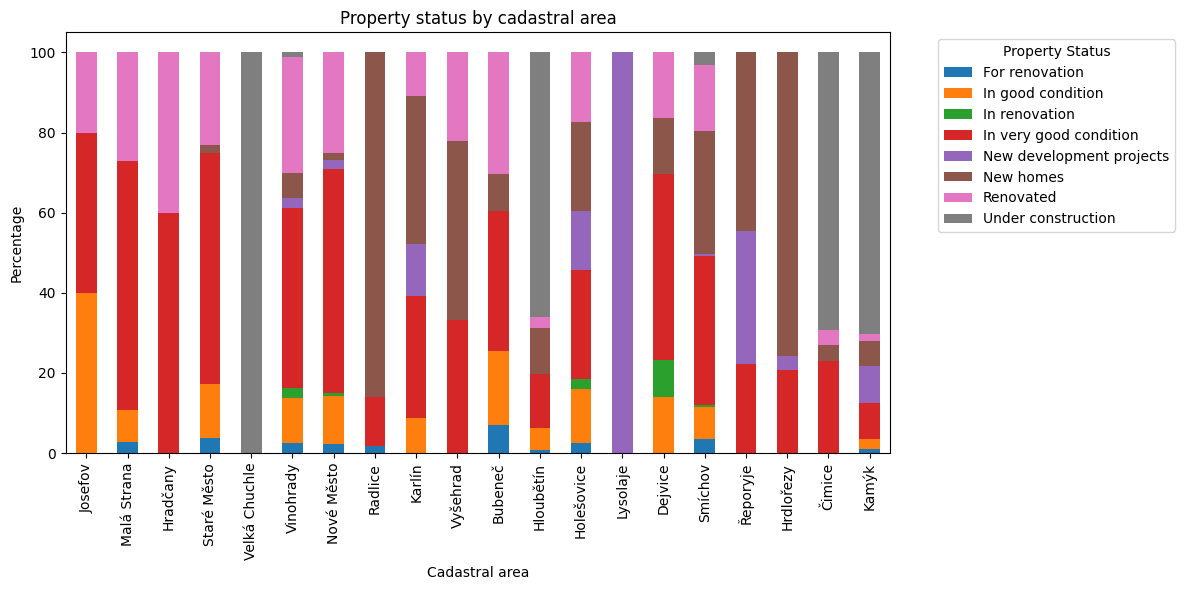

In [ ]:
district_dist = (
    pd.crosstab(data_top['cadastral_area'], data_top['property_status'], normalize='index').sort_values(by = 'New homes', ascending = False) * 100).round(2).reindex(top_areas.tolist())
district_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color = sns.color_palette()
)

plt.ylabel('Percentage')
plt.xlabel('Cadastral area')
plt.title('Property status by cadastral area')
plt.legend(title='Property Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Some of the most expesive areas are in the historical areas in the city center. Those that are not in the center are usually located in the quite parts of the city and have a large proportion of new homes (Radlice, Hrdlorezy), new development projects (Lysolaje), or under construction (Hloubetin, Cimice, Kamyk).

It seems that proximity to the center and amount of new development is detrimental to the price per m2 in any given area.

### District

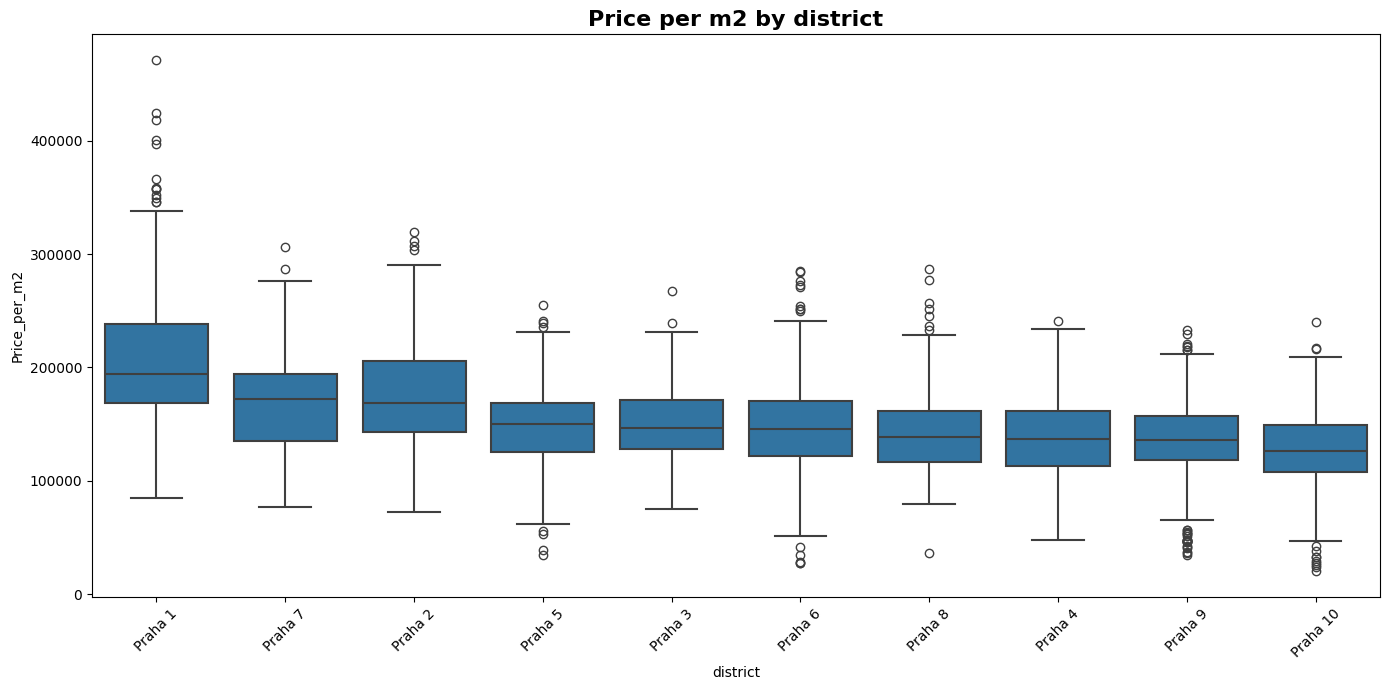


district: 10 unique values


,Count,Percentage
district,,
Praha 5,867,20.290194
Praha 9,785,18.371168
Praha 4,709,16.592558
Praha 10,470,10.999298
Praha 6,349,8.167564
Praha 3,310,7.254856
Praha 8,281,6.576176
Praha 1,201,4.703955
Praha 2,188,4.399719


In [ ]:
var_boxplot(
    var='district',
    data=data,
    target="price_per_m2",
    title='Price per m2 by district',
    xrotate=45
)

Prague is now divided into 57 city districts, the division into 10 districts is outdated and it means that each district covers a very extensive and diverse area.

For example Prague 10 would cover the area from some of the most central and most expensive cadastral areas (part of Vinohrady belongs to Prague 10) to some of the most distant and cheapest ones (Dolní Měcholupy, the cheapest cadastral area, also belongs to Prague 10). Despite having a pretty good mix of new homes and flats in very good condition Praha 10 still remains the cheapest district.

Median price is very similar for quite a few areas, meaning that there's a big mix of new and old, central and perifpheral areas in each district, making their medians pretty similar.

While it still has a pretty high association with price (although lower then cadastral_area) it seems that district alone might not be a very good price predictor, maybe it can be useful when paired with propety status or some other metrics.

In case we need to chose only one location variable cadastral_area seems to be more granular and potentially more predictive then district.

### Layout

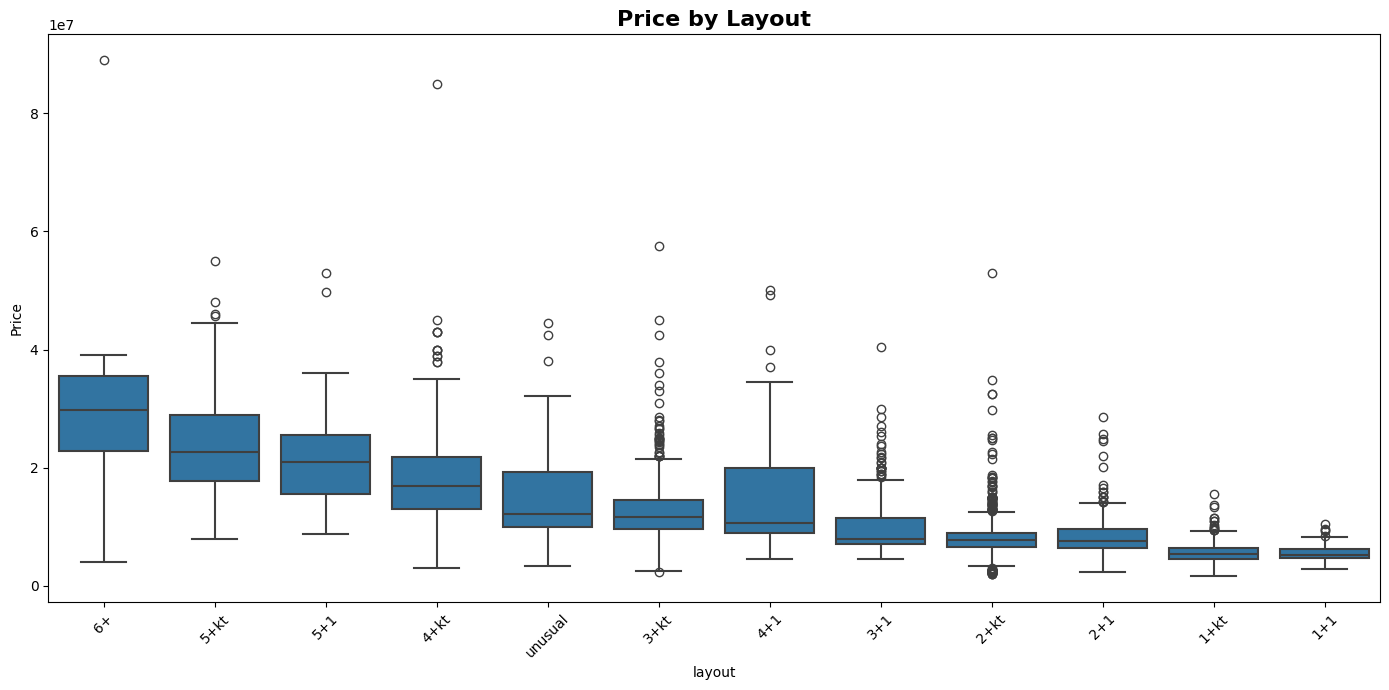


layout: 12 unique values


,Count,Percentage
layout,,
2+kt,1367,31.864802
3+kt,1038,24.195804
1+kt,554,12.913753
4+kt,422,9.836830
3+1,340,7.925408
2+1,243,5.664336
1+1,86,2.004662
4+1,84,1.958042
5+kt,80,1.864802


In [ ]:
var_boxplot(
    var='layout',
    data=data,
    target=target,
    title='Price by Layout',
    xrotate=45
)


Layout is one of the strongest predictors for the price based on nominal association.
Surprisingly, layouts with a kitchenette (+kt) are consistently more expensive than layouts with +1.
For example, 1+kt apartments are priced higher than 1+1.

Possible explanation is that apartments with a kitchenette tend to be newer, better located, or have a modern design.

Overall, layout alone does not fully capture apartment size or quality, and modern compact layouts can be priced higher than larger but outdated ones.

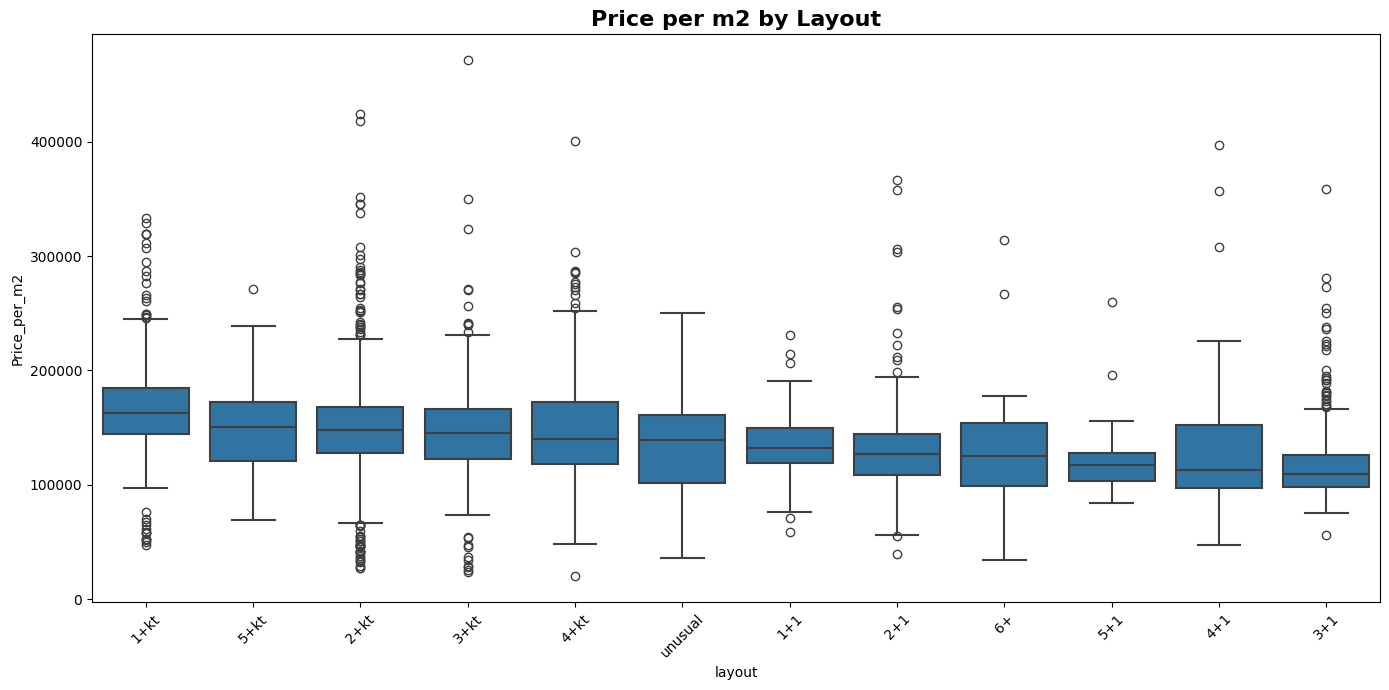


layout: 12 unique values


,Count,Percentage
layout,,
2+kt,1367,31.864802
3+kt,1038,24.195804
1+kt,554,12.913753
4+kt,422,9.836830
3+1,340,7.925408
2+1,243,5.664336
1+1,86,2.004662
4+1,84,1.958042
5+kt,80,1.864802


In [ ]:
var_boxplot(
    var='layout',
    data=data,
    target='price_per_m2',
    title='Price per m2 by Layout',
    xrotate=45
)


Price per m2 is also more expesive for +kt flats, 1+kt being the most expensive.

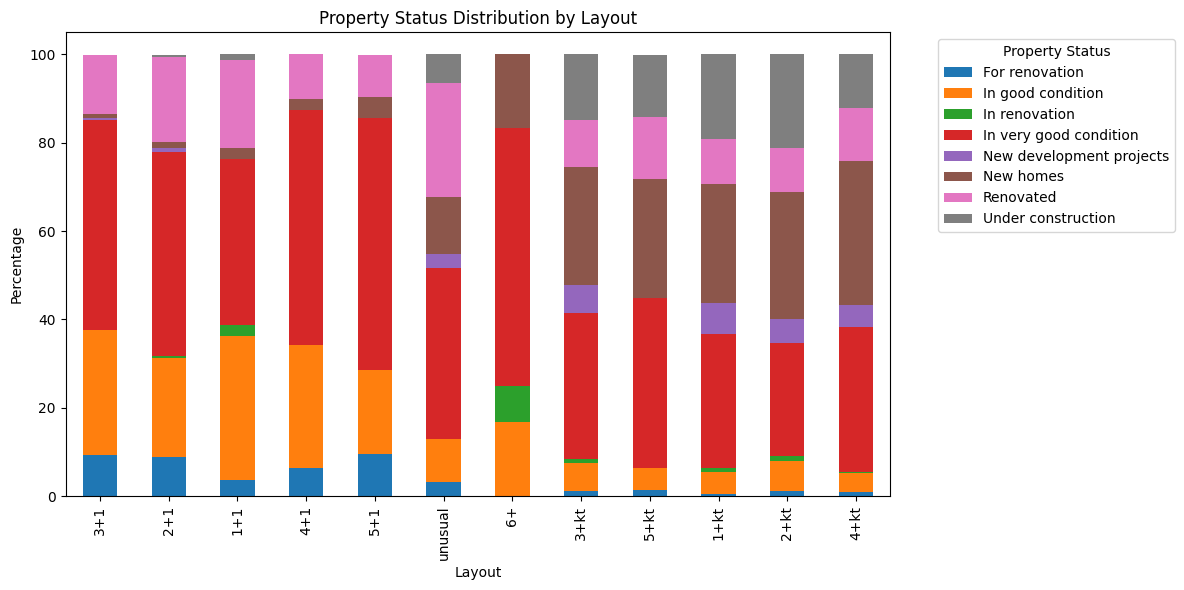

In [ ]:
layout_dist = (
    pd.crosstab(data['layout'], data['property_status'], normalize='index').sort_values(by = 'New homes') * 100
).round(2)

layout_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.ylabel('Percentage')
plt.xlabel('Layout')
plt.title('Property Status Distribution by Layout')
plt.legend(title='Property Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


Crosstab analysis reveals that +kt layouts have a much higher share of new homes, new development projects and appartments under construction, while +1 layouts seem to be rarely found in the newer apartments.


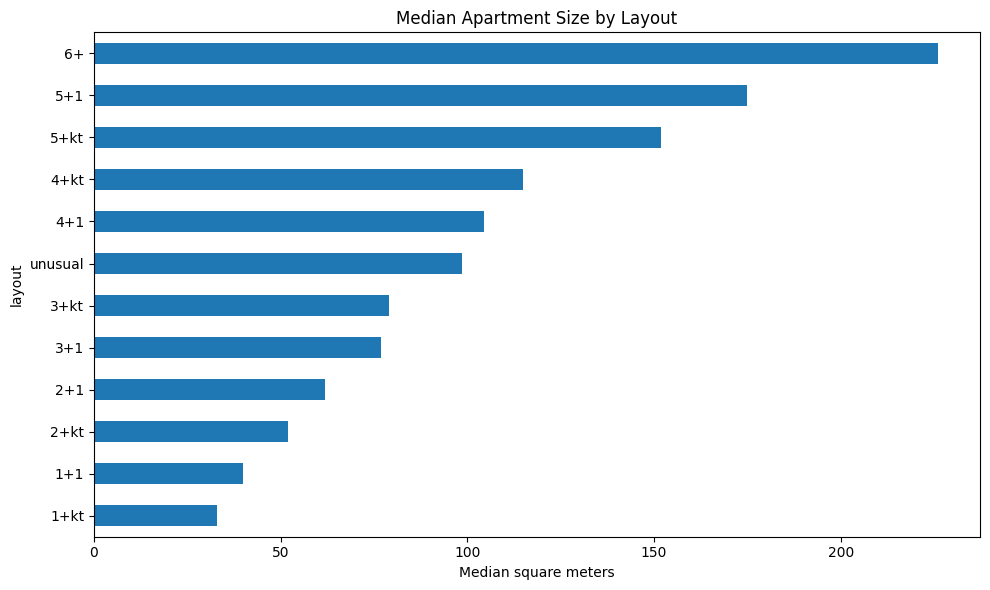

In [ ]:
temp = data.copy()
group_medians = temp.groupby('layout')['square_meters'].median()

group_medians.sort_values().plot(kind='barh', figsize=(10, 6))
plt.xlabel('Median square meters')
plt.title('Median Apartment Size by Layout')
plt.tight_layout()
plt.show()


Layout analysis shows that apartments with a kitchenette are often smaller than +1, but still more expensive.

This suggests that higher prices of +kt apartments are rather driven by building age and quality but not necessary the size.

### Ownership type

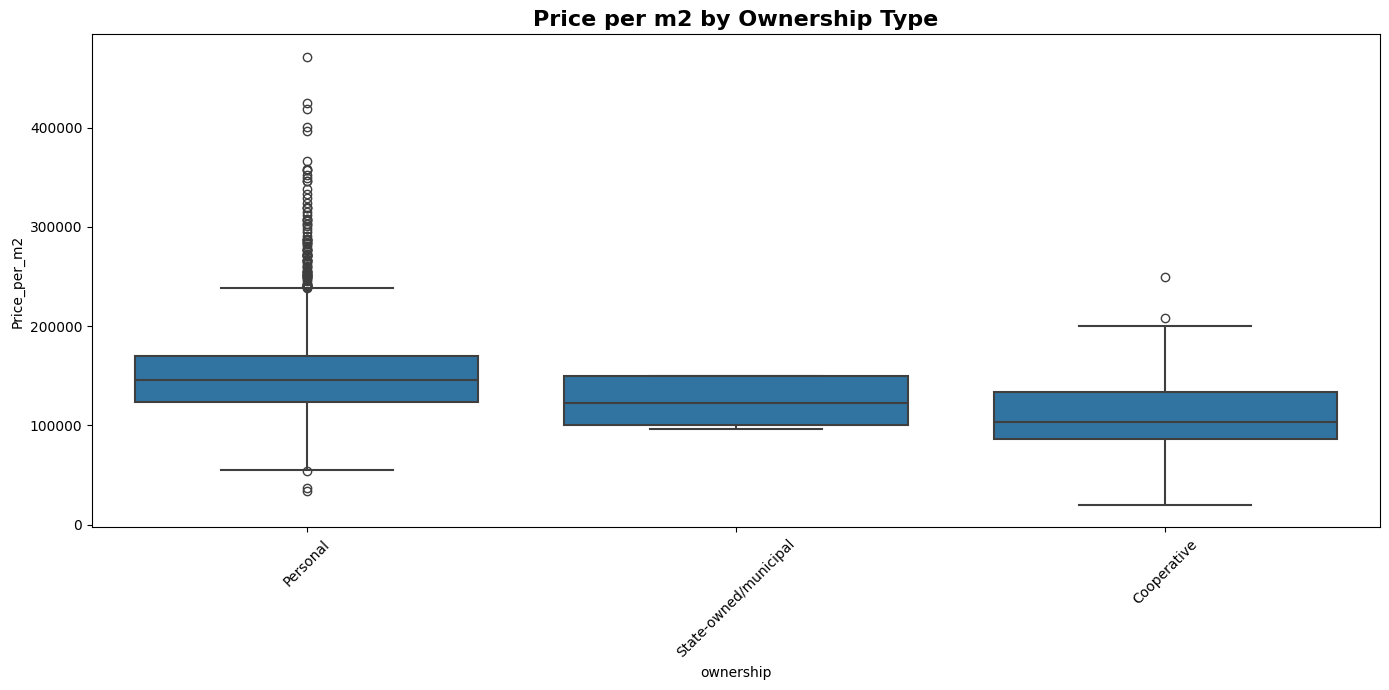


ownership: 3 unique values


,Count,Percentage
ownership,,
Personal,3681,93.592677
Cooperative,245,6.229341
State-owned/municipal,7,0.177981


In [ ]:
var_boxplot(
    var='ownership',
    data=data,
    target='price_per_m2',
    title='Price per m2 by Ownership Type',
    xrotate=45
)


- State-owned properties represent a negligible fraction of the data (only 7 properties).

- Cooperative ownership units are the cheapest but it's very likely that the price does not reflect the full price of the property, but only part of it as another part of the price may be payed in annuities or ongoing payments

Overall, ownership type is heavily imbalanced, one category represents 93% of properties while the rest is either has questionable values in our target (price is not full) or has a very minimal share (0.17%).

We should consider excluding this variable from modeling and probably also remove the cooperative flats due to not full values in the target.

### Building type

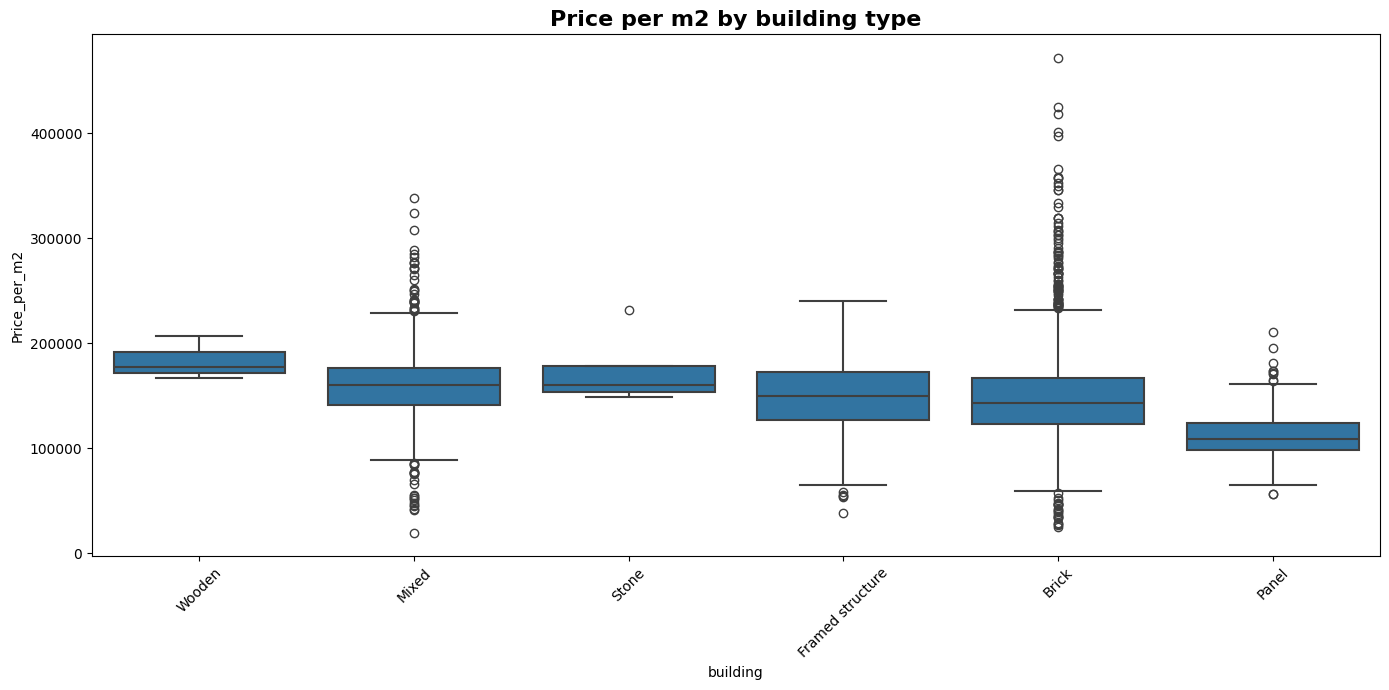


building: 6 unique values


,Count,Percentage
building,,
Brick,2089,53.114671
Mixed,1009,25.654717
Panel,542,13.780829
Framed structure,283,7.195525
Stone,7,0.177981
Wooden,3,0.076278


In [ ]:
var_boxplot(
    var='building',
    data=data,
    target='price_per_m2',
    title='Price per m2 by building type',
    xrotate=45
)

- Stone buildings show the highest median price, but they represent less than 1% of the dataset and likely reflect rare, historical or luxury buildings. Same can be said about Stone buildings. So these results are not statistically reliable.

- Panel buildings are the cheapest category, which most likely corresponds to the building complexes from socialist era.

- Brick properties are the most common and even thouth they rank low in median price they have a lot of outliers in both directions.

Overall it seems that even though building type is a good price predictor, this variable alone is insufficient and most likely interaction with location, condition and age of the apartments is critical.

We'll most likely need to group rare categories for modeling.

Conclusions and next steps:
- 'cadastral_area' seems to be a more precise location variable than 'district'
- remove cooperative flats from dataset and don't use 'ownership_type' variable for modeling
- consider grouping rare categories in 'building', 'property_status' and 'property_location'

### 3.2 Numeric Data Exploration

3.2.1 Basic information


In [ ]:
# Identifying numerical variables
numerical = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Total numeric variables: {len(numerical)}')

# Identifying discrete variables
levels_discrete = 30
discrete = [var for var in numerical if data[var].nunique() < levels_discrete]
print(f'Discrete variables: {discrete}')

# Identifying continuous variables
continuous = [var for var in numerical if var not in discrete]
print(f'Continuous variables: {continuous}')


Total numeric variables: 18
Discrete variables: ['energy_performance_certificate', 'furnished', 'parking', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors']
Continuous variables: ['price', 'usable_area', 'floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'final_building_approval_year', 'square_meters', 'price_per_m2']


In [ ]:
# Checking for missing values
num_miss = data[numerical].isnull().mean() * 100
print(num_miss[num_miss > 0].sort_values(ascending=False))


final_building_approval_year    67.202797
floorage                        41.048951
total_floors                    26.666667
usable_area                      8.321678
floor_number                     8.321678
dtype: float64


In [ ]:
# Summary stats
data[numerical].describe().T


,count,mean,std,min,25%,50%,75%,max
price,4290.0,1.062541e+07,6.479905e+06,1.590000e+06,6.714458e+06,8.660849e+06,1.250000e+07,8.900000e+07
usable_area,3933.0,7.410069e+01,4.069920e+01,1.000000e+01,4.900000e+01,6.600000e+01,8.800000e+01,5.370000e+02
floorage,2529.0,7.113523e+01,3.494546e+01,1.000000e+01,4.900000e+01,6.400000e+01,8.400000e+01,3.890000e+02
balcony,4290.0,1.439627e+00,3.671040e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.500000e+01
energy_performance_certificate,4290.0,1.081585e-01,3.106167e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
furnished,4290.0,1.762238e-01,3.810549e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
terrace,4290.0,4.104429e+00,1.474850e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+02
cellar,4290.0,1.246853e+00,3.117336e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+02
parking,4290.0,2.006993e-01,1.255828e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+01
garden_area,4290.0,8.625175e+00,5.414172e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+03


3.2.2 Visualizations

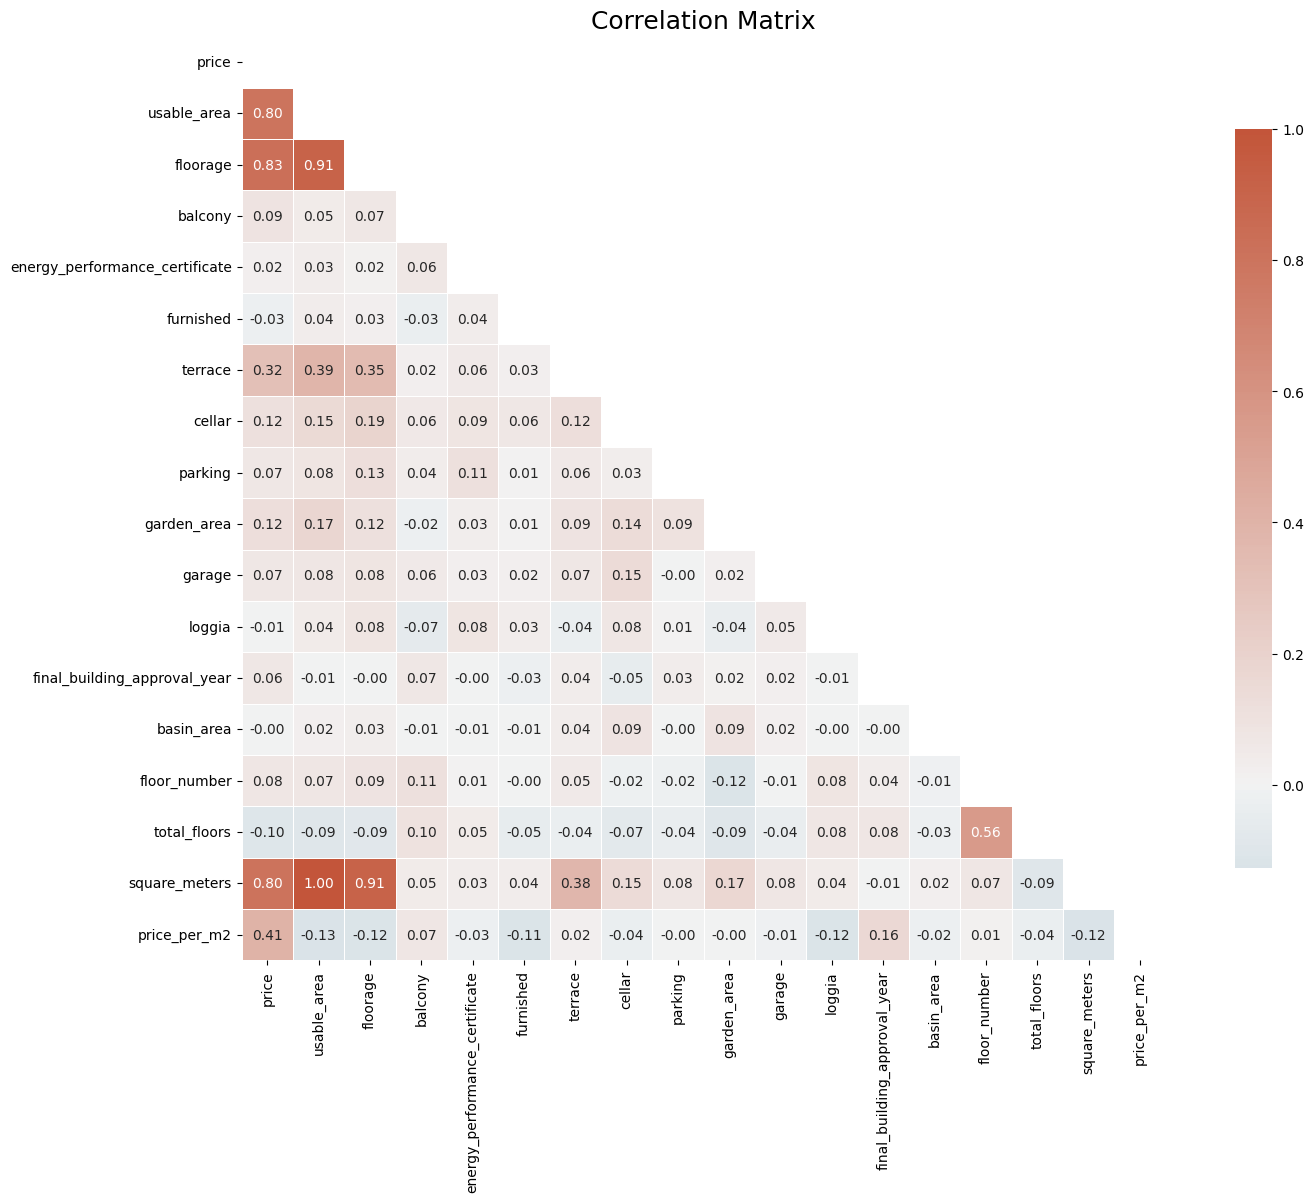

price                             1.000000
floorage                          0.829951
square_meters                     0.801898
usable_area                       0.801631
price_per_m2                      0.405386
terrace                           0.318346
garden_area                       0.122901
cellar                            0.115326
total_floors                     -0.101826
balcony                           0.091803
floor_number                      0.079658
garage                            0.071102
parking                           0.066113
final_building_approval_year      0.064863
furnished                        -0.027436
energy_performance_certificate    0.019291
loggia                           -0.007451
basin_area                       -0.000296
Name: price, dtype: float64


In [ ]:
# Correlation matrix
corr_matrix = data[numerical].corr()

# Mask to hide upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18, 12))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, center=0, annot=True,
            fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix", fontsize=18)
plt.show()
num_corr = data[numerical].corr()['price'].sort_values(ascending = False, key = abs)
print(num_corr)

- Price is highly correlated with square meters (0.80), floorage (0.83) and usable area (0.71), meaning larger properties tend to be more expensive.
- those 3 features are highly correlated between each other and probably carry the same information, we'll need to deal with it for linear modeling to prevent multicollinearity
- total_floors has negative correlation probably indicating that high rise buildings are usually  located outside of the city center and therefore are cheaper
- 'basin_area', 'loggia' have very low correlation with target and other variables, most likely because of the high number of missing values. Needs to be either dropped or NAs should be filled.
- 'terrace' has a good correlation with both 'price' and 'square_meters'

Feature: price


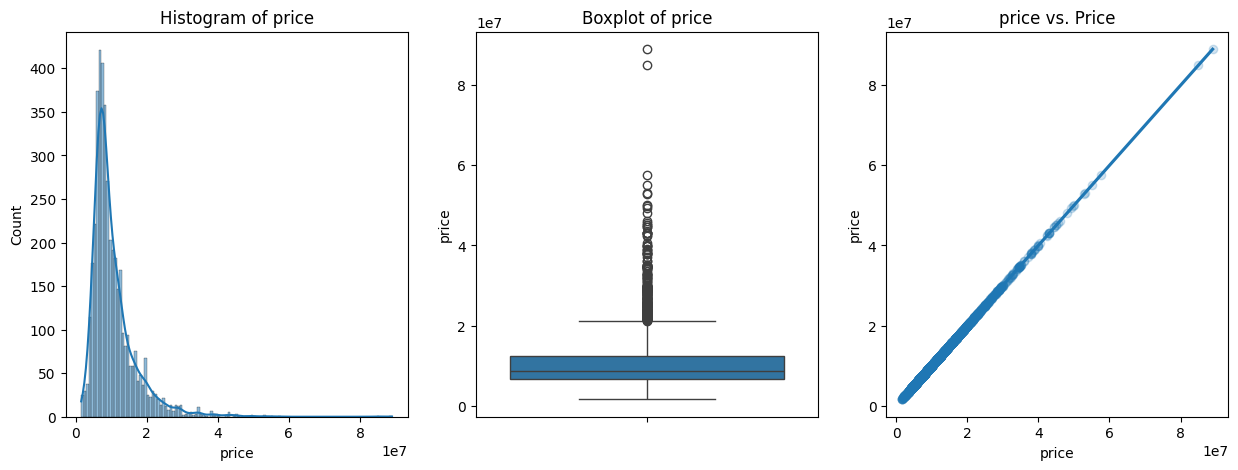

Feature: usable_area


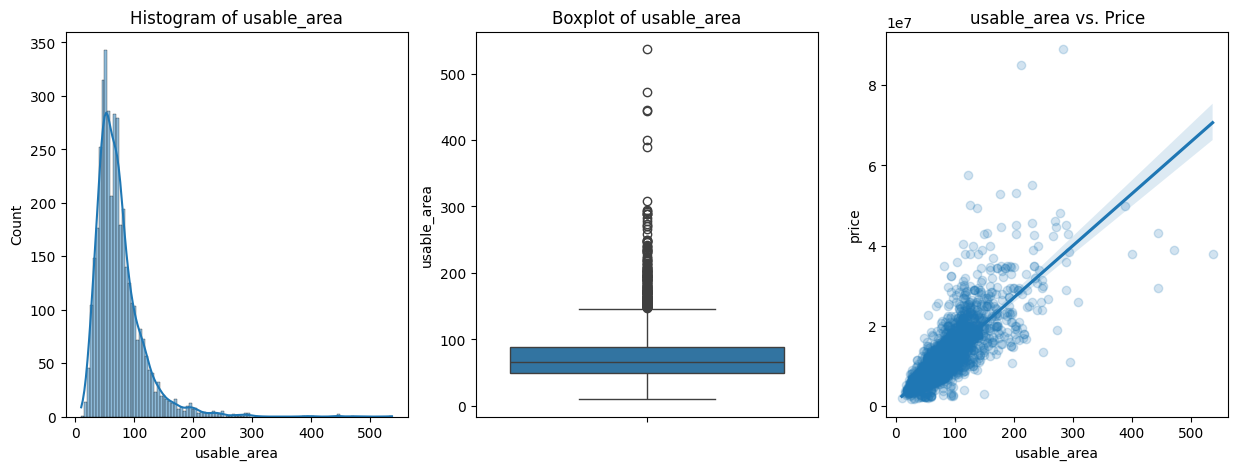

Feature: floorage


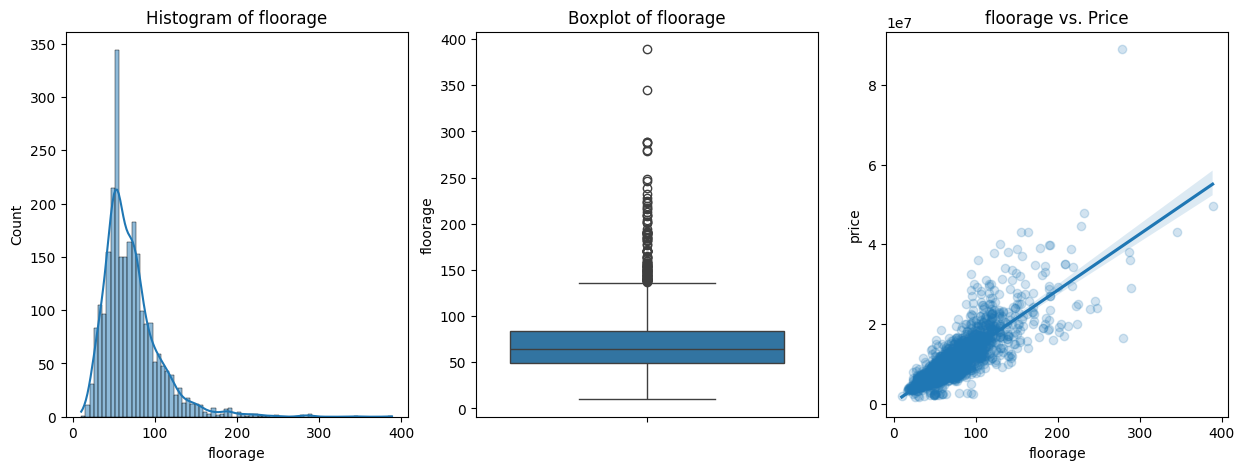

Feature: balcony


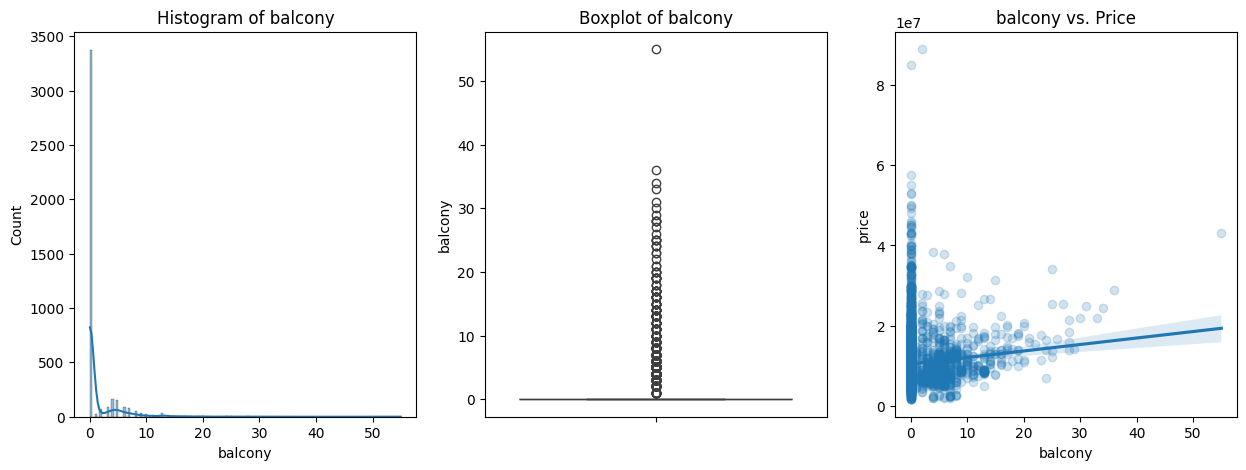

Feature: terrace


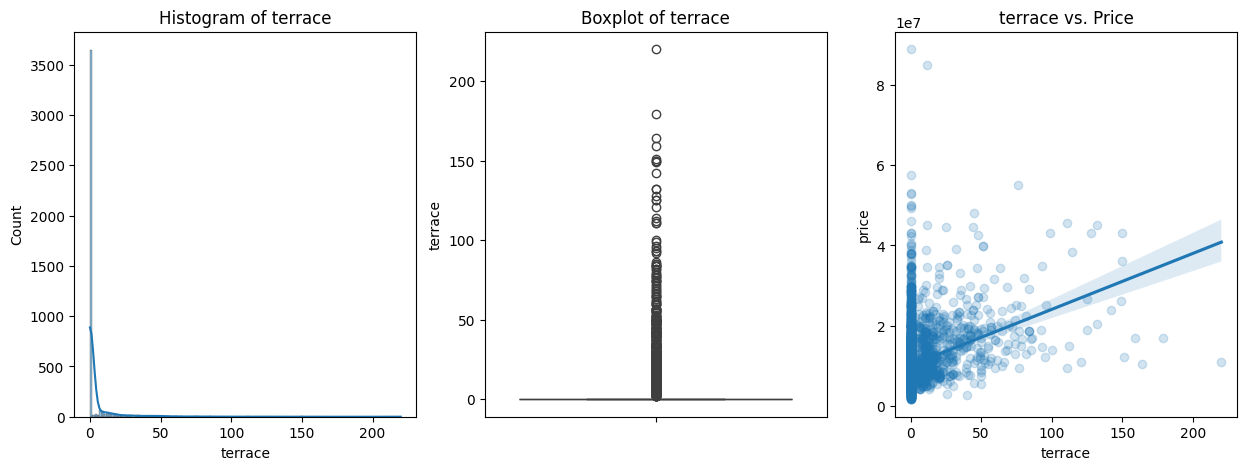

Feature: cellar


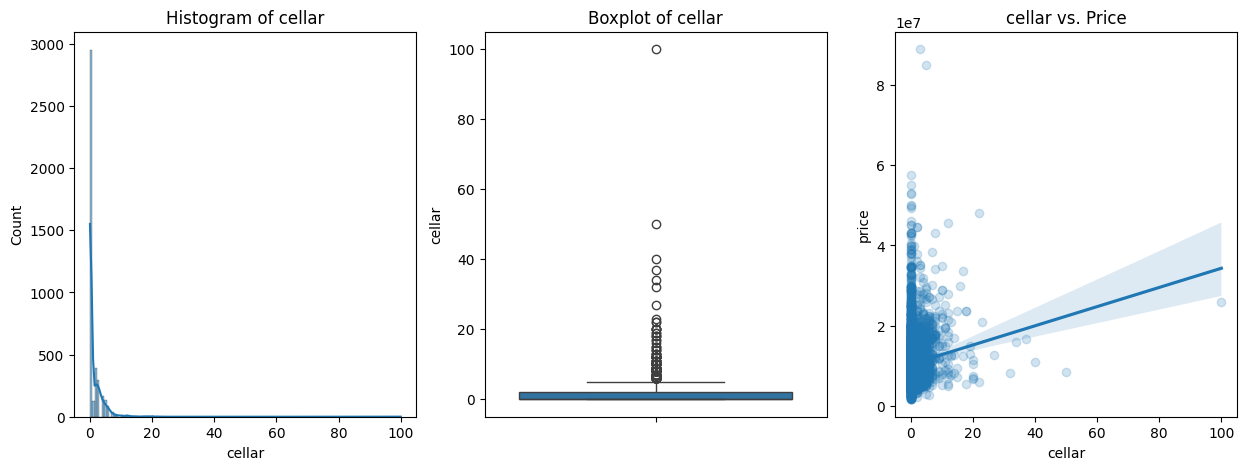

Feature: garden_area


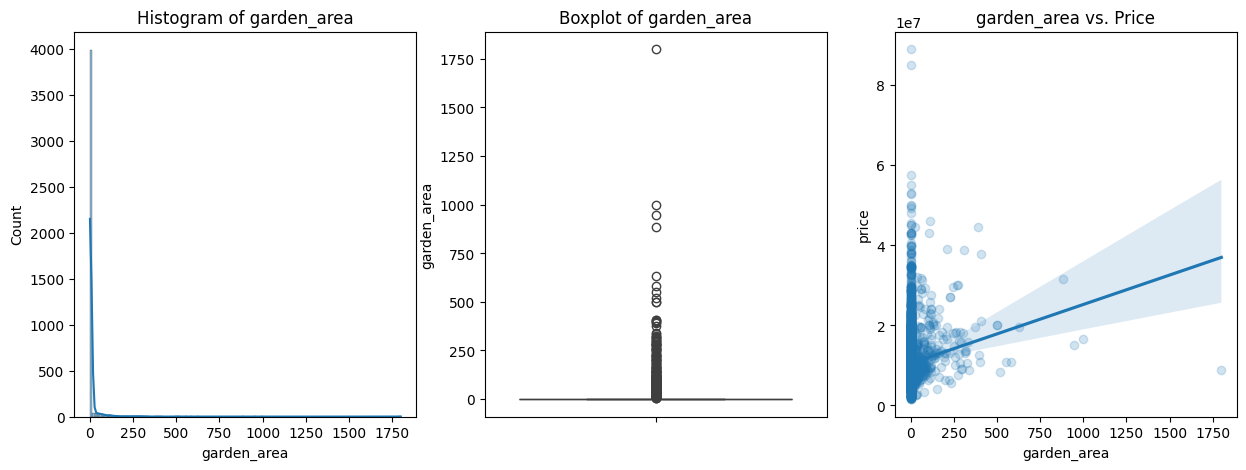

Feature: final_building_approval_year


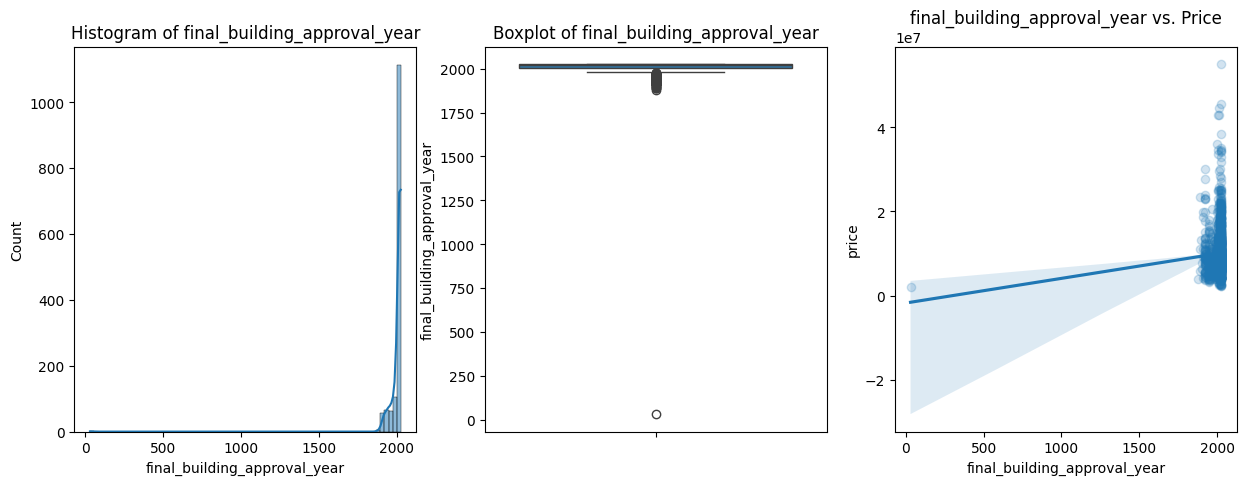

Feature: square_meters


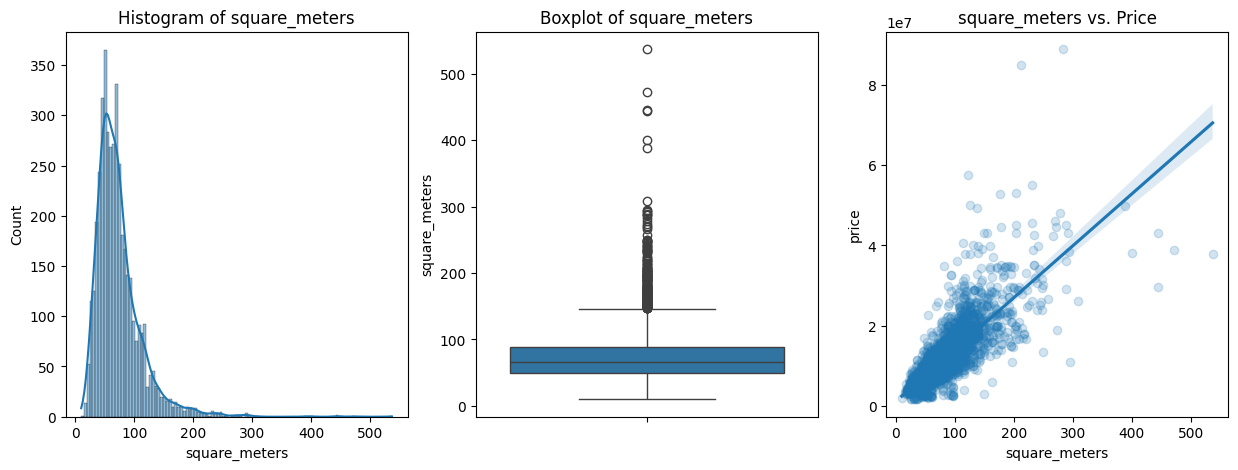

Feature: price_per_m2


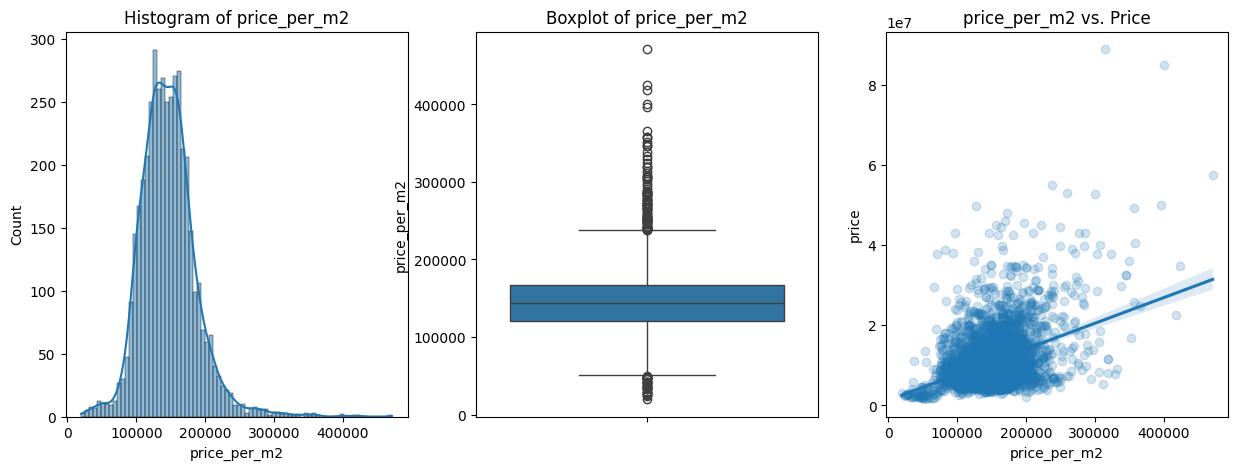

In [ ]:
for var in continuous:
    print(f"Feature: {var}")
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Histogram
    sns.histplot(data[var].dropna(), kde=True, ax=ax[0])
    ax[0].set_title(f"Histogram of {var}")

    # Boxplot
    sns.boxplot(y=data[var], ax=ax[1])
    ax[1].set_title(f"Boxplot of {var}")

    # Scatter plot with target variable
    sns.regplot(data=data, x=var, y=data['price'], scatter_kws={'alpha': 0.2}, ax=ax[2])
    ax[2].set_title(f"{var} vs. Price")

    plt.show()


Price is right skewed

- most properties are concentrated in the lower price range.
- consider log-transforming for linear regression

balcony, terrace, garden_area - mostly zeros
-  these act like binary plus magnitude features (0 = no feature, >0 = size).
-  outliers: A 50m² balcony, 1750m2 garden_area, 100m2 cellar, 200+ m2 terrace, final_building_approval_year = 31

square meters, floorage, usable area vs price
-  Distribution matches, strong candidates for predictive modeling

-  quite a lot of extreme values, consider log transformation or winsorization

3.2.5 Check for invalid values

In [ ]:
# Check for negative or zero values in columns that should be positive
for col in numerical:
    if (data[col] < 0).any():
        print(f"Negative values detected in {col}")


# Check for outliers
def print_extreme_values(df, column, top=5):
    print(f"\n{column} - Highest Values:")
    print(df[column].sort_values(ascending=False).head(top))

for col in ['price', 'square_meters', 'balcony', 'terrace', 'cellar',
                     'garden_area', 'loggia']:
    print_extreme_values(data, col)


price - Highest Values:
4256    89000000.0
3914    85000000.0
1114    57500000.0
2794    54983500.0
1529    53000000.0
Name: price, dtype: float64

square_meters - Highest Values:
2653    537
2620    472
2494    445
4272    444
1863    400
Name: square_meters, dtype: int64

balcony - Highest Values:
1426    55
3783    36
4237    34
3729    33
662     31
Name: balcony, dtype: int64

terrace - Highest Values:
267     220
2024    179
4085    164
2622    159
1047    151
Name: terrace, dtype: int64

cellar - Highest Values:
2694    100
2812     50
1344     40
1581     37
4029     34
Name: cellar, dtype: int64

garden_area - Highest Values:
943     1800
1581    1000
1896     949
729      883
2132     631
Name: garden_area, dtype: int64

loggia - Highest Values:
3622    42
1188    31
1819    30
2274    20
735     20
Name: loggia, dtype: int64


While some of the values look suspicious it's hard to tell if they are completely unrealistic.
- the garden that has area of 1800 m2 is definitely false, based on the street it's located on it seems that the garden is actually a public square.
- Year 31 is also invalid

The values will be removed back in data cleansing notebook

Floor number should always be less or equal to total floors, other values are invalid and should be removed.

In [ ]:
mask = (data['floor_number'] > data['total_floors']) & \
       data['floor_number'].notna() & data['total_floors'].notna()

n_invalid = mask.sum()
pct_invalid = n_invalid / len(data) * 100
print(f"{n_invalid} listings ({pct_invalid:.2f}%) have floor_number > total_floors.")


0 listings (0.00%) have floor_number > total_floors.


Checking future years (data was collected in 2024)

In [ ]:
future_years = data[data['final_building_approval_year'] > 2024]
print(future_years['final_building_approval_year'].value_counts())


final_building_approval_year
2025.0    246
2026.0    213
2027.0     34
Name: count, dtype: int64


All years that are later then the time of data collection seem reasonable and mean that the project approval date is expected in the nearest future, so no values should be dropped.

In [ ]:
print(categorical)
print(numerical)
print(continuous)
print(discrete)

['building', 'property_status', 'ownership', 'property_location', 'water', 'heating', 'gas', 'energy_performance_rating', 'waste', 'street', 'district', 'cadastral_area', 'layout']
['price', 'usable_area', 'floorage', 'balcony', 'energy_performance_certificate', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'final_building_approval_year', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'price_per_m2']
['price', 'usable_area', 'floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'final_building_approval_year', 'square_meters', 'price_per_m2']
['energy_performance_certificate', 'furnished', 'parking', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors']


Final conclusions:
- chose one area variable for linear regression, most suitable might just be the one that has less missing values ('square_meters' has 0 na)
- log tranform price for modeling, consider log tranforming area variable and other numeric variables

# 4. Train/Valid/Test Split

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Create price bins for stratification (optional but recommended in regression)
#data['price_bin'] = pd.qcut(data['price'], q=5, labels=False, duplicates='drop')  # or q=10
y_strat = pd.qcut(y, q=5, labels=False)


# 2. Separate features and target
target = 'price'
X = data.drop(columns=[target])
y = data[target]

# 3. First: Train+Valid vs Test
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_strat, random_state=42)

# 4. Now split Train_Valid into Train and Valid
# Re-bin target again on the subset if needed:
y_train_valid_strat = pd.qcut(y_train_valid, q=5, labels=False, duplicates='drop')

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.2, stratify=y_train_valid_strat, random_state=42)


In [ ]:
print('X train size: ' + str(X_train.shape[0]))
print('X valid size: ' + str(X_valid.shape[0]))
print('X train_valid size: ' + str(X_train_valid.shape[0]))
print('X test (holdout) size: ' + str(X_test.shape[0]))
print('\n')
print('Y train size: ' + str(y_train.shape[0]))
print('Y valid size: ' + str(y_valid.shape[0]))
print('Y train_valid size: ' + str(y_train_valid.shape[0]))
print('Y test (holdout) size: ' + str(y_test.shape[0]))
print('\n')
print('Total data size: ' + str(data.shape[0]))
if data.shape[0] == (y_train.shape[0] + y_valid.shape[0] +y_test.shape[0]):
    print('Sample sizes are correct')

X train size: 2745
X valid size: 687
X train_valid size: 3432
X test (holdout) size: 859


Y train size: 2745
Y valid size: 687
Y train_valid size: 3432
Y test (holdout) size: 859


Total data size: 4291
Sample sizes are correct


In [ ]:
numerical.remove('price')
X_train[numerical].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2745 entries, 1355 to 3948
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   usable_area                     2512 non-null   float64
 1   floorage                        1611 non-null   float64
 2   balcony                         2745 non-null   float64
 3   energy_performance_certificate  2745 non-null   float64
 4   furnished                       2745 non-null   float64
 5   terrace                         2745 non-null   float64
 6   cellar                          2745 non-null   float64
 7   parking                         2745 non-null   float64
 8   garden_area                     2745 non-null   float64
 9   garage                          2745 non-null   float64
 10  loggia                          2745 non-null   float64
 11  final_building_approval_year    923 non-null    float64
 12  basin_area                      2745

### 4.2 Numeric variables - Missing values handling

Impute categorical nan with 'Missing'

In [ ]:

def impute_categorical(data):
    """
    Fills missing values in categorical columns with the label 'Missing'.
    """
    cat_cols = data.select_dtypes(include=['object', 'category']).columns
    data[cat_cols] = data[cat_cols].fillna('Missing')
    return data

data = impute_categorical(data)



"\ndef impute_categorical(data):\n    \n    Fills missing values in categorical columns with the label 'Missing'.\n    \n    cat_cols = data.select_dtypes(include=['object', 'category']).columns\n    data[cat_cols] = data[cat_cols].fillna('Missing')\n    return data\n\ndata = impute_categorical(data)\n"

4.2.1 Identify if missing values are MNAR

In [ ]:
from scipy.stats import ttest_ind

def check_mnar_with_stats_from_split(X, y, cols_to_check):
    # Join X and y temporarily for analysis
    df = X.copy()
    df['__target__'] = y

    for col in cols_to_check:
        if df[col].isnull().sum() == 0:
            continue

        print(f"\n Checking column: {col}")

        df['__missing__'] = df[col].isnull().astype(int)
        stats = df.groupby('__missing__')['__target__'].describe()
        print(stats)

        group0 = df[df['__missing__'] == 0]['__target__']
        group1 = df[df['__missing__'] == 1]['__target__']

        # Run t-test
        t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
        print(f"🧪 T-test p-value: {p_val:.5f}")

        if p_val < 0.05:
            print(f"Possible MNAR pattern in '{col}'")
        else:
            print(f"No significant MNAR pattern in '{col}'")

        # Clean up helper columns
        df.drop(columns=['__missing__'], inplace=True)

    # Clean up joined target column
    df.drop(columns='__target__', inplace=True)



In [ ]:
cols_with_na = [col for col in X_train.columns if X_train[col].isnull().sum() > 0]

check_mnar_with_stats_from_split(X_train, y_train, cols_to_check=cols_with_na)



 Checking column: usable_area
              count          mean           std        min        25%  \
__missing__                                                             
0            2512.0  1.078130e+07  6.736632e+06  1690000.0  6796750.0   
1             233.0  9.741053e+06  5.198169e+06  1590000.0  6200000.0   

                   50%         75%         max  
__missing__                                     
0            8699100.0  12501375.0  85000000.0  
1            8316000.0  12421500.0  32500000.0  
🧪 T-test p-value: 0.00479
Possible MNAR pattern in 'usable_area'

 Checking column: floorage
              count          mean           std        min         25%  \
__missing__                                                              
0            1611.0  1.022218e+07  5.731999e+06  1690000.0  6750000.00   
1            1134.0  1.136187e+07  7.672237e+06  1590000.0  6755823.25   

                   50%         75%         max  
__missing__                              

Since all of the missing values might be MNAR we will impute values but also create flagged columns (name_NA) which will be useful for the model.

In [ ]:

def get_impute_values(df, method='median', cols=None):
    """
    Compute imputation values (median, mean, or mode) for specified columns.
    """
    df = df.copy()
    impute_vals = {}

    if cols is None:
        cols = df.select_dtypes(include='number').columns

    for col in cols:
        if df[col].isna().sum() > 0:
            if method == 'median':
                impute_vals[col] = df[col].median()
            elif method == 'mean':
                impute_vals[col] = df[col].mean()
            elif method == 'mode':
                impute_vals[col] = df[col].mode()[0]
            else:
                raise ValueError("Unsupported method")
    return impute_vals


In [ ]:
"""def apply_impute_values(df, impute_dict):
    df = df.copy()
    for col, val in impute_dict.items():
        df[col] = df[col].fillna(val)
    return df
"""
# adding new_na_cols return, so the new flagged _NA columns can be easily added to numerical and discrete lists

def apply_impute_values(df, impute_dict, add_missing_flags=False):
    df = df.copy()
    new_na_cols = []

    for col, val in impute_dict.items():
        if add_missing_flags:
            na_col = col + "_NA"
            df[na_col] = df[col].isna().astype(int)
            new_na_cols.append(na_col)
        df[col] = df[col].fillna(val)

    return df, new_na_cols


In [ ]:
# remove target variable from continuous
continuous.remove('price')

# Get impute values from X_train only. Continuous will use median method and discrete - mode.
cont_impute_vals = get_impute_values(X_train, method='median', cols=continuous)
disc_impute_vals = get_impute_values(X_train, method='mode', cols=discrete)

# Combine both
all_impute_vals = {**cont_impute_vals, **disc_impute_vals}

# impute values into train, valid and test sets, create train_na_cols list of new _NA columns
X_train, train_na_cols = apply_impute_values(X_train, all_impute_vals, add_missing_flags=True)
X_valid, _ = apply_impute_values(X_valid, all_impute_vals, add_missing_flags=True)
X_test, _  = apply_impute_values(X_test, all_impute_vals, add_missing_flags=True)

# Append new binary NA flags to discrete and numerical list
discrete.extend(train_na_cols)
numerical.extend(train_na_cols)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2745 entries, 1355 to 3948
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   location                         2745 non-null   category
 1   building                         2745 non-null   category
 2   property_status                  2745 non-null   category
 3   ownership                        2745 non-null   category
 4   property_location                2745 non-null   category
 5   usable_area                      2745 non-null   float64 
 6   floorage                         2745 non-null   float64 
 7   balcony                          2745 non-null   float64 
 8   water                            2745 non-null   category
 9   heating                          2745 non-null   category
 10  gas                              2745 non-null   category
 11  energy_performance_rating        2745 non-null   category
 12  energy_p

### 4.3 Feature Generation

Add building_age variable - might be more informative then 'final_building_approval_year'

Relative floor info - identifying if it's a top or ground floor, might be informative.
We would assume that the ground floor can be both 0 and 1, since there're suspiciously few 0 floors in the dataset (only 15)


In [ ]:
for df in (X_train, X_valid, X_test):
    # total area
    area_features = ['square_meters', 'balcony', 'terrace', 'cellar', 'loggia', 'basin_area']
    df['total_area']    = ( df[area_features]
                            .sum(axis=1) )

    # top / ground‐floor flags
    df['is_top_floor']     = (df['floor_number']==df['total_floors']).astype(int)
    df['is_ground_floor']  = (df['floor_number']==1).astype(int)

    # building age
    df['building_age']     = 2024 - df['final_building_approval_year']
    df['building_age'] = df['building_age'].clip(lower=0)



In [ ]:
X_train[['building_age', 'final_building_approval_year']].head(20)

,building_age,final_building_approval_year
1355,1.0,2023.0
4545,3.0,2021.0
2843,1.0,2023.0
4346,0.0,2024.0
1814,0.0,2025.0
2349,1.0,2023.0
4097,54.0,1970.0
2334,1.0,2023.0
3353,1.0,2023.0
1412,1.0,2023.0


In [ ]:
subset = X_train[['building_age', 'final_building_approval_year']].dropna()
print(subset.corr())

                              building_age  final_building_approval_year
building_age                      1.000000                     -0.999553
final_building_approval_year     -0.999553                      1.000000


In [ ]:
continuous += ['building_age','total_area']
discrete   += ['is_top_floor','is_ground_floor']
numerical  += ['building_age','total_area','is_top_floor','is_ground_floor']

In [ ]:
print('numerical', numerical)
print('continuous', continuous)
print('discrete:', discrete)
print('categorical:', categorical)

numerical ['usable_area', 'floorage', 'balcony', 'energy_performance_certificate', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'final_building_approval_year', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'building_age', 'total_area', 'is_top_floor', 'is_ground_floor']
continuous ['usable_area', 'floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'final_building_approval_year', 'square_meters', 'building_age', 'total_area']
discrete: ['energy_performance_certificate', 'furnished', 'parking', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'is_top_floor', 'is_ground_floor']
categorical: ['building', 'property_status', 'ownership', 'property_location', 'water', 'heating', 'gas', 'energy_performance_rati

In [ ]:
# Save for tree-based models (all features, fully preprocessed)
X_train_full = X_train.copy()
X_valid_full = X_valid.copy()
X_test_full  = X_test.copy()

all_cols = numerical + categorical

X_train_full = X_train_full[all_cols]
X_valid_full = X_valid_full[all_cols]
X_test_full  = X_test_full[all_cols]

In [ ]:
all_cols

['usable_area',
 'floorage',
 'balcony',
 'energy_performance_certificate',
 'furnished',
 'terrace',
 'cellar',
 'parking',
 'garden_area',
 'garage',
 'loggia',
 'final_building_approval_year',
 'basin_area',
 'floor_number',
 'total_floors',
 'square_meters',
 'usable_area_NA',
 'floorage_NA',
 'final_building_approval_year_NA',
 'floor_number_NA',
 'total_floors_NA',
 'building_age',
 'total_area',
 'is_top_floor',
 'is_ground_floor',
 'building',
 'property_status',
 'ownership',
 'property_location',
 'water',
 'heating',
 'gas',
 'energy_performance_rating',
 'waste',
 'street',
 'district',
 'cadastral_area',
 'layout']

# 5. Sample feature engineering

### 5.1 Encode ordinal variables

In [ ]:
rating_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}

for df in [X_train, X_valid, X_test]:
    df['energy_performance_rating_numeric'] = (
        df['energy_performance_rating']
        .map(rating_map)
        .fillna(8)  # apply directly before casting
        .astype(int)
    )

In [ ]:
X_train['energy_performance_rating_numeric'].value_counts(dropna = False)

,count
energy_performance_rating_numeric,
2,894
7,604
8,517
3,421
4,181
5,64
1,44
6,20


In [ ]:
# remove energy_performance_rating from categorical
categorical.remove('energy_performance_rating')

### 5.2 Eliminating unwanted characteristics - low variance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def identify_low_variance_features(
    df,
    continuous_vars,
    variance_threshold=0.01,
    verbose=True
):
    """
    Identify low-variance features among continuous variables.

    Parameters:
    - df (pd.DataFrame): Input dataframe
    - continuous_vars (list): List of continuous feature names
    - variance_threshold (float): Variance cutoff below which features are considered low-variance
    - verbose (bool): If True, prints low-variance features

    Returns:
    - low_variance_features (list): Features to consider dropping
    - variances (pd.Series): Variance values of all continuous features (sorted)
    """

    # Step 1: Normalize to [0, 1]
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[continuous_vars])
    scaled_df = pd.DataFrame(scaled, columns=continuous_vars)

    # Step 2: Compute variances
    variances = scaled_df.var().sort_values()

    # Step 3: Identify low-variance features
    low_variance_features = variances[variances <= variance_threshold].index.tolist()

    if verbose:
        print(f"\n{len(low_variance_features)} low-variance features (threshold = {variance_threshold}):")
        for var in low_variance_features:
            print(f"{var}: {variances[var]:.6f}")

    return low_variance_features, variances


In [ ]:
low_var_features, variances = identify_low_variance_features(
    X_train,
    continuous_vars=continuous,
    variance_threshold=0.01
)

# Show all variances (sorted)
#print(variances)



8 low-variance features (threshold = 0.01):
garden_area: 0.002526
terrace: 0.004826
floorage: 0.004987
cellar: 0.005482
usable_area: 0.006007
square_meters: 0.006314
balcony: 0.009145
total_area: 0.009195


Those features might still be important but we'll consider dropping them in a feature selection step

### 5.3 Eliminating unwanted characteristics - high correlation

In [ ]:

def find_highly_correlated_features(
    df,
    feature_list,
    target_col=None,
    correlation_threshold=0.9,
    exclude_na_flags=True,
    plot=True
):
    """
    Identify pairs of features with high Pearson correlation.

    Parameters:
    - df (pd.DataFrame): Dataset
    - feature_list (list): Features to analyze
    - target_col (str): Optional target column for correlation sorting
    - correlation_threshold (float): Threshold for strong correlation
    - exclude_na_flags (bool): Whether to ignore *_NA columns
    - plot (bool): Whether to show the heatmap

    Returns:
    - high_corr_df (pd.DataFrame): DataFrame of highly correlated pairs
    - corr_matrix (pd.DataFrame): Full correlation matrix
    """

    features = feature_list.copy()
    if exclude_na_flags:
        features = [f for f in features if '_NA' not in f]

    # Compute correlation matrix
    corr_matrix = df[features].corr()

    if plot:
        plt.figure(figsize=(20, 15))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        cmap = sns.diverging_palette(230, 20, as_cmap=True)
        sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, center=0, annot=True,
                    fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title("Feature Correlation Matrix", fontsize=18)
        plt.show()

    # Unstack and filter correlations
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_pairs = upper_tri.stack().reset_index()
    high_corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
    high_corr_pairs['Correlation_abs'] = high_corr_pairs['Correlation'].abs()
    high_corr_df = high_corr_pairs[high_corr_pairs['Correlation_abs'] > correlation_threshold]
    high_corr_df = high_corr_df.sort_values('Correlation_abs', ascending=False)

    print(f"\n🔍 Found {len(high_corr_df)} pairs with correlation > {correlation_threshold}")
    return high_corr_df, corr_matrix

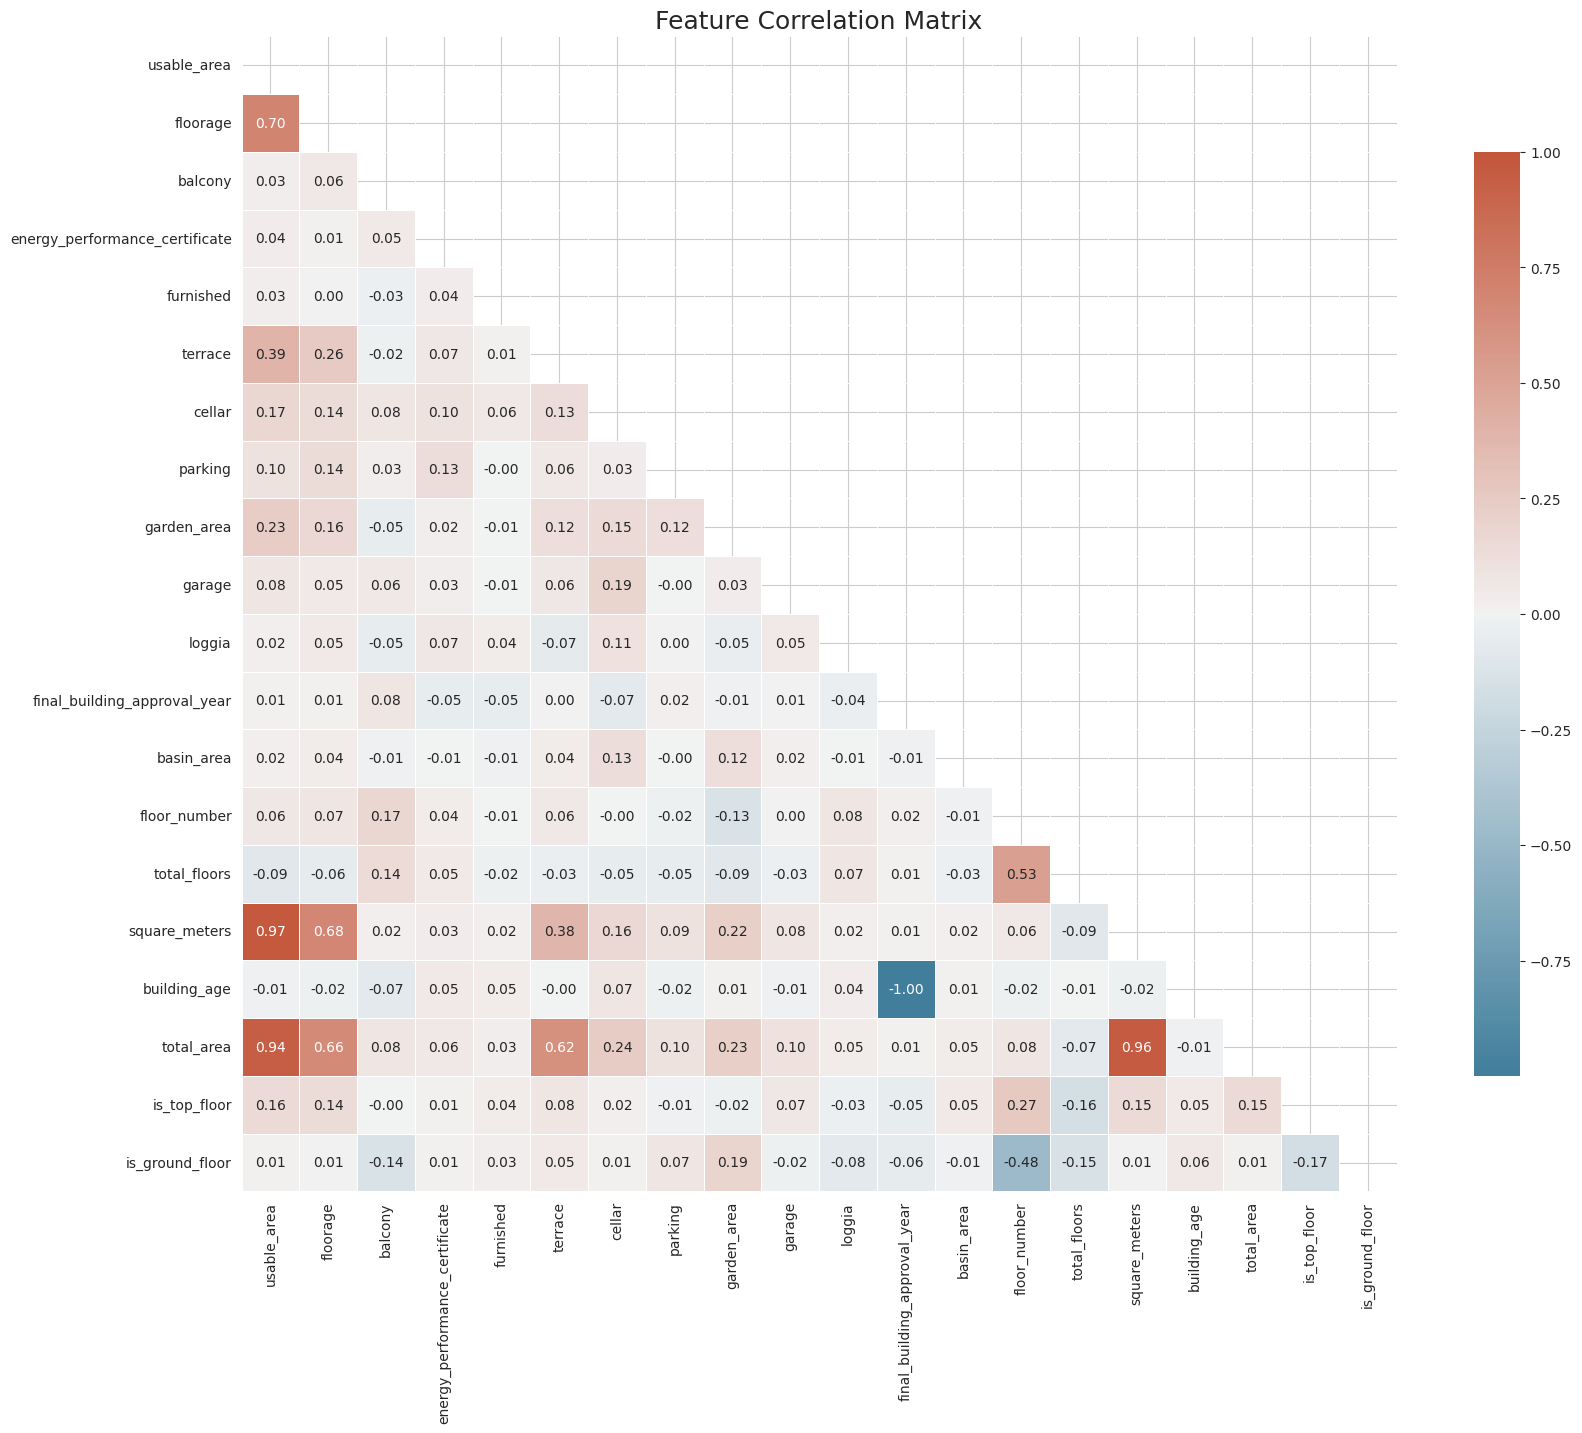


🔍 Found 4 pairs with correlation > 0.9


,Feature1,Feature2,Correlation,Correlation_abs
158,final_building_approval_year,building_age,-0.999553,0.999553
14,usable_area,square_meters,0.974406,0.974406
181,square_meters,total_area,0.955025,0.955025
16,usable_area,total_area,0.938021,0.938021


In [ ]:
# Run correlation check on updated feature set
high_corr_df, updated_corr_matrix = find_highly_correlated_features(
    df=X_train,           # or full dataset if appropriate
    feature_list=numerical,  # or numerical, or features
    target_col='price',       # optional: can sort later
    correlation_threshold=0.9,
    exclude_na_flags=True,
    plot=True
)

# View top correlated pairs
display(high_corr_df)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def select_features_by_correlation_and_r2(df, target, high_corr_df, drop_if_lower_r2=True):
    """
    Automatically drop the lower-R² feature from highly correlated pairs.
    """
    to_drop = []
    for _, row in high_corr_df.iterrows():
        f1, f2 = row['Feature1'], row['Feature2']
        r2_f1 = r2_score(y_train, LinearRegression().fit(X_train[[f1]], y_train).predict(X_train[[f1]]))
        r2_f2 = r2_score(y_train, LinearRegression().fit(X_train[[f2]], y_train).predict(X_train[[f2]]))

        print(f"{f1}: R²={r2_f1:.4f}, {f2}: R²={r2_f2:.4f}")

        if drop_if_lower_r2:
            drop_feature = f1 if r2_f1 < r2_f2 else f2
            to_drop.append(drop_feature)
            print(f"Dropping: {drop_feature}")

    return to_drop


In [ ]:
features_to_remove = select_features_by_correlation_and_r2(X_train, y_train, high_corr_df)


final_building_approval_year: R²=0.0030, building_age: R²=0.0032
Dropping: final_building_approval_year
usable_area: R²=0.6008, square_meters: R²=0.6348
Dropping: usable_area
square_meters: R²=0.6348, total_area: R²=0.5850
Dropping: total_area
usable_area: R²=0.6008, total_area: R²=0.5850
Dropping: total_area


Based on R2 score let's eliminate 2 features that have high correlation with another feature: total_area and final_building_approval_year

In [ ]:
print(numerical)
print(continuous)

['usable_area', 'floorage', 'balcony', 'energy_performance_certificate', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'final_building_approval_year', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'building_age', 'total_area', 'is_top_floor', 'is_ground_floor']
['usable_area', 'floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'final_building_approval_year', 'square_meters', 'building_age', 'total_area']


In [ ]:
numerical = [f for f in numerical if f not in features_to_remove]
continuous = [f for f in continuous if f not in features_to_remove]

In [ ]:
print(numerical)
print(continuous)

['floorage', 'balcony', 'energy_performance_certificate', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'building_age', 'is_top_floor', 'is_ground_floor']
['floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'square_meters', 'building_age']


5.3.2 Categorical variables correlation

High correlation between cadastral_area and district. Due to high cardinality of cadastral_area (~100), and similar predictive power, we retain district and drop cadastral_area to reduce dimensionality and overfitting risk in linear models.

In [ ]:
features_to_remove = ['cadastral_area', 'street']
categorical = [x for x in categorical if x not in features_to_remove]

In [ ]:
categorical

['building',
 'property_status',
 'ownership',
 'property_location',
 'water',
 'heating',
 'gas',
 'waste',
 'district',
 'layout']

In [ ]:
X_train.shape

(2745, 40)

In [ ]:
X_train.columns

Index(['location', 'building', 'property_status', 'ownership',
       'property_location', 'usable_area', 'floorage', 'balcony', 'water',
       'heating', 'gas', 'energy_performance_rating',
       'energy_performance_certificate', 'furnished', 'terrace', 'cellar',
       'parking', 'garden_area', 'garage', 'loggia', 'waste',
       'final_building_approval_year', 'basin_area', 'floor_number',
       'total_floors', 'street', 'district', 'cadastral_area', 'layout',
       'square_meters', 'usable_area_NA', 'floorage_NA',
       'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA',
       'total_area', 'is_top_floor', 'is_ground_floor', 'building_age',
       'energy_performance_rating_numeric'],
      dtype='object')

In [ ]:
print(numerical)
print(categorical)

['floorage', 'balcony', 'energy_performance_certificate', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'building_age', 'is_top_floor', 'is_ground_floor']
['building', 'property_status', 'ownership', 'property_location', 'water', 'heating', 'gas', 'waste', 'district', 'layout']


In [ ]:
 len(numerical)

22

In [ ]:
len(categorical)

10

### 5.4 Feature selection

5.4.1 Numerical

We'll try to get a glimple of the feature importance using Mutual info and Lasso importance for Numerical features.

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# === INPUTS ===
X_num = X_train[numerical].copy()  # Already imputed
y = y_train.copy()

# === SCALE X ===
x_scaler = StandardScaler()
X_scaled = pd.DataFrame(x_scaler.fit_transform(X_num), columns=X_num.columns)

# === SCALE y ===
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# === MUTUAL INFO ===
mi = mutual_info_regression(X_num, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X_num.columns, 'Mutual_Info': mi})

# === LASSO ===
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y_scaled)
lasso_df = pd.DataFrame({
    'Feature': X_num.columns,
    'Lasso_Importance': np.abs(lasso.coef_)
})

# === VIF ===
vif_scores = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
vif_df = pd.DataFrame({'Feature': X_num.columns, 'VIF': vif_scores})

# === COMBINE RESULTS ===
num_df = mi_df.merge(lasso_df, on='Feature').merge(vif_df, on='Feature').set_index('Feature')

# === DECISION RULES ===
LASSO_THRESHOLD = 0.01  # Safe now, since y is standardized

# "Drop if weak in both MI and Lasso"
num_df['Recommended_Drop'] = (
    (num_df['Mutual_Info'] < 0.01) &
    (num_df['Lasso_Importance'] < LASSO_THRESHOLD)
)

# VIF warning, not exclusionary
num_df['High_VIF'] = num_df['VIF'] > 10

# === FINAL SELECTION ===
num_keep = num_df[~num_df['Recommended_Drop']].index.tolist()
num_drop = num_df[num_df['Recommended_Drop']].index.tolist()

# === OUTPUT ===
print("\n=== NUMERICAL FEATURE ANALYSIS ===")
print(num_df.sort_values(by='Mutual_Info', ascending=False))
print(f"\n✅ Keep ({len(num_keep)}): {num_keep}")
print(f"\n❌ Drop ({len(num_drop)}): {num_drop}")
print("\n⚠️ High VIF Warning:")
print(num_df[num_df['High_VIF']].sort_values(by='VIF', ascending=False))



=== NUMERICAL FEATURE ANALYSIS ===
                                 Mutual_Info  Lasso_Importance        VIF  \
Feature                                                                     
square_meters                       0.772263          0.781713   2.221925   
floorage                            0.468160          0.000012   2.024561   
balcony                             0.091500          0.020208   1.117369   
terrace                             0.076356          0.000804   1.224370   
floor_number                        0.056201          0.039333   2.263054   
total_floors                        0.055569          0.041973   1.831045   
building_age                        0.052571          0.041121   1.237428   
cellar                              0.046574          0.003189   1.159267   
garden_area                         0.039165          0.003403   1.159702   
usable_area_NA                      0.031085          0.044710  14.093863   
garage                              0.02

['energy_performance_certificate', 'floor_number_NA', 'is_top_floor'] were selected as variables to drop.
'floor_number_NA' has also high VIF value. We'll drop all 3 of them.

In [ ]:
features_to_remove = ['energy_performance_certificate', 'floor_number_NA', 'is_top_floor']
continuous = [f for f in continuous if f not in features_to_remove]
numerical = [f for f in numerical if f not in features_to_remove]

In [ ]:
numerical

['floorage',
 'balcony',
 'furnished',
 'terrace',
 'cellar',
 'parking',
 'garden_area',
 'garage',
 'loggia',
 'basin_area',
 'floor_number',
 'total_floors',
 'square_meters',
 'usable_area_NA',
 'floorage_NA',
 'final_building_approval_year_NA',
 'total_floors_NA',
 'building_age',
 'is_ground_floor']

5.4.2 Categorical

We'll use Mutual info and ANOVA to decide the importance of categorical values.

In [ ]:
from sklearn.feature_selection import f_regression, f_classif
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

X_cat_encoded = X_train[categorical].apply(lambda x: x.astype('category').cat.codes)

# Calculate Mutual Info and ANOVA
mi_scores_cat = mutual_info_regression(X_cat_encoded, y_train, discrete_features=True)
f_scores_cat, p_values_cat = f_regression(X_cat_encoded, y_train)

cat_scores_df = pd.DataFrame({
    'Feature': categorical,
    'Mutual_Info': mi_scores_cat,
    'ANOVA_F': f_scores_cat,
    'ANOVA_p': p_values_cat
}).set_index('Feature')

# Apply stricter keep rule
cat_scores_df['Recommended_Drop'] = (
    (cat_scores_df['Mutual_Info'] < 0.02) &
    (cat_scores_df['ANOVA_p'] > 0.1)
)

cat_keep = cat_scores_df[~cat_scores_df['Recommended_Drop']].index.tolist()
cat_drop = cat_scores_df[cat_scores_df['Recommended_Drop']].index.tolist()

print("\n=== CATEGORICAL FEATURE ANALYSIS ===")
print(cat_scores_df.sort_values(by='Mutual_Info', ascending=False))
print(f"\n✅ Keep ({len(cat_keep)}): {cat_keep}")
print(f"\n❌ Drop ({len(cat_drop)}): {cat_drop}")


=== CATEGORICAL FEATURE ANALYSIS ===
                   Mutual_Info      ANOVA_F        ANOVA_p  Recommended_Drop
Feature                                                                     
layout                0.472926  1700.922515  1.014015e-289             False
property_status       0.132808     0.898601   3.432406e-01             False
building              0.121306    63.477644   2.355319e-15             False
district              0.116474    60.048218   1.293524e-14             False
property_location     0.047832    25.235699   5.399018e-07             False
ownership             0.042153    61.427550   6.517340e-15             False
waste                 0.025150    25.034658   5.986576e-07             False
gas                   0.024567     0.993903   3.188783e-01             False
heating               0.011176    23.737876   1.166653e-06             False
water                 0.008520    10.163066   1.448945e-03             False

✅ Keep (10): ['building', 'property_s

Similarly to numerical features we have 5 candidates to drop but none of them has low score in both MI and ANOVA P values, so we'll keep them all for now and test the model with only recommended features.


### 5.5 Target variable analysis and transformationm

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import boxcox, yeojohnson
from statsmodels.graphics.gofplots import qqplot
from scipy.stats.mstats import winsorize
from scipy.stats import boxcox, yeojohnson, probplot
from sklearn.preprocessing import PowerTransformer

def plot_distribution(y, title="Original"):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(y, kde=True, ax=ax[0])
    ax[0].set_title(f'{title} - Histogram + KDE')
    sns.boxplot(y=y, ax=ax[1])
    ax[1].set_title(f'{title} - Boxplot')
    qqplot(y, line='s', ax=ax[2])
    ax[2].set_title(f'{title} - QQ Plot')
    plt.tight_layout()
    plt.show()

def transform_target_explorer(y, winsorize=False, winsorize_quantile=0.01):
    """
    Explore and visualize different transformations on the target variable.
    Parameters:
        y: pandas Series (target variable)
        winsorize: bool - whether to include a log+Winsorized version
        winsorize_quantile: float - quantile used for Winsorizing
    """
    assert isinstance(y, pd.Series), "Target must be a pandas Series"

    print(f"\n🔍 Original target distribution:")
    plot_distribution(y, 'Original')

    # Log Transform
    if (y <= 0).any():
        print("⚠️ Log transform skipped due to non-positive values.")
        y_log = None
    else:
        y_log = np.log(y)
        print(f"\n📊 Log-transformed target:")
        plot_distribution(y_log, 'Log')

    # Box-Cox
    if (y <= 0).any():
        print("⚠️ Box-Cox skipped due to non-positive values.")
        y_boxcox = None
    else:
        y_boxcox, lam_boxcox = boxcox(y)
        print(f"\n📊 Box-Cox (λ={lam_boxcox:.3f}):")
        plot_distribution(y_boxcox, f'Box-Cox (λ={lam_boxcox:.3f})')

    # Yeo-Johnson
    pt = PowerTransformer(method='yeo-johnson')
    y_yj = pt.fit_transform(y.values.reshape(-1, 1)).flatten()
    lam_yj = pt.lambdas_[0]
    print(f"\n📊 Yeo-Johnson (λ={lam_yj:.3f}):")
    plot_distribution(y_yj, f'Yeo-Johnson (λ={lam_yj:.3f})')

    # Log + Winsorize
    if winsorize and y_log is not None:
        q_low = y_log.quantile(winsorize_quantile)
        q_high = y_log.quantile(1 - winsorize_quantile)
        y_winsor = y_log.clip(lower=q_low, upper=q_high)
        print(f"\n📊 Log + Winsorized ({int(winsorize_quantile*100)}%):")
        plot_distribution(y_winsor, f'Log + Winsorized ({int(winsorize_quantile*100)}%)')



🔍 Original target distribution:


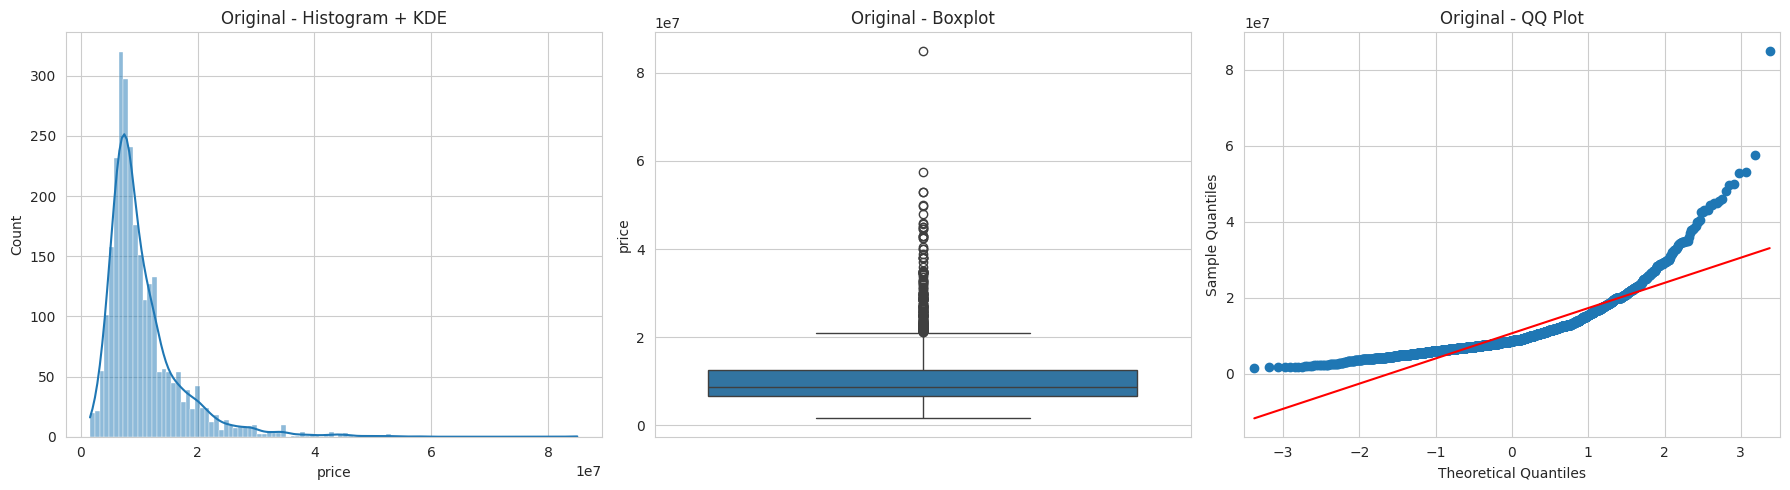


📊 Log-transformed target:


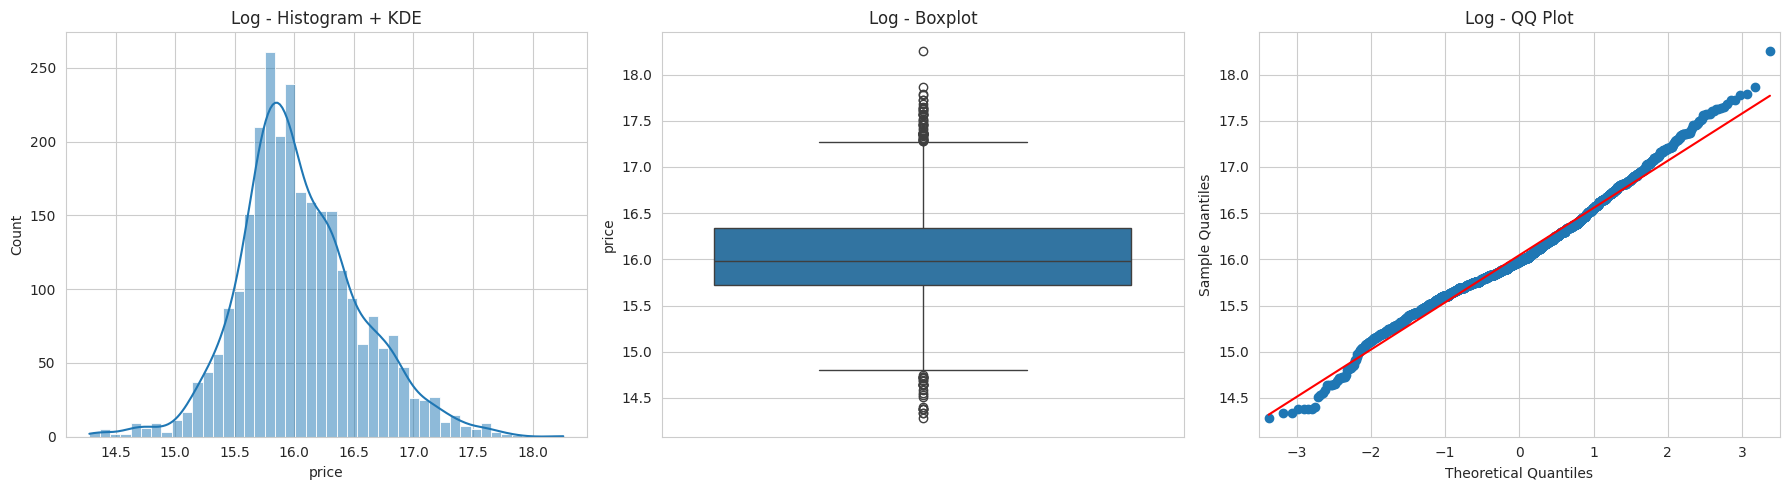


📊 Box-Cox (λ=-0.184):


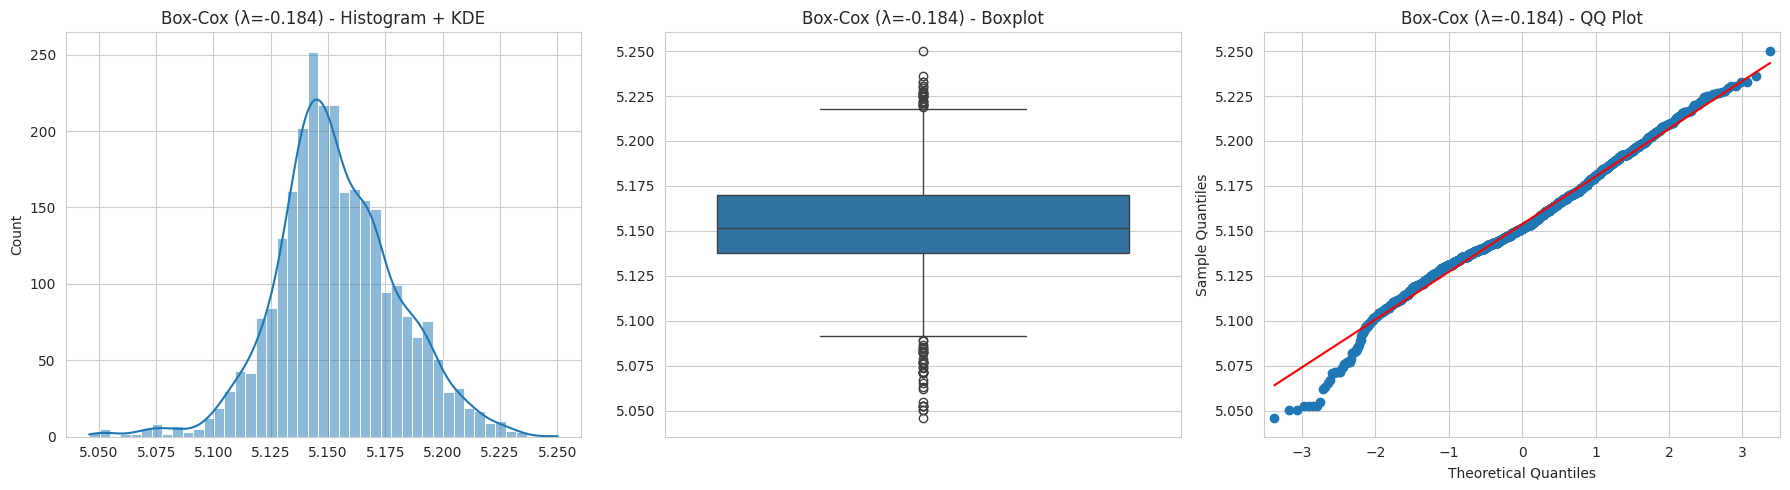


📊 Yeo-Johnson (λ=-0.184):


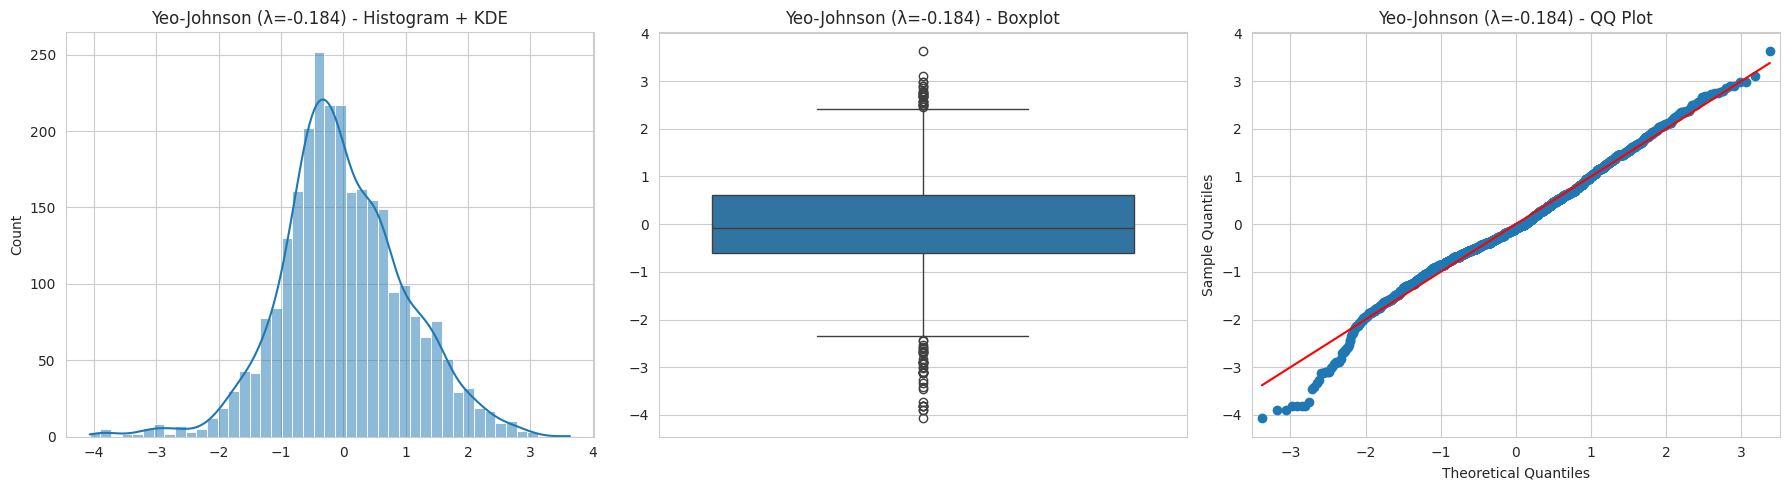

In [ ]:
transform_target_explorer(y_train, winsorize=False)


In [ ]:
y_train = np.log(y_train)
y_valid = np.log(y_valid)
y_test = np.log(y_test)


### 5.6 Scaling, normalization and standardization

Standardization is needed because:
- Linear models (OLS, Ridge, Lasso) assume coefficients are comparable. But if one variable is in millions and another in decimals, the scale difference distorts learning and regularization.

- Helps regularization techniques like Ridge/Lasso treat all coefficients fairly.

- It improves numerical stability and convergence for solvers (gradient descent, etc.).

Normalization is useful when:
- The feature is strongly skewed (right/left).

- You want to reduce outlier influence.

- You want better approximation of linearity between feature and target (which linear models love).

- You plan to use models sensitive to feature distribution (e.g., LDA, logistic regression)

In [ ]:
"""

from sklearn.preprocessing import PowerTransformer, StandardScaler

# 1. Normalize skewed data
pt = PowerTransformer(method='yeo-johnson')
X_train[continuous] = pt.fit_transform(X_train[continuous])
X_valid[continuous] = pt.transform(X_valid[continuous])
X_test[continuous]  = pt.transform(X_test[continuous])

# 2. Standardize
scaler = StandardScaler()
X_train[continuous] = scaler.fit_transform(X_train[continuous])
X_valid[continuous] = scaler.transform(X_valid[continuous])
X_test[continuous]  = scaler.transform(X_test[continuous])
"""


"\n\nfrom sklearn.preprocessing import PowerTransformer, StandardScaler\n\n# 1. Normalize skewed data\npt = PowerTransformer(method='yeo-johnson')\nX_train[continuous] = pt.fit_transform(X_train[continuous])\nX_valid[continuous] = pt.transform(X_valid[continuous])\nX_test[continuous]  = pt.transform(X_test[continuous])\n\n# 2. Standardize\nscaler = StandardScaler()\nX_train[continuous] = scaler.fit_transform(X_train[continuous])\nX_valid[continuous] = scaler.transform(X_valid[continuous])\nX_test[continuous]  = scaler.transform(X_test[continuous])\n"

In [ ]:
"""
import pandas as pd
import numpy as np

from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# === INPUTS ===
# Provide these from your earlier code
# continuous = [...your list of continuous numeric features...]
# categorical = [...your list of categorical features...]
# num_keep = [...your filtered numeric features to keep...]
# cat_keep = [...your filtered categorical features to keep...]

# === NUMERICAL PIPELINE ===
# chain of multiple transformers
# first normalizes skewed data (PowerTransformer), then standardize features (mean = 0, std = 1)
num_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

# === CATEGORICAL PIPELINE ===
# just a single transformer - One-Hot encoder
cat_pipeline = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# === COMBINED PREPROCESSOR ===
# Apply the numerical pipeline to the columns in continuous, apply the categorical encoder to the columns in categorical
# Then it stitches together the outputs (numerical + encoded categoricals) into one combined NumPy array.
# We can then .fit_transform() this preprocessor on our training set, and just .transform() it on validation/test sets.
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical),
    ('cat', cat_pipeline, categorical)
])

# === FIT ON TRAINING DATA ===
X_train_full = preprocessor.fit_transform(X_train)
X_valid_full = preprocessor.transform(X_valid)
X_test_full  = preprocessor.transform(X_test)

# === GET FEATURE NAMES AFTER TRANSFORMATIONS ===
num_features = numerical  # Names stay the same
cat_encoder = preprocessor.named_transformers_['cat']
ohe_features = cat_encoder.get_feature_names_out(categorical)

full_feature_names = num_features + list(ohe_features)

# === CONVERT TO DATAFRAMES ===
X_train_full = pd.DataFrame(X_train_full, columns=full_feature_names, index=X_train.index)
X_valid_full = pd.DataFrame(X_valid_full, columns=full_feature_names, index=X_valid.index)
X_test_full  = pd.DataFrame(X_test_full, columns=full_feature_names, index=X_test.index)

# === OPTIONAL: REDUCED FEATURE SET ===
# Filter one-hot features to only those from selected cat_keep
# This correctly filters only encoded categorical features from cat_keep
ohe_keep = [col for col in ohe_features if any(col.startswith(cat + '_') for cat in cat_keep)]

# Now combine with numerical features
features_keep = num_keep + ohe_keep

missing = [f for f in features_keep if f not in X_train_full.columns]
print("Missing from X_train_full:", missing)

# Select reduced sets
X_train_reduced = X_train_full[features_keep].copy()
X_valid_reduced = X_valid_full[features_keep].copy()
X_test_reduced  = X_test_full[features_keep].copy()

"""

'\nimport pandas as pd\nimport numpy as np\n\nfrom sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.compose import ColumnTransformer\n\n# === INPUTS ===\n# Provide these from your earlier code\n# continuous = [...your list of continuous numeric features...]\n# categorical = [...your list of categorical features...]\n# num_keep = [...your filtered numeric features to keep...]\n# cat_keep = [...your filtered categorical features to keep...]\n\n# === NUMERICAL PIPELINE ===\n# chain of multiple transformers\n# first normalizes skewed data (PowerTransformer), then standardize features (mean = 0, std = 1)\nnum_pipeline = Pipeline([\n    (\'power\', PowerTransformer(method=\'yeo-johnson\')),\n    (\'scale\', StandardScaler())\n])\n\n# === CATEGORICAL PIPELINE ===\n# just a single transformer - One-Hot encoder\ncat_pipeline = OneHotEncoder(drop=\'first\', sparse_output=False, handle_unknown=\'ignore\')\n\n# === CO

In [ ]:
X_train.shape

(2745, 40)

In [ ]:
print(len(numerical), len(categorical))
print(numerical, categorical)

19 10
['floorage', 'balcony', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'total_floors_NA', 'building_age', 'is_ground_floor'] ['building', 'property_status', 'ownership', 'property_location', 'water', 'heating', 'gas', 'waste', 'district', 'layout']


In [ ]:
print(len(num_keep), len(cat_keep))
print(num_keep, cat_keep)

19 10
['floorage', 'balcony', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'total_floors_NA', 'building_age', 'is_ground_floor'] ['building', 'property_status', 'ownership', 'property_location', 'water', 'heating', 'gas', 'waste', 'district', 'layout']


In [ ]:
# === FINAL FEATURE SELECTION ===
selected_features = numerical + categorical

# Limit data to selected features
X_train = X_train[selected_features].copy()
X_valid = X_valid[selected_features].copy()
X_test  = X_test[selected_features].copy()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# === FINAL FEATURE SETS ===
# Use only selected features after analysis
# numerical = num_keep
# categorical = cat_keep

# === NUMERICAL PIPELINE ===
num_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

# === CATEGORICAL PIPELINE ===
#cat_encoder.fit(pd.concat([X_train, X_valid, X_test])[categorical])
cat_pipeline = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# === COMBINED PREPROCESSOR ===
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical),
    ('cat', cat_pipeline, categorical)
])


# === SAVE ORIGINAL INDEXES BEFORE TRANSFORMATION ===
X_train_index = X_train.index
X_valid_index = X_valid.index
X_test_index  = X_test.index

# === FIT AND TRANSFORM ===
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
X_test  = preprocessor.transform(X_test)

# === FEATURE NAMES ===
cat_encoder = preprocessor.named_transformers_['cat']
ohe_features = cat_encoder.get_feature_names_out(categorical)
all_feature_names = numerical + list(ohe_features)

# === CONVERT TO DATAFRAMES ===
X_train = pd.DataFrame(X_train, columns=all_feature_names, index=X_train_index)
X_valid = pd.DataFrame(X_valid, columns=all_feature_names, index=X_valid_index)
X_test  = pd.DataFrame(X_test,  columns=all_feature_names, index=X_test_index)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# Same but modular and reusable
"""
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd

def preprocess_features(X_train, X_valid, X_test, num_keep, cat_keep):
    ""
    Transforms training, validation, and test sets using:
      - Power + Standard scaling for numerical features
      - One-hot encoding for categorical features
    Parameters:
        X_train, X_valid, X_test: pandas DataFrames
        num_keep: list of selected numerical features
        cat_keep: list of selected categorical features
    Returns:
        X_train_transformed, X_valid_transformed, X_test_transformed, feature_names
    ""
    # === Define pipelines ===
    num_pipeline = Pipeline([
        ('power', PowerTransformer(method='yeo-johnson')),
        ('scale', StandardScaler())
    ])

    cat_pipeline = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

    # === Combine ===
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, num_keep),
        ('cat', cat_pipeline, cat_keep)
    ])

    # === Fit on train, transform all ===
    X_train_array = preprocessor.fit_transform(X_train)
    X_valid_array = preprocessor.transform(X_valid)
    X_test_array  = preprocessor.transform(X_test)

    # === Feature names ===
    cat_encoder = preprocessor.named_transformers_['cat']
    ohe_features = cat_encoder.get_feature_names_out(cat_keep)
    all_feature_names = num_keep + list(ohe_features)

    # === Convert to DataFrames ===
    X_train_out = pd.DataFrame(X_train_array, columns=all_feature_names, index=X_train.index)
    X_valid_out = pd.DataFrame(X_valid_array, columns=all_feature_names, index=X_valid.index)
    X_test_out  = pd.DataFrame(X_test_array, columns=all_feature_names, index=X_test.index)

    return X_train_out, X_valid_out, X_test_out, all_feature_names


X_train, X_valid, X_test, feature_names = preprocess_features(
    X_train=X_train,
    X_valid=X_valid,
    X_test=X_test,
    num_keep=num_keep,
    cat_keep=cat_keep
)
"""

'\nfrom sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.compose import ColumnTransformer\nimport pandas as pd\n\ndef preprocess_features(X_train, X_valid, X_test, num_keep, cat_keep):\n    ""\n    Transforms training, validation, and test sets using:\n      - Power + Standard scaling for numerical features\n      - One-hot encoding for categorical features\n    Parameters:\n        X_train, X_valid, X_test: pandas DataFrames\n        num_keep: list of selected numerical features\n        cat_keep: list of selected categorical features\n    Returns:\n        X_train_transformed, X_valid_transformed, X_test_transformed, feature_names\n    ""\n    # === Define pipelines ===\n    num_pipeline = Pipeline([\n        (\'power\', PowerTransformer(method=\'yeo-johnson\')),\n        (\'scale\', StandardScaler())\n    ])\n\n    cat_pipeline = OneHotEncoder(drop=\'first\', sparse_output=False, handle_unknown=\'ignore

In [ ]:
X_valid.shape

(687, 75)

In [ ]:
X_train.shape

(2745, 75)

In [ ]:
X_valid.shape

(687, 75)

In [ ]:
X_train.columns

Index(['floorage', 'balcony', 'furnished', 'terrace', 'cellar', 'parking',
       'garden_area', 'garage', 'loggia', 'basin_area', 'floor_number',
       'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA',
       'final_building_approval_year_NA', 'total_floors_NA', 'building_age',
       'is_ground_floor', 'building_Framed structure', 'building_Missing',
       'building_Mixed', 'building_Panel', 'building_Stone', 'building_Wooden',
       'property_status_In good condition', 'property_status_In renovation',
       'property_status_In very good condition', 'property_status_Missing',
       'property_status_New development projects', 'property_status_New homes',
       'property_status_Renovated', 'property_status_Under construction',
       'ownership_Missing', 'ownership_Personal',
       'ownership_State-owned/municipal',
       'property_location_Housing development', 'property_location_Missing',
       'property_location_Municipality centre',
       'property_locatio

# 6. Model Feature Selection & Preparation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_selection import RFE, SelectFromModel, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning
import warnings
import time

def feature_selection_pipeline(X, y, tolerance=0.01, include_permutation=False, verbose=True):
    """
    Feature selection using RFE, Ridge SFM, and Sequential Feature Selectors (FWD/BKWD).
    Returns top features selected most frequently across selectors.
    """

    # --- Setup ---
    start = time.time()
    warnings.simplefilter("ignore", ConvergenceWarning)
    features = X.columns.tolist()
    max_features = len(features)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    if verbose:
        print(f"\n🚀 Starting feature selection on {max_features} features...\n")

    # --- Step 1: RFE-Based Feature Count Selection ---
    scores = []

    for n in range(5, min(max_features + 1, 40)):  # avoid full range for speed
        rfe = RFE(LinearRegression(), n_features_to_select=n)
        rfe.fit(X, y)
        selected = X.columns[rfe.support_]
        score = cross_val_score(LinearRegression(), X[selected], y, cv=cv, scoring='r2', n_jobs=-1).mean()
        scores.append(score)

    best_score = max(scores)
    for i, score in enumerate(scores):
        if best_score - score <= tolerance:
            n_opt = i + 5  # offset for start at 5
            break

    if verbose:
        print(f"[✔] Optimal number of features (RFE): {n_opt}")

        plt.figure(figsize=(8, 5))
        plt.plot(range(5, 5 + len(scores)), scores, label="CV R²")
        plt.axvline(n_opt, color='r', linestyle='--', label=f"Selected: {n_opt}")
        plt.xlabel("Number of Features")
        plt.ylabel("CV R² Score")
        plt.title("RFE Feature Count Selection")
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

    selected_all = []

    # --- Step 2: RFE Final ---
    rfe = RFE(LinearRegression(), n_features_to_select=n_opt)
    rfe.fit(X, y)
    selected_rfe = X.columns[rfe.support_].tolist()
    selected_all += selected_rfe
    if verbose:
        print(f"[✔] RFE selected: {selected_rfe}")

    # --- Step 3: Ridge + SFM ---
    ridge = RidgeCV(alphas=np.logspace(-6, 6, 5), cv=cv)
    ridge.fit(X, y)
    importance = np.abs(ridge.coef_)
    threshold = np.sort(importance)[-n_opt] + 1e-6
    sfm = SelectFromModel(ridge, threshold=threshold, prefit=True)
    selected_sfm = X.columns[sfm.get_support()].tolist()
    selected_all += selected_sfm
    if verbose:
        print(f"[✔] Ridge SFM selected: {selected_sfm}")

    # --- Step 4: SFS (Forward and Backward) ---
    sfs_fwd = SequentialFeatureSelector(ridge, n_features_to_select=n_opt, direction="forward", cv=cv, scoring='r2', n_jobs=-1)
    sfs_fwd.fit(X, y)
    selected_fwd = X.columns[sfs_fwd.get_support()].tolist()
    selected_all += selected_fwd

    sfs_bkwd = SequentialFeatureSelector(ridge, n_features_to_select=n_opt, direction="backward", cv=cv, scoring='r2', n_jobs=-1)
    sfs_bkwd.fit(X, y)
    selected_bkwd = X.columns[sfs_bkwd.get_support()].tolist()
    selected_all += selected_bkwd

    if verbose:
        print(f"[✔] SFS Forward selected: {selected_fwd}")
        print(f"[✔] SFS Backward selected: {selected_bkwd}")

    # --- Step 5: Voting ---
    counter = Counter(selected_all)
    top_features = [feat for feat, count in counter.most_common(n_opt)]

    if verbose:
        print(f"\n[🏁] Final Top {n_opt} Features by Voting:\n", top_features)

    # --- Step 6: Optional Permutation Importance ---
    if include_permutation:
        model = LinearRegression()
        model.fit(X[top_features], y)
        result = permutation_importance(model, X[top_features], y, scoring='r2', n_repeats=30, random_state=42)
        sorted_idx = result.importances_mean.argsort()[::-1]
        print("\n[🧪] Permutation Importance:")
        for i in sorted_idx:
            print(f"{top_features[i]}: {result.importances_mean[i]:.4f}")

    if verbose:
        duration = time.time() - start
        print(f"\n⏱️ Feature selection completed in {duration:.2f} seconds.")

    return top_features


In [ ]:
from google.colab import drive
import pandas as pd

# === Mount Google Drive ===
# drive.mount('/content/drive')

# === Define file path in Google Drive ===
drive_dir = '/content/drive/My Drive/Colab Notebooks/'
top_features_path = drive_dir + 'top_features.csv'

# === Your run toggle ===
RUN_HEAVY = False  # Set to False to skip recomputing

# === Heavy feature selection logic ===
if RUN_HEAVY:
    top_features = feature_selection_pipeline(X_train, y_train, include_permutation=True)

    # Save to Drive
    pd.Series(top_features).to_csv(top_features_path, index=False)
    print(f"✅ Saved top features to: {top_features_path}")
else:
    try:
        top_features = pd.read_csv(top_features_path).squeeze().tolist()
        print(f"✅ Loaded top features from: {top_features_path}")
    except FileNotFoundError:
        print(f"❌ File not found: {top_features_path}\nSet RUN_HEAVY = True to regenerate.")


✅ Loaded top features from: /content/drive/My Drive/Colab Notebooks/top_features.csv


In [ ]:
top_features

['square_meters',
 'building_Panel',
 'property_status_New homes',
 'ownership_Personal',
 'district_Praha 1',
 'district_Praha 2',
 'district_Praha 7',
 'layout_4+kt',
 'layout_5+kt',
 'property_status_In very good condition',
 'property_status_New development projects',
 'property_status_Under construction',
 'district_Praha 3',
 'district_Praha 4',
 'district_Praha 5',
 'district_Praha 6',
 'district_Praha 8',
 'layout_3+kt',
 'usable_area_NA',
 'ownership_State-owned/municipal',
 'waste_other',
 'district_Praha 10',
 'district_Praha 9',
 'layout_unusual']

In [ ]:
# Then run feature selection for linear models:
X_train_reduced = X_train[top_features]
X_valid_reduced = X_valid[top_features]
X_test_reduced  = X_test[top_features]

# 7. Model selection

In [ ]:
!pip install xgboost lightgbm catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.5 MB/s eta 0:00:00


In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 10.7 MB/s eta 0:00:00


In [ ]:
list(X_train_full.columns)

['usable_area',
 'floorage',
 'balcony',
 'energy_performance_certificate',
 'furnished',
 'terrace',
 'cellar',
 'parking',
 'garden_area',
 'garage',
 'loggia',
 'final_building_approval_year',
 'basin_area',
 'floor_number',
 'total_floors',
 'square_meters',
 'usable_area_NA',
 'floorage_NA',
 'final_building_approval_year_NA',
 'floor_number_NA',
 'total_floors_NA',
 'building_age',
 'total_area',
 'is_top_floor',
 'is_ground_floor',
 'building',
 'property_status',
 'ownership',
 'property_location',
 'water',
 'heating',
 'gas',
 'energy_performance_rating',
 'waste',
 'street',
 'district',
 'cadastral_area',
 'layout']

BLABLA - SAVED CORRECT VERSION

In [ ]:
# Step 7 — Fast tuning (CV), stacking, weighted blending & saving  [FIXED]

import re, multiprocessing as mp
import optuna
from optuna.pruners import MedianPruner
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

from pandas.api.types import is_string_dtype, is_categorical_dtype

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)

# ======== SPEED KNOBS ========
N_TRIALS_TREES   = 60   # trials for tree models
N_TRIALS_LINEAR  = 40   # trials for linear models
CV_TUNE_SPLITS   = 3    # fast CV during tuning
CV_REPORT_SPLITS = 5    # stable CV for reporting
TOP_N_FOR_STACK  = 3    # base models in stack
OPTUNA_WORKERS   = max(1, mp.cpu_count() // 2)
# =============================

# ---------------------------
# OUTPUT FOLDERS
# ---------------------------
save_dir = Path("models")
save_dir.mkdir(exist_ok=True)
leaderboard_path = save_dir / "leaderboard.csv"

# ---------------------------
# Column sanitization
# ---------------------------
def build_sanitization_map(cols):
    mapping, used = {}, {}
    for i, col in enumerate(cols):
        base = re.sub(r"\W+", "_", str(col)).strip("_") or f"col_{i}"
        name, k = base, 1
        while name in used:
            name = f"{base}_{k}"
            k += 1
        used[name] = True
        mapping[col] = name
    return mapping

def apply_map_to_df(df, mapping):
    return df.rename(columns=mapping)

sanit_map = build_sanitization_map(list(X_train_full.columns))

X_train_full_s   = apply_map_to_df(X_train_full, sanit_map)
X_valid_full_s   = apply_map_to_df(X_valid_full, sanit_map)
X_test_full_s    = apply_map_to_df(X_test_full,  sanit_map)

X_train_reduced_s = apply_map_to_df(X_train_reduced, sanit_map)
X_valid_reduced_s = apply_map_to_df(X_valid_reduced, sanit_map)
X_test_reduced_s  = apply_map_to_df(X_test_reduced,  sanit_map)

reduced_feature_names = list(X_train_reduced_s.columns)

# ---------------------------
# Robust categorical detection (object, string, category)
# ---------------------------
def find_cats(df: pd.DataFrame):
    cols = []
    for c in df.columns:
        dt = df[c].dtype
        if dt == object or is_string_dtype(dt) or is_categorical_dtype(dt):
            cols.append(c)
    return cols

cat_full    = set(find_cats(X_train_full_s))
cat_reduced = set(find_cats(X_train_reduced_s))
cat_union   = sorted(list(cat_full.union(cat_reduced)))

# Save CatBoost indices (for info; CatBoost will still work on ints if we don't pass cat_features)
cat_idx_full    = [list(X_train_full_s.columns).index(c) for c in X_train_full_s.columns if c in cat_union]
cat_idx_reduced = [list(X_train_reduced_s.columns).index(c) for c in X_train_reduced_s.columns if c in cat_union]

# ---------------------------
# Label-encode categoricals for tree/XGB/LGBM/RF/GB
# (linear models should not need these high-cardinality cols in the reduced set)
# ---------------------------
label_encoders = {}
if len(cat_union) > 0:
    for col in cat_union:
        if col in X_train_full_s.columns:
            le = LabelEncoder()
            all_vals = pd.concat(
                [X_train_full_s[col], X_valid_full_s.get(col, pd.Series(dtype="object")),
                 X_test_full_s.get(col, pd.Series(dtype="object"))], axis=0
            ).astype("string").fillna("NA_LE")
            le.fit(all_vals)

            for df in [X_train_full_s, X_valid_full_s, X_test_full_s]:
                if col in df.columns:
                    df[col] = le.transform(df[col].astype("string").fillna("NA_LE"))

            # apply to reduced views if present
            for df in [X_train_reduced_s, X_valid_reduced_s, X_test_reduced_s]:
                if col in df.columns:
                    df[col] = le.transform(df[col].astype("string").fillna("NA_LE"))

            label_encoders[col] = le

# Final guard: ensure numeric-only for all training frames
def assert_numeric(df, name):
    non_num = df.select_dtypes(exclude=[np.number]).columns.tolist()
    if len(non_num):
        raise ValueError(f"{name} still has non-numeric columns after encoding: {non_num}")

assert_numeric(X_train_full_s,   "X_train_full_s")
assert_numeric(X_valid_full_s,   "X_valid_full_s")
assert_numeric(X_train_reduced_s,"X_train_reduced_s")
assert_numeric(X_valid_reduced_s,"X_valid_reduced_s")

# ---------------------------
# Model registry
# ---------------------------
model_classes = {
    "LinearRegression": LinearRegression,
    "Ridge": Ridge,
    "Lasso": Lasso,
    "ElasticNet": ElasticNet,
    "RandomForest": RandomForestRegressor,
    "GradientBoosting": GradientBoostingRegressor,
    "XGBoost": XGBRegressor,
    "LightGBM": LGBMRegressor,
    "CatBoost": CatBoostRegressor
}

use_reduced = {
    "LinearRegression": True,
    "Ridge": True,
    "Lasso": True,
    "ElasticNet": True,
    "RandomForest": False,
    "GradientBoosting": False,
    "XGBoost": False,
    "LightGBM": False,
    "CatBoost": False
}

# ---------------------------
# Optuna objective (fast CV)
# ---------------------------
def objective(trial, model_name, X, y):
    params = {}
    if model_name == "LinearRegression":
        pass
    elif model_name == "Ridge":
        params = {"alpha": trial.suggest_float("alpha", 1e-3, 10, log=True), "random_state": SEED}
    elif model_name == "Lasso":
        params = {"alpha": trial.suggest_float("alpha", 1e-5, 1.0, log=True), "random_state": SEED, "max_iter": 2000}
    elif model_name == "ElasticNet":
        params = {
            "alpha": trial.suggest_float("alpha", 1e-5, 1.0, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "random_state": SEED,
            "max_iter": 2000
        }
    elif model_name == "RandomForest":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
            "max_depth": trial.suggest_int("max_depth", 5, 28),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 6),
            "n_jobs": -1,
            "random_state": SEED
        }
    elif model_name == "GradientBoosting":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.25),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "random_state": SEED
        }
    elif model_name == "XGBoost":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.25),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
            "n_jobs": -1,
            "verbosity": 0,
            "random_state": SEED,
            "tree_method": "hist"
        }
    elif model_name == "LightGBM":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "num_leaves": trial.suggest_int("num_leaves", 31, 255),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.7, 1.0),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
            "n_jobs": -1,
            "random_state": SEED
        }
    elif model_name == "CatBoost":
        params = {
            "iterations": trial.suggest_int("iterations", 300, 1200, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "depth": trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "loss_function": "RMSE",
            "verbose": 0,
            "random_seed": SEED
        }

    Model = model_classes[model_name](**params)
    cv_fast = KFold(n_splits=CV_TUNE_SPLITS, shuffle=True, random_state=SEED)
    scores = cross_val_score(Model, X, y, scoring="neg_mean_squared_error", cv=cv_fast, n_jobs=-1)
    rmse_mean = float(np.mean(np.sqrt(-scores)))
    return rmse_mean



/tmp/ipython-input-18332076.py:82: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if dt == object or is_string_dtype(dt) or is_categorical_dtype(dt):


In [ ]:

# ---------------------------
# Main tuning + fit
# ---------------------------
results = []
best_params_store = {}
cv_report = KFold(n_splits=CV_REPORT_SPLITS, shuffle=True, random_state=SEED)

for model_name in model_classes.keys():
    print(f"\n🔍 Tuning {model_name} ...")

    Xtr = X_train_reduced_s if use_reduced[model_name] else X_train_full_s
    Xval = X_valid_reduced_s if use_reduced[model_name] else X_valid_full_s

    n_trials = N_TRIALS_LINEAR if use_reduced[model_name] else N_TRIALS_TREES
    study = optuna.create_study(direction="minimize", pruner=MedianPruner(n_warmup_steps=5))
    study.optimize(lambda t: objective(t, model_name, Xtr, y_train),
                   n_trials=n_trials, n_jobs=OPTUNA_WORKERS, show_progress_bar=False)

    best_params = study.best_params
    best_params_store[model_name] = best_params

    # ensure speed flags on final model
    if model_name == "RandomForest":
        best_params.update({"n_jobs": -1, "random_state": SEED})
    elif model_name == "XGBoost":
        best_params.setdefault("n_jobs", -1)
        best_params.setdefault("tree_method", "hist")
        best_params.setdefault("verbosity", 0)
        best_params["random_state"] = SEED
    elif model_name == "LightGBM":
        best_params.setdefault("n_jobs", -1)
        best_params["random_state"] = SEED
    elif model_name == "CatBoost":
        best_params.setdefault("verbose", 0)
        best_params["random_seed"] = SEED

    final_model = model_classes[model_name](**best_params)
    final_model.fit(Xtr, y_train)

    # Evaluate on validation
    val_preds = final_model.predict(Xval)
    rmse = float(np.sqrt(mean_squared_error(y_valid, val_preds)))
    mae  = float(mean_absolute_error(y_valid, val_preds))
    r2   = float(r2_score(y_valid, val_preds))

    # Report 5-fold CV for stability
    cv_scores = cross_val_score(clone(final_model), Xtr, y_train,
                                scoring="neg_mean_squared_error", cv=cv_report, n_jobs=-1)
    cv_rmse = np.sqrt(-cv_scores)
    cv_rmse_mean = float(cv_rmse.mean())
    cv_rmse_std  = float(cv_rmse.std())

    joblib.dump(final_model, save_dir / f"{model_name}.pkl")

    results.append({
        "Model": model_name,
        "Best_Params": best_params,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "CV_RMSE_MEAN": cv_rmse_mean,
        "CV_RMSE_STD": cv_rmse_std
    })

# ---------------------------
# Weighted blending (non-neg, normalized)
# ---------------------------
df_results = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)
top_models = df_results.head(TOP_N_FOR_STACK)["Model"].tolist()

val_meta = []
for m in top_models:
    mdl = joblib.load(save_dir / f"{m}.pkl")
    Xval = X_valid_reduced_s if use_reduced[m] else X_valid_full_s
    val_meta.append(mdl.predict(Xval))
val_meta = np.vstack(val_meta).T  # (n_val, topN)

lin_blender = LinearRegression(fit_intercept=False)
lin_blender.fit(val_meta, y_valid)
w = lin_blender.coef_.astype(float)
w[w < 0] = 0.0
w = w / (w.sum() if w.sum() > 0 else len(w))

blend_preds = val_meta @ w
blend_rmse = float(np.sqrt(mean_squared_error(y_valid, blend_preds)))
blend_mae  = float(mean_absolute_error(y_valid, blend_preds))
blend_r2   = float(r2_score(y_valid, blend_preds))

results.append({
    "Model": f"WeightedBlend({', '.join(top_models)})",
    "Best_Params": {"weights": w.tolist()},
    "RMSE": blend_rmse,
    "MAE": blend_mae,
    "R2": blend_r2
})

# ---------------------------
# Stacking (trimmed for speed)
# ---------------------------
stack_estimators = []
for m in top_models:
    params = best_params_store.get(m, {})
    base = model_classes[m](**params)
    if use_reduced[m]:
        sel = FunctionTransformer(lambda df, cols=reduced_feature_names: df[cols], validate=False)
        pipe = Pipeline([("select", sel), ("est", base)])
        stack_estimators.append((m, pipe))
    else:
        stack_estimators.append((m, base))

meta = CatBoostRegressor(random_seed=SEED, verbose=0, iterations=500, depth=6, learning_rate=0.05)

stacker = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=meta,
    passthrough=False,  # faster
    cv=3,
    n_jobs=-1
)

stacker.fit(X_train_full_s, y_train)
joblib.dump(stacker, save_dir / "stacked_model.pkl")

stack_preds = stacker.predict(X_valid_full_s)
stack_rmse  = float(np.sqrt(mean_squared_error(y_valid, stack_preds)))
stack_mae   = float(mean_absolute_error(y_valid, stack_preds))
stack_r2    = float(r2_score(y_valid, stack_preds))

results.append({
    "Model": f"Stacked({', '.join(top_models)})",
    "Best_Params": "stack_cv3",
    "RMSE": stack_rmse,
    "MAE": stack_mae,
    "R2": stack_r2
})

# ---------------------------
# Save leaderboard
# ---------------------------
leaderboard_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)
leaderboard_df.to_csv(leaderboard_path, index=False)

print("\n🏆 Leaderboard:")
print(leaderboard_df)
print(f"✅ Leaderboard saved to {leaderboard_path}")
print(f"✅ Models saved in {save_dir}")

[I 2025-09-18 17:13:00,215] A new study created in memory with name: no-name-f22dda00-c250-4d12-854a-8fc448dbca53



🔍 Tuning LinearRegression ...


[I 2025-09-18 17:13:08,274] Trial 0 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-09-18 17:13:08,400] Trial 1 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-09-18 17:13:08,516] Trial 2 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-09-18 17:13:08,598] Trial 3 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-09-18 17:13:08,710] Trial 4 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-09-18 17:13:08,796] Trial 5 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-09-18 17:13:08,910] Trial 6 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950


🔍 Tuning Ridge ...


[I 2025-09-18 17:13:12,381] Trial 1 finished with value: 0.23000765032775328 and parameters: {'alpha': 0.002178670616257552}. Best is trial 1 with value: 0.23000765032775328.
[I 2025-09-18 17:13:12,465] Trial 2 finished with value: 0.2301225845547201 and parameters: {'alpha': 0.6440140321287813}. Best is trial 1 with value: 0.23000765032775328.
[I 2025-09-18 17:13:12,553] Trial 3 finished with value: 0.23000284665318504 and parameters: {'alpha': 0.09566727328565128}. Best is trial 3 with value: 0.23000284665318504.
[I 2025-09-18 17:13:12,650] Trial 4 finished with value: 0.2300030159079253 and parameters: {'alpha': 0.10002510896429598}. Best is trial 3 with value: 0.23000284665318504.
[I 2025-09-18 17:13:12,717] Trial 5 finished with value: 0.2300050837084097 and parameters: {'alpha': 0.021882342525566607}. Best is trial 3 with value: 0.23000284665318504.
[I 2025-09-18 17:13:12,796] Trial 6 finished with value: 0.23000611035122195 and parameters: {'alpha': 0.013083427595215781}. Best i

...

[LightGBM] [Warning] min_data_in_leaf is set=59, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=59
[LightGBM] [Warning] feature_fraction is set=0.9037828554665903, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9037828554665903
[LightGBM] [Warning] bagging_fraction is set=0.9360563094633576, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9360563094633576
[LightGBM] [Warning] min_data_in_leaf is set=59, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=59
[LightGBM] [Warning] feature_fraction is set=0.9037828554665903, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9037828554665903
[LightGBM] [Warning] bagging_fraction is set=0.9360563094633576, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9360563094633576
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000684 seconds.
You can set `force_row_wise=true` to remove the ov

[I 2025-09-18 17:58:39,020] A new study created in memory with name: no-name-a3a4274a-8c1a-4f17-8b1e-24e841443c08



🔍 Tuning CatBoost ...


[I 2025-09-18 17:58:49,679] Trial 0 finished with value: 0.184927112852463 and parameters: {'iterations': 500, 'learning_rate': 0.08052481123327627, 'depth': 7, 'l2_leaf_reg': 1.0860349097814175}. Best is trial 0 with value: 0.184927112852463.
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[I 2025-09-18 18:00:26,240] Trial 1 finished with value: 0.18664845853142684 and parameters: {'iterations': 1000, 'learning_rate': 0.05689821703823332, 'depth': 10, 'l2_leaf_reg': 9.736040875652625}. Best is trial 0 with value: 0.184927112852463.
[I 2025-09-18 18:00:56,377] Trial 2 finished with value: 0.18897603051273668 and parameters: {'iterations': 600, 'learning_rate': 0.11924358232494991, 'depth': 9, 'l2_leaf_reg': 9.836895263619812}. Best is trial 0 with value: 0.184927112852463.
[I 2025-09-18 18


🏆 Leaderboard:
                                                Model  \
0   WeightedBlend(CatBoost, GradientBoosting, XGBo...   
1                                            CatBoost   
2                                    GradientBoosting   
3        Stacked(CatBoost, GradientBoosting, XGBoost)   
4                                             XGBoost   
5                                            LightGBM   
6                                        RandomForest   
7                                          ElasticNet   
8                                               Lasso   
9                                               Ridge   
10                                   LinearRegression   

                                          Best_Params      RMSE       MAE  \
0   {'weights': [0.5296702483921851, 0.47032975160...  0.187525  0.126409   
1   {'iterations': 1000, 'learning_rate': 0.064108...  0.189437  0.128945   
2   {'n_estimators': 800, 'learning_rate': 0.03040...  0.189685  0.1

In [ ]:
leaderboard_df.to_csv("/content/drive/MyDrive/flat_price_leaderboard.csv", index=False)


In [ ]:
# best_params_store.to_csv("/content/drive/MyDrive/flat_price_leaderboard.csv", index=False)

In [ ]:
results
best_params_store
val_meta
stack_estimators

[('CatBoost', <catboost.core.CatBoostRegressor at 0x7e37f23a7d40>),
 ('GradientBoosting',
  GradientBoostingRegressor(learning_rate=0.030403022914201296, max_depth=6,
                            n_estimators=800, subsample=0.6513851300055923)),
 ('XGBoost',
  XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.7747882320635833, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.15629170115105978,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_est

In [ ]:
leaderboard_df = pd.read_csv("/content/drive/MyDrive/flat_price_leaderboard.csv")


In [ ]:
"""

# ---------------------------
# Column sanitization
# ---------------------------
def build_sanitization_map(cols):
    mapping, used = {}, {}
    for i, col in enumerate(cols):
        base = re.sub(r"\W+", "_", str(col)).strip("_") or f"col_{i}"
        name, k = base, 1
        while name in used:
            name = f"{base}_{k}"
            k += 1
        used[name] = True
        mapping[col] = name
    return mapping

def apply_map_to_df(df, mapping):
    return df.rename(columns=mapping)

sanit_map = build_sanitization_map(list(X_train_full.columns))

X_train_full_s   = apply_map_to_df(X_train_full, sanit_map)
X_valid_full_s   = apply_map_to_df(X_valid_full, sanit_map)
X_test_full_s    = apply_map_to_df(X_test_full,  sanit_map)

X_train_reduced_s = apply_map_to_df(X_train_reduced, sanit_map)
X_valid_reduced_s = apply_map_to_df(X_valid_reduced, sanit_map)
X_test_reduced_s  = apply_map_to_df(X_test_reduced,  sanit_map)

reduced_feature_names = list(X_train_reduced_s.columns)
"""

<>:9: SyntaxWarning: invalid escape sequence '\W'
<>:9: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipython-input-2659406715.py:9: SyntaxWarning: invalid escape sequence '\W'
  base = re.sub(r"\W+", "_", str(col)).strip("_") or f"col_{i}"


'\n\n# ---------------------------\n# Column sanitization\n# ---------------------------\ndef build_sanitization_map(cols):\n    mapping, used = {}, {}\n    for i, col in enumerate(cols):\n        base = re.sub(r"\\W+", "_", str(col)).strip("_") or f"col_{i}"\n        name, k = base, 1\n        while name in used:\n            name = f"{base}_{k}"\n            k += 1\n        used[name] = True\n        mapping[col] = name\n    return mapping\n\ndef apply_map_to_df(df, mapping):\n    return df.rename(columns=mapping)\n\nsanit_map = build_sanitization_map(list(X_train_full.columns))\n\nX_train_full_s   = apply_map_to_df(X_train_full, sanit_map)\nX_valid_full_s   = apply_map_to_df(X_valid_full, sanit_map)\nX_test_full_s    = apply_map_to_df(X_test_full,  sanit_map)\n\nX_train_reduced_s = apply_map_to_df(X_train_reduced, sanit_map)\nX_valid_reduced_s = apply_map_to_df(X_valid_reduced, sanit_map)\nX_test_reduced_s  = apply_map_to_df(X_test_reduced,  sanit_map)\n\nreduced_feature_names = lis

In [ ]:
X_valid_full_s.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687 entries, 4279 to 1548
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   usable_area                      687 non-null    float64
 1   floorage                         687 non-null    float64
 2   balcony                          687 non-null    float64
 3   energy_performance_certificate   687 non-null    float64
 4   furnished                        687 non-null    float64
 5   terrace                          687 non-null    float64
 6   cellar                           687 non-null    float64
 7   parking                          687 non-null    float64
 8   garden_area                      687 non-null    float64
 9   garage                           687 non-null    float64
 10  loggia                           687 non-null    float64
 11  final_building_approval_year     687 non-null    float64
 12  basin_area             

In [ ]:
leaderboard_df

,Model,Best_Params,RMSE,MAE,R2,CV_RMSE_MEAN,CV_RMSE_STD
0,"WeightedBlend(CatBoost, GradientBoosting, XGBo...","{'weights': [0.5296702483921851, 0.47032975160...",0.187525,0.126409,0.851157,NaN,NaN
1,CatBoost,"{'iterations': 1000, 'learning_rate': 0.064108...",0.189437,0.128945,0.848105,0.179002,0.008514
2,GradientBoosting,"{'n_estimators': 800, 'learning_rate': 0.03040...",0.189685,0.126977,0.847708,0.184096,0.009468
3,"Stacked(CatBoost, GradientBoosting, XGBoost)",stack_cv3,0.195311,0.132865,0.838540,NaN,NaN
4,XGBoost,"{'n_estimators': 700, 'learning_rate': 0.15629...",0.198215,0.136081,0.833703,0.186580,0.006243
5,LightGBM,"{'n_estimators': 600, 'learning_rate': 0.05021...",0.199472,0.137040,0.831587,0.188104,0.005137
6,RandomForest,"{'n_estimators': 200, 'max_depth': 18, 'min_sa...",0.211925,0.142729,0.809903,0.211310,0.008920
7,ElasticNet,"{'alpha': 4.721750728920398e-05, 'l1_ratio': 0...",0.233478,0.163095,0.769270,0.229678,0.007740
8,Lasso,{'alpha': 1.0038480781316009e-05},0.233480,0.163116,0.769267,0.229684,0.007732
9,Ridge,{'alpha': 0.07473010966208919},0.233481,0.163124,0.769265,0.229676,0.007735


In [ ]:
X_train_reduced_s.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2745 entries, 1355 to 3948
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   square_meters                             2745 non-null   float64
 1   building_Panel                            2745 non-null   float64
 2   property_status_New homes                 2745 non-null   float64
 3   ownership_Personal                        2745 non-null   float64
 4   district_Praha 1                          2745 non-null   float64
 5   district_Praha 2                          2745 non-null   float64
 6   district_Praha 7                          2745 non-null   float64
 7   layout_4+kt                               2745 non-null   float64
 8   layout_5+kt                               2745 non-null   float64
 9   property_status_In very good condition    2745 non-null   float64
 10  property_status_New development projec

# 8. Final test evaluation, interpretation & deployment

,Model,Best_Params,RMSE,MAE,R2,CV_RMSE_MEAN,CV_RMSE_STD
0,"WeightedBlend(CatBoost, GradientBoosting, XGBo...","{'weights': [0.5296702483921851, 0.47032975160...",0.187525,0.126409,0.851157,NaN,NaN
1,CatBoost,"{'iterations': 1000, 'learning_rate': 0.064108...",0.189437,0.128945,0.848105,0.179002,0.008514
2,GradientBoosting,"{'n_estimators': 800, 'learning_rate': 0.03040...",0.189685,0.126977,0.847708,0.184096,0.009468
3,"Stacked(CatBoost, GradientBoosting, XGBoost)",stack_cv3,0.195311,0.132865,0.838540,NaN,NaN
4,XGBoost,"{'n_estimators': 700, 'learning_rate': 0.15629...",0.198215,0.136081,0.833703,0.186580,0.006243
5,LightGBM,"{'n_estimators': 600, 'learning_rate': 0.05021...",0.199472,0.137040,0.831587,0.188104,0.005137
6,RandomForest,"{'n_estimators': 200, 'max_depth': 18, 'min_sa...",0.211925,0.142729,0.809903,0.211310,0.008920
7,ElasticNet,"{'alpha': 4.721750728920398e-05, 'l1_ratio': 0...",0.233478,0.163095,0.769270,0.229678,0.007740
8,Lasso,{'alpha': 1.0038480781316009e-05},0.233480,0.163116,0.769267,0.229684,0.007732
9,Ridge,{'alpha': 0.07473010966208919},0.233481,0.163124,0.769265,0.229676,0.007735


Best-by-val: WeightedBlend(CatBoost, GradientBoosting, XGBoost) 0.1875246813365751
Best single base model: CatBoost
[TEST] CatBoost: RMSE=0.17629 MAE=0.12274 R2=0.86760
OOF-learned weights: {'CatBoost': np.float64(0.5969), 'GradientBoosting': np.float64(0.2875), 'XGBoost': np.float64(0.1156)}
[TEST] WeightedBlend(CatBoost, GradientBoosting, XGBoost): RMSE=0.17361 MAE=0.12030 R2=0.87160
Final winner on TEST: Blend


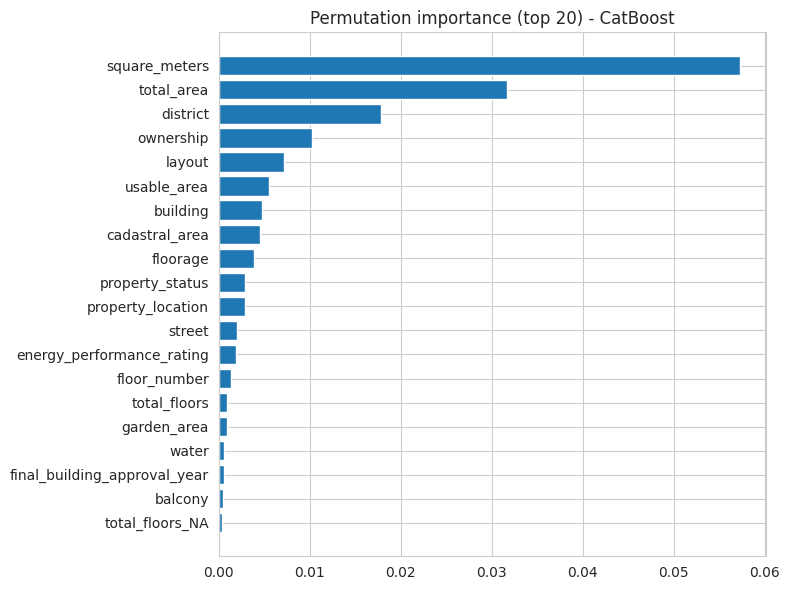

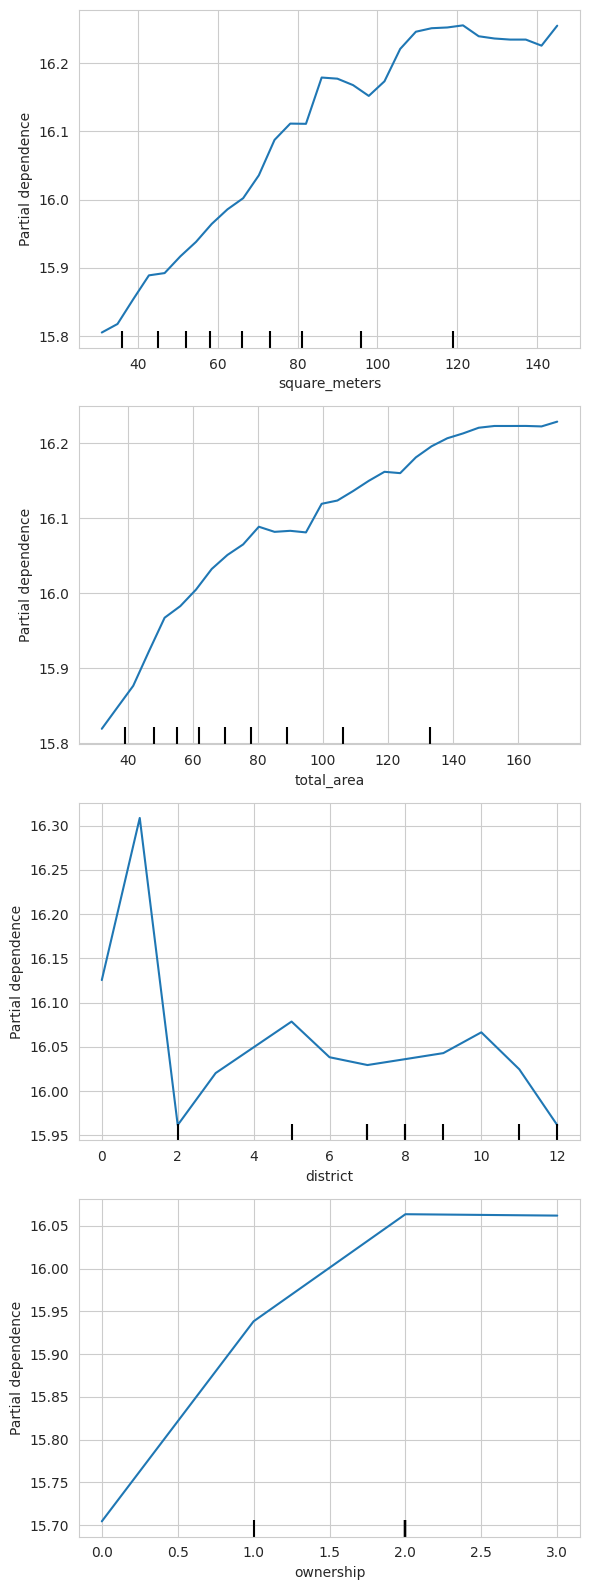

100%|===================| 1999/2000 [02:24<00:00]       

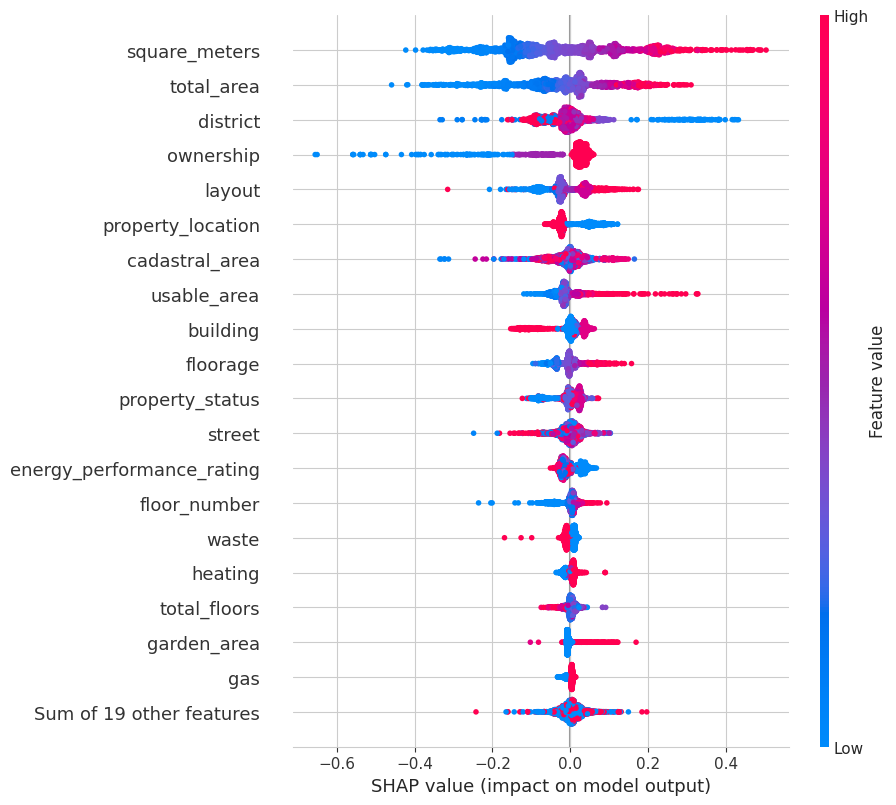

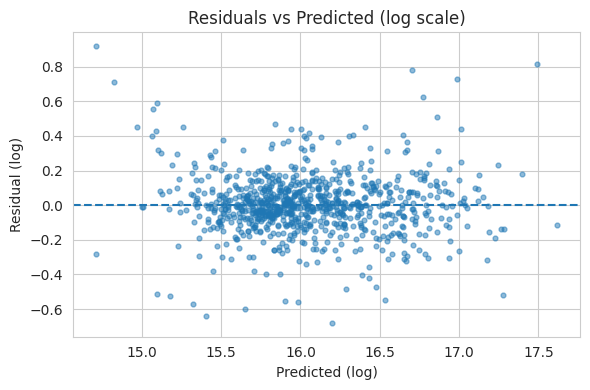

Median absolute percentage error (MAPE-ish): 0.08091969894899202


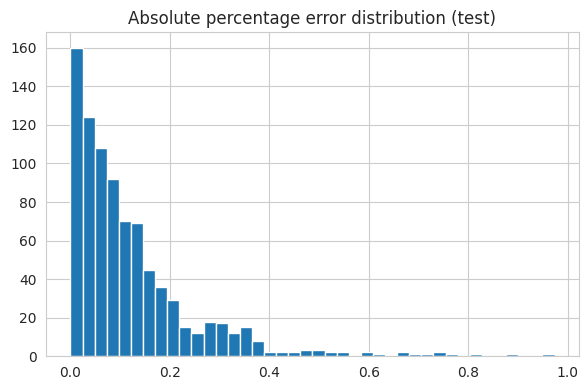

{'usable_area': 67.0, 'floorage': 64.0, 'balcony': 0.0, 'energy_performance_certificate': 0.0, 'furnished': 0.0, 'terrace': 0.0, 'cellar': 0.0, 'parking': 0.0, 'garden_area': 0.0, 'garage': 0.0, 'loggia': 0.0, 'final_building_approval_year': 2023.0, 'basin_area': 0.0, 'floor_number': 3.0, 'total_floors': 5.0, 'square_meters': 66.0, 'usable_area_NA': 0.0, 'floorage_NA': 0.0, 'final_building_approval_year_NA': 1.0, 'floor_number_NA': 0.0, 'total_floors_NA': 0.0, 'building_age': 1.0, 'total_area': 70.0, 'is_top_floor': 0.0, 'is_ground_floor': 0.0, 'building': np.int64(0), 'property_status': np.int64(3), 'ownership': np.int64(2), 'property_location': np.int64(5), 'water': np.int64(1), 'heating': np.int64(2), 'gas': np.int64(3), 'energy_performance_rating': np.int64(1), 'waste': np.int64(0), 'street': np.int64(568), 'district': np.int64(8), 'cadastral_area': np.int64(102), 'layout': np.int64(3)}
Saved artifacts to /content/drive/MyDrive/Colab Notebooks/deployable


In [ ]:
# ================================
# 8) Final test evaluation, interpretation & deployment
# ================================

import re, multiprocessing as mp
import optuna
from optuna.pruners import MedianPruner
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

from pandas.api.types import is_string_dtype, is_categorical_dtype

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import matplotlib.pyplot as plt
import shap

# ---- Config for inverse-transform of target ----
TARGET_TRANSFORM = "log"  # options: "log1p", "log", "none"

def inv_y(y):
    if TARGET_TRANSFORM == "log1p":
        return np.expm1(y)
    elif TARGET_TRANSFORM == "log":
        return np.exp(y)
    else:
        return y

# ---- Directories for artifacts/plots ----
artifact_dir = Path("/content/drive/MyDrive/Colab Notebooks/deployable")
plot_dir = artifact_dir / "plots"
artifact_dir.mkdir(parents=True, exist_ok=True)
plot_dir.mkdir(parents=True, exist_ok=True)

# Model card path
model_card_path = artifact_dir / "model_card.txt"


# ---------------------------
# A) Pick finalists
# ---------------------------
display(leaderboard_df)

best_row = leaderboard_df.iloc[0]
print("Best-by-val:", best_row["Model"], best_row["RMSE"])

top_models = leaderboard_df["Model"].tolist()
blend_name = [m for m in top_models if m.startswith("WeightedBlend(")]
stack_name = [m for m in top_models if m.startswith("Stacked(")]

tree_candidates = ["CatBoost", "XGBoost", "GradientBoosting", "LightGBM", "RandomForest"]
best_single_name = leaderboard_df[leaderboard_df["Model"].isin(tree_candidates)].iloc[0]["Model"]
print("Best single base model:", best_single_name)

# ---------------------------
# B) Refit finalists on TRAIN+VALID
# ---------------------------
X_trv_full  = pd.concat([X_train_full_s,  X_valid_full_s],  axis=0)
X_trv_red   = pd.concat([X_train_reduced_s, X_valid_reduced_s], axis=0)
y_trv       = pd.concat([y_train, y_valid], axis=0)

def get_view(name):
    return (X_trv_red, X_test_reduced_s) if use_reduced[name] else (X_trv_full, X_test_full_s)

def build_final_model(name):
    params = best_params_store.get(name, {})
    if name == "RandomForest":
        params.update({"n_jobs": -1, "random_state": SEED})
    elif name == "XGBoost":
        params.setdefault("n_jobs", -1); params.setdefault("tree_method", "hist")
        params.setdefault("verbosity", 0); params["random_state"] = SEED
    elif name == "LightGBM":
        params.setdefault("n_jobs", -1); params["random_state"] = SEED
    elif name == "CatBoost":
        params.setdefault("verbose", 0); params["random_seed"] = SEED
    return model_classes[name](**params)

# Refit best single base model
best_single_model = build_final_model(best_single_name)
X_trv, X_tst = get_view(best_single_name)
best_single_model.fit(X_trv, y_trv)

pred_tst = best_single_model.predict(X_tst)
rmse_tst = float(np.sqrt(mean_squared_error(y_test, pred_tst)))
mae_tst  = float(mean_absolute_error(y_test, pred_tst))
r2_tst   = float(r2_score(y_test, pred_tst))
print(f"[TEST] {best_single_name}: RMSE={rmse_tst:.5f} MAE={mae_tst:.5f} R2={r2_tst:.5f}")

# ---------------------------
# C) Weighted blend (optional)
# ---------------------------
K_FOR_BLEND = 3
top_tree_models = leaderboard_df[leaderboard_df["Model"].isin(tree_candidates)].head(K_FOR_BLEND)["Model"].tolist()

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_train), len(top_tree_models)))
for j, mname in enumerate(top_tree_models):
    oof_col = np.zeros(len(y_train))
    Xtr_all = X_train_reduced_s if use_reduced[mname] else X_train_full_s
    for tr_idx, va_idx in kf.split(Xtr_all, y_train):
        mdl = build_final_model(mname)
        mdl.fit(Xtr_all.iloc[tr_idx], y_train.iloc[tr_idx])
        oof_col[va_idx] = mdl.predict(Xtr_all.iloc[va_idx])
    oof_meta[:, j] = oof_col

lr = LinearRegression(fit_intercept=False)
lr.fit(oof_meta, y_train)
w = lr.coef_.astype(float)
w[w < 0] = 0.0
w = w / (w.sum() if w.sum() > 0 else len(w))
print("OOF-learned weights:", dict(zip(top_tree_models, w.round(4))))

# Predict blend on test
test_meta = []
for mname in top_tree_models:
    mdl = build_final_model(mname)
    Xm_trv, Xm_tst = get_view(mname)
    mdl.fit(Xm_trv, y_trv)
    test_meta.append(mdl.predict(Xm_tst))
test_meta = np.vstack(test_meta).T
blend_pred_test = test_meta @ w

blend_rmse_tst = float(np.sqrt(mean_squared_error(y_test, blend_pred_test)))
blend_mae_tst  = float(mean_absolute_error(y_test, blend_pred_test))
blend_r2_tst   = float(r2_score(y_test, blend_pred_test))
print(f"[TEST] WeightedBlend({', '.join(top_tree_models)}): RMSE={blend_rmse_tst:.5f} MAE={blend_mae_tst:.5f} R2={blend_r2_tst:.5f}")

# Decide final winner
winner_name = "Blend" if blend_rmse_tst <= rmse_tst else best_single_name
winner_pred_test = blend_pred_test if winner_name == "Blend" else pred_tst
print("Final winner on TEST:", winner_name)

# Save leaderboard with test scores
test_scores = pd.DataFrame([
    {"Model": best_single_name, "RMSE": rmse_tst, "MAE": mae_tst, "R2": r2_tst},
    {"Model": f"Blend({', '.join(top_tree_models)})", "RMSE": blend_rmse_tst, "MAE": blend_mae_tst, "R2": blend_r2_tst}
])
test_scores.to_csv(artifact_dir / "test_leaderboard.csv", index=False)

# ---------------------------
# D) Interpretation
# ---------------------------
interpret_name = best_single_name
interpret_model = best_single_model
X_ref = X_trv_full if not use_reduced[interpret_name] else X_trv_red

pi = permutation_importance(
    interpret_model,
    X_test_full_s if not use_reduced[interpret_name] else X_test_reduced_s,
    y_test, scoring="neg_mean_squared_error", n_repeats=10,
    random_state=SEED, n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": (X_test_full_s.columns if not use_reduced[interpret_name] else X_test_reduced_s.columns),
    "importance": pi.importances_mean,
    "std": pi.importances_std
}).sort_values("importance", ascending=False)

imp_df.to_csv(artifact_dir / "permutation_importance.csv", index=False)

# Plot top-20
topk = imp_df.head(20)
plt.figure(figsize=(8, 6))
plt.barh(topk["feature"][::-1], topk["importance"][::-1])
plt.title(f"Permutation importance (top 20) - {interpret_name}")
plt.tight_layout()
plt.savefig(plot_dir / "perm_importance.png")
plt.show()
plt.close()

# PDP
key_feats = topk["feature"].head(4).tolist()
fig, axes = plt.subplots(len(key_feats), 1, figsize=(6, 4*len(key_feats)))
if len(key_feats) == 1: axes = [axes]
for ax, feat in zip(axes, key_feats):
    PartialDependenceDisplay.from_estimator(interpret_model, X_ref, [feat], grid_resolution=30, ax=ax)
plt.tight_layout()
plt.savefig(plot_dir / "pdp.png")
plt.show()
plt.close()

# SHAP
try:
    explainer = shap.Explainer(interpret_model, X_ref)
    shap_values = explainer(X_ref.sample(min(2000, len(X_ref)), random_state=SEED))
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.savefig(plot_dir / "shap_beeswarm.png")
    plt.show()
    plt.close()
except Exception as e:
    print("SHAP failed:", e)

# ---------------------------
# E) Error analysis
# ---------------------------
yhat_log_tst = winner_pred_test
y_log_tst = y_test.values
resid_log = y_log_tst - yhat_log_tst

plt.figure(figsize=(6,4))
plt.scatter(yhat_log_tst, resid_log, s=12, alpha=0.5)
plt.axhline(0, ls="--")
plt.xlabel("Predicted (log)")
plt.ylabel("Residual (log)")
plt.title("Residuals vs Predicted (log scale)")
plt.tight_layout()
plt.savefig(plot_dir / "residuals_log.png")
plt.show()
plt.close()

y_price_tst    = inv_y(y_log_tst)
yhat_price_tst = inv_y(yhat_log_tst)
abs_pct_err = np.abs(yhat_price_tst - y_price_tst) / np.clip(y_price_tst, 1e-6, None)

print("Median absolute percentage error (MAPE-ish):", float(np.median(abs_pct_err)))

plt.figure(figsize=(6,4))
plt.hist(abs_pct_err, bins=40)
plt.title("Absolute percentage error distribution (test)")
plt.tight_layout()
plt.savefig(plot_dir / "error_hist.png")
plt.show()
plt.close()

# ---------------------------
# F) Deployment wrapper
# ---------------------------

feature_defaults = {}
for col in X_train_full_s.columns:
    if col in label_encoders:  # categorical
        feature_defaults[col] = X_train_full_s[col].mode()[0]
    else:  # numeric
        feature_defaults[col] = X_train_full_s[col].median()

print(feature_defaults)
# Save preprocessing artifacts

joblib.dump({
    "sanit_map": sanit_map,
    "label_encoders": label_encoders,
    "reduced_feature_names": reduced_feature_names,
    "target_transform": TARGET_TRANSFORM,
    "feature_defaults": feature_defaults,   # <--- new
}, artifact_dir / "preprocessing.joblib")

if winner_name == "Blend":
    base_fitted = {}
    for mname in top_tree_models:
        m = build_final_model(mname)
        Xm_trv, _ = get_view(mname)
        m.fit(Xm_trv, y_trv)
        base_fitted[mname] = m
    joblib.dump({"weights": w, "base_models": base_fitted, "order": top_tree_models},
                artifact_dir / "model.joblib")
else:
    joblib.dump(best_single_model, artifact_dir / "model.joblib")

print("Saved artifacts to", artifact_dir.resolve())

def load_artifacts():
    prep = joblib.load(artifact_dir / "preprocessing.joblib")
    model_obj = joblib.load(artifact_dir / "model.joblib")
    return prep, model_obj

def sanitize_columns(df, sanit_map):
    missing = set(sanit_map.keys()) - set(df.columns)
    for m in missing:
        df[m] = np.nan
    return df.rename(columns=sanit_map)

def apply_label_encoders(df, label_encoders):
    for c, le in label_encoders.items():
        if c in df.columns:
            df[c] = le.transform(df[c].astype("string").fillna("NA_LE"))
    return df

def predict_price(df_raw: pd.DataFrame):
    prep, model_obj = load_artifacts()
    sanit_map = prep["sanit_map"]
    label_encoders = prep["label_encoders"]
    tgt = prep["target_transform"]

    df_s = sanitize_columns(df_raw.copy(), sanit_map)
    df_s = apply_label_encoders(df_s, label_encoders)

    def inv_y_local(y):
        if tgt == "log1p": return np.expm1(y)
        if tgt == "log": return np.exp(y)
        return y

    if winner_name == "Blend":
        order = model_obj["order"]
        weights = model_obj["weights"]
        base_models = model_obj["base_models"]
        preds = []
        for mname in order:
            if use_reduced[mname]:
                cols = reduced_feature_names
                preds.append(base_models[mname].predict(df_s[cols]))
            else:
                preds.append(base_models[mname].predict(df_s))
        yhat_log = np.vstack(preds).T @ weights
    else:
        yhat_log = model_obj.predict(df_s if not use_reduced[winner_name] else df_s[reduced_feature_names])

    return inv_y_local(yhat_log)


In [ ]:
# ================================
# G) Generate Model Card
# ================================
from datetime import datetime
import platform
import getpass

model_card_path = artifact_dir / "model_card.txt"

with open(model_card_path, "w") as f:
    f.write("# Model Card\n\n")
    f.write(f"**Project**: Housing Price Prediction\n")
    f.write(f"**Author**: {getpass.getuser()}\n")
    f.write(f"**Date**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"**Environment**: Python {platform.python_version()}\n\n")

    f.write("## Data\n")
    f.write("- Source: [your dataset name or link]\n")
    f.write(f"- Train size: {len(X_train_full_s)} rows\n")
    f.write(f"- Valid size: {len(X_valid_full_s)} rows\n")
    f.write(f"- Test size: {len(X_test_full_s)} rows\n")
    f.write(f"- Target transform: {TARGET_TRANSFORM}\n\n")

    f.write("## Model\n")
    f.write(f"- Final winner: {winner_name}\n")
    if winner_name == "Blend":
        f.write(f"- Blend base models: {', '.join(top_tree_models)}\n")
        f.write(f"- Weights: {dict(zip(top_tree_models, w.round(4)))}\n")
    else:
        f.write(f"- Base model: {best_single_name}\n")
    f.write("\n")

    f.write("## Performance\n")
    f.write("On **test set**:\n")
    f.write(f"- RMSE: {blend_rmse_tst if winner_name=='Blend' else rmse_tst:.5f}\n")
    f.write(f"- MAE: {blend_mae_tst if winner_name=='Blend' else mae_tst:.5f}\n")
    f.write(f"- R²: {blend_r2_tst if winner_name=='Blend' else r2_tst:.5f}\n")
    f.write(f"- Median absolute % error: {float(np.median(abs_pct_err)):.5f}\n\n")

    f.write("## Interpretation\n")
    f.write(f"- Top features: {', '.join(imp_df.head(5)['feature'].tolist())}\n")
    f.write("- See `plots/` for permutation importance, PDP, SHAP plots.\n\n")

    f.write("## Limitations\n")
    f.write("- May not generalize to regions/markets not present in training data.\n")
    f.write("- Sensitive to feature encoding and target transformation.\n\n")

    f.write("## Usage\n")
    f.write("Load artifacts with `joblib.load()` from `deployable/`.\n")
    f.write("Use `predict_price(df)` function to get predictions.\n")
    f.write("- Input: raw dataframe with same schema as training data.\n")
    f.write("- Output: predicted housing price (float).\n")

print("Model card saved at:", model_card_path.resolve())


Model card saved at: /content/drive/MyDrive/Colab Notebooks/deployable/model_card.txt


In [ ]:
prep = joblib.load(artifact_dir / "preprocessing.joblib")

In [ ]:
prep2 = joblib.load(artifact_dir / "model.joblib")
prep2

{'weights': array([0.53363053, 0.26335171, 0.20301776]),
 'base_models': {'CatBoost': <catboost.core.CatBoostRegressor at 0x7b1c0ddf24e0>,
  'GradientBoosting': GradientBoostingRegressor(learning_rate=0.042079916258140254, max_depth=5,
                            n_estimators=700, subsample=0.7109286599435136),
  'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.6826526703574488, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.12120003434457666,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, mo

In [ ]:
prep

{'sanit_map': {'usable_area': 'usable_area',
  'floorage': 'floorage',
  'balcony': 'balcony',
  'energy_performance_certificate': 'energy_performance_certificate',
  'furnished': 'furnished',
  'terrace': 'terrace',
  'cellar': 'cellar',
  'parking': 'parking',
  'garden_area': 'garden_area',
  'garage': 'garage',
  'loggia': 'loggia',
  'final_building_approval_year': 'final_building_approval_year',
  'basin_area': 'basin_area',
  'floor_number': 'floor_number',
  'total_floors': 'total_floors',
  'square_meters': 'square_meters',
  'usable_area_NA': 'usable_area_NA',
  'floorage_NA': 'floorage_NA',
  'final_building_approval_year_NA': 'final_building_approval_year_NA',
  'floor_number_NA': 'floor_number_NA',
  'total_floors_NA': 'total_floors_NA',
  'building_age': 'building_age',
  'total_area': 'total_area',
  'is_top_floor': 'is_top_floor',
  'is_ground_floor': 'is_ground_floor',
  'building': 'building',
  'property_status': 'property_status',
  'ownership': 'ownership',
  'prop

In [ ]:
# ================================
# 8) Final test evaluation, interpretation & deployment
# ================================
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import matplotlib.pyplot as plt

# ---- Config for inverse-transform of target ----
TARGET_TRANSFORM = "log"  # options: "log1p", "log", "none"

def inv_y(y):
    if TARGET_TRANSFORM == "log1p":
        return np.expm1(y)
    elif TARGET_TRANSFORM == "log":
        return np.exp(y)
    else:
        return y

# ---------------------------
# A) Pick finalists
# ---------------------------
# you already have leaderboard_df
display(leaderboard_df)

# Best single model (by validation RMSE)
best_row = leaderboard_df.iloc[0]
print("Best-by-val:", best_row["Model"], best_row["RMSE"])

# We’ll keep: top single-tree model + (optionally) the WeightedBlend if it won.
top_models = leaderboard_df["Model"].tolist()
blend_name = [m for m in top_models if m.startswith("WeightedBlend(")]
stack_name = [m for m in top_models if m.startswith("Stacked(")]

# Find best *single* base model among CatBoost/XGB/GB/LGBM/RF
tree_candidates = ["CatBoost", "XGBoost", "GradientBoosting", "LightGBM", "RandomForest"]
best_single_name = leaderboard_df[leaderboard_df["Model"].isin(tree_candidates)].iloc[0]["Model"]
print("Best single base model:", best_single_name)

# ---------------------------
# B) Refit finalists on TRAIN+VALID (no peeking at test)
# ---------------------------
X_trv_full  = pd.concat([X_train_full_s,  X_valid_full_s],  axis=0)
X_trv_red   = pd.concat([X_train_reduced_s, X_valid_reduced_s], axis=0)
y_trv       = pd.concat([y_train, y_valid], axis=0)

def get_view(name):
    return (X_trv_red, X_test_reduced_s) if use_reduced[name] else (X_trv_full, X_test_full_s)

def build_final_model(name):
    params = best_params_store.get(name, {})
    # enforce safe speed flags
    if name == "RandomForest":
        params.update({"n_jobs": -1, "random_state": SEED})
    elif name == "XGBoost":
        params.setdefault("n_jobs", -1); params.setdefault("tree_method", "hist")
        params.setdefault("verbosity", 0); params["random_state"] = SEED
    elif name == "LightGBM":
        params.setdefault("n_jobs", -1); params["random_state"] = SEED
    elif name == "CatBoost":
        params.setdefault("verbose", 0); params["random_seed"] = SEED
    return model_classes[name](**params)

# 1) Refit best single base model on train+valid
best_single_model = build_final_model(best_single_name)
X_trv, X_tst = get_view(best_single_name)
best_single_model.fit(X_trv, y_trv)

# Evaluate on test (single model)
pred_tst = best_single_model.predict(X_tst)
rmse_tst = float(np.sqrt(mean_squared_error(y_test, pred_tst)))
mae_tst  = float(mean_absolute_error(y_test, pred_tst))
r2_tst   = float(r2_score(y_test, pred_tst))
print(f"[TEST] {best_single_name}: RMSE={rmse_tst:.5f} MAE={mae_tst:.5f} R2={r2_tst:.5f}")

# ---------------------------
# C) (Optional) Proper blend weights via OOF on TRAIN (no val labels)
# ---------------------------
# We’ll compute OOF predictions for top K tree models, learn non-negative weights on OOF,
# then refit base models on train+valid and score the blend on test.
K_FOR_BLEND = 3
top_tree_models = leaderboard_df[leaderboard_df["Model"].isin(tree_candidates)].head(K_FOR_BLEND)["Model"].tolist()

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
# Prepare OOF matrices
oof_meta = np.zeros((len(y_train), len(top_tree_models)))
for j, mname in enumerate(top_tree_models):
    oof_col = np.zeros(len(y_train))
    Xtr_all = X_train_reduced_s if use_reduced[mname] else X_train_full_s
    for fold_id, (tr_idx, va_idx) in enumerate(kf.split(Xtr_all, y_train)):
        Xm_tr, ym_tr = Xtr_all.iloc[tr_idx], y_train.iloc[tr_idx]
        Xm_va        = Xtr_all.iloc[va_idx]

        mdl = build_final_model(mname)
        mdl.fit(Xm_tr, ym_tr)
        oof_col[va_idx] = mdl.predict(Xm_va)
    oof_meta[:, j] = oof_col

# Fit non-negative weights on OOF
lr = LinearRegression(fit_intercept=False)
lr.fit(oof_meta, y_train)
w = lr.coef_.astype(float)
w[w < 0] = 0.0
w = w / (w.sum() if w.sum() > 0 else len(w))
print("OOF-learned non-neg weights:", dict(zip(top_tree_models, w.round(4))))

# Refit the same base models on train+valid, predict test, then blend
test_meta = []
for mname in top_tree_models:
    mdl = build_final_model(mname)
    Xm_trv, Xm_tst = get_view(mname)
    mdl.fit(Xm_trv, y_trv)
    test_meta.append(mdl.predict(Xm_tst))
test_meta = np.vstack(test_meta).T
blend_pred_test = test_meta @ w

blend_rmse_tst = float(np.sqrt(mean_squared_error(y_test, blend_pred_test)))
blend_mae_tst  = float(mean_absolute_error(y_test, blend_pred_test))
blend_r2_tst   = float(r2_score(y_test, blend_pred_test))
print(f"[TEST] WeightedBlend({', '.join(top_tree_models)}): RMSE={blend_rmse_tst:.5f} MAE={blend_mae_tst:.5f} R2={blend_r2_tst:.5f}")

# Keep whichever is better on TEST for the remainder of the report
winner_name = "Blend" if blend_rmse_tst <= rmse_tst else best_single_name
print("Final winner on TEST:", winner_name)
winner_pred_test = blend_pred_test if winner_name == "Blend" else pred_tst


,Model,Best_Params,RMSE,MAE,R2,CV_RMSE_MEAN,CV_RMSE_STD
0,"WeightedBlend(CatBoost, GradientBoosting, XGBo...","{'weights': [0.708104717748742, 0.283015244807...",0.187556,0.127715,0.851107,NaN,NaN
1,CatBoost,"{'iterations': 1200, 'learning_rate': 0.060687...",0.188171,0.128420,0.850129,0.178879,0.006525
2,GradientBoosting,"{'n_estimators': 600, 'learning_rate': 0.03613...",0.191191,0.129946,0.845281,0.185151,0.008967
3,"Stacked(CatBoost, GradientBoosting, XGBoost)",stack_cv3,0.194221,0.131764,0.840338,NaN,NaN
4,XGBoost,"{'n_estimators': 400, 'learning_rate': 0.17815...",0.198882,0.136435,0.832582,0.186146,0.007990
5,LightGBM,"{'n_estimators': 500, 'learning_rate': 0.08041...",0.199283,0.137709,0.831906,0.189250,0.005535
6,RandomForest,"{'n_estimators': 200, 'max_depth': 17, 'min_sa...",0.213135,0.143607,0.807726,0.211548,0.009035
7,Lasso,{'alpha': 1.0207584060126808e-05},0.233480,0.163116,0.769267,0.229684,0.007732
8,Ridge,{'alpha': 0.07448852207832186},0.233481,0.163124,0.769265,0.229676,0.007735
9,ElasticNet,"{'alpha': 2.1972407520456842e-05, 'l1_ratio': ...",0.233482,0.163131,0.769263,0.229675,0.007731


Best-by-val: WeightedBlend(CatBoost, GradientBoosting, XGBoost) 0.1875563806466656
Best single base model: CatBoost


CatBoostError: features data: pandas.DataFrame column 'building' has dtype 'category' but is not in  cat_features list

In [ ]:
# ---------------------------
# D) Interpretation
# ---------------------------
from sklearn.inspection import PartialDependenceDisplay

# Choose a fitted model to interpret:
interpret_name = best_single_name
interpret_model = best_single_model
X_ref = X_trv_full if not use_reduced[interpret_name] else X_trv_red  # model was trained on X_trv/X_trv_red

# 1) Permutation Importance (on validation-like data; here use TEST for “final-look” or a held-out VALID)
pi = permutation_importance(interpret_model, X_test_full_s if not use_reduced[interpret_name] else X_test_reduced_s,
                            y_test, scoring="neg_mean_squared_error", n_repeats=10, random_state=SEED, n_jobs=-1)

imp_df = pd.DataFrame({
    "feature": (X_test_full_s.columns if not use_reduced[interpret_name] else X_test_reduced_s.columns),
    "importance": pi.importances_mean,
    "std": pi.importances_std
}).sort_values("importance", ascending=False)

display(imp_df.head(25))

# Plot top-20
topk = imp_df.head(20)
plt.figure(figsize=(8, 6))
plt.barh(topk["feature"][::-1], topk["importance"][::-1])
plt.title(f"Permutation importance (top 20) - {interpret_name}")
plt.tight_layout()
plt.show()

# 2) Partial Dependence for a couple of key features (change to your actual important features)
key_feats = topk["feature"].head(4).tolist()
fig, axes = plt.subplots(len(key_feats), 1, figsize=(6, 4*len(key_feats)))
if len(key_feats) == 1:
    axes = [axes]
for ax, feat in zip(axes, key_feats):
    PartialDependenceDisplay.from_estimator(interpret_model,
                                            X_ref, [feat],
                                            grid_resolution=30, ax=ax)
plt.tight_layout()
plt.show()


In [ ]:
# SHAP (optional)
# !pip install shap
import shap
# Enable shap’s tree explainer for tree models
try:
    explainer = shap.Explainer(interpret_model, X_ref)
    shap_values = explainer(X_ref.sample(min(2000, len(X_ref)), random_state=SEED))
    shap.plots.beeswarm(shap_values, max_display=20)
except Exception as e:
    print("SHAP not available or failed:", e)


In [ ]:
# ---------------------------
# E) Error analysis
# ---------------------------
# Use the final winner and TEST set
if winner_name == "Blend":
    yhat_log_tst = winner_pred_test
else:
    yhat_log_tst = pred_tst

y_log_tst = y_test.values

# 1) Residuals on log scale
resid_log = y_log_tst - yhat_log_tst

plt.figure(figsize=(6,4))
plt.scatter(yhat_log_tst, resid_log, s=12, alpha=0.5)
plt.axhline(0, ls="--")
plt.xlabel("Predicted (log)")
plt.ylabel("Residual (log)")
plt.title("Residuals vs Predicted (log scale)")
plt.tight_layout()
plt.show()

# 2) Translate to original price scale
y_price_tst    = inv_y(y_log_tst)
yhat_price_tst = inv_y(yhat_log_tst)
abs_pct_err = np.abs(yhat_price_tst - y_price_tst) / np.clip(y_price_tst, 1e-6, None)

print("Median absolute percentage error (MAPE-ish):", float(np.median(abs_pct_err)))

plt.figure(figsize=(6,4))
plt.hist(abs_pct_err, bins=40)
plt.title("Absolute percentage error distribution (test)")
plt.tight_layout()
plt.show()

# 3) Segment error by a key feature (e.g., number_of_rooms) if present
key = "rooms"  # change to a real column if you have it
if key in (X_test_full_s.columns if winner_name != "Blend" or not any(use_reduced[m] for m in tree_candidates) else X_test_reduced_s.columns):
    seg = pd.DataFrame({"rooms": X_test_full_s[key] if key in X_test_full_s.columns else X_test_reduced_s[key],
                        "ape": abs_pct_err})
    print(seg.groupby("rooms")["ape"].mean().sort_index())


In [ ]:
# ---------------------------
# F) Deployment wrapper
# ---------------------------
import types

# We assume you still have:
#  - sanit_map (dict), label_encoders (dict of LabelEncoder), reduced_feature_names (list)
#  - winner_name, and a fitted winner model: best_single_model or the blend weights+base models

artifact_dir = Path("deployable")
artifact_dir.mkdir(exist_ok=True)

feature_defaults = {}
for col in X_train.columns:
    if col in label_encoders:  # categorical
        feature_defaults[col] = X_train[col].mode()[0]
    else:  # numeric
        feature_defaults[col] = X_train[col].median()

# Save preprocessing artifacts

joblib.dump({
    "sanit_map": sanit_map,
    "label_encoders": label_encoders,
    "reduced_feature_names": reduced_feature_names,
    "target_transform": TARGET_TRANSFORM,
    "feature_defaults": feature_defaults,   # <--- new
}, artifact_dir / "preprocessing.joblib")


# Save model artifact(s)
if winner_name == "Blend":
    # Save blend: weights + top base models refit on TRAIN+VALID
    base_fitted = {}
    for mname in top_tree_models:
        m = build_final_model(mname)
        Xm_trv, _ = get_view(mname)
        m.fit(Xm_trv, y_trv)
        base_fitted[mname] = m
    joblib.dump({"weights": w, "base_models": base_fitted, "order": top_tree_models},
                artifact_dir / "model.joblib")
else:
    joblib.dump(best_single_model, artifact_dir / "model.joblib")

print("Saved artifacts to", artifact_dir.resolve())

# Inference function (simulate “production”)
def load_artifacts():
    prep = joblib.load(artifact_dir / "preprocessing.joblib")
    model_obj = joblib.load(artifact_dir / "model.joblib")
    return prep, model_obj

def sanitize_columns(df, sanit_map):
    # apply exact same renaming
    missing = set(sanit_map.keys()) - set(df.columns)
    if missing:
        # soft fail: add missing as NA
        for m in missing:
            df[m] = np.nan
    return df.rename(columns=sanit_map)

def apply_label_encoders(df, label_encoders):
    for c, le in label_encoders.items():
        if c in df.columns:
            df[c] = le.transform(df[c].astype("string").fillna("NA_LE"))
    return df

def predict_price(df_raw: pd.DataFrame):
    prep, model_obj = load_artifacts()
    sanit_map = prep["sanit_map"]
    label_encoders = prep["label_encoders"]
    tgt = prep["target_transform"]

    df_s = sanitize_columns(df_raw.copy(), sanit_map)
    df_s = apply_label_encoders(df_s, label_encoders)

    def inv_y_local(y):
        if tgt == "log1p": return np.expm1(y)
        if tgt == "log": return np.exp(y)
        return y

    if winner_name == "Blend":
        order = model_obj["order"]
        weights = model_obj["weights"]
        base_models = model_obj["base_models"]
        preds = []
        for mname in order:
            if use_reduced[mname]:
                cols = reduced_feature_names
                preds.append(base_models[mname].predict(df_s[cols]))
            else:
                preds.append(base_models[mname].predict(df_s))
        meta = np.vstack(preds).T
        yhat_log = meta @ weights
    else:
        # best_single_model saved
        yhat_log = model_obj.predict(df_s if not use_reduced[winner_name] else df_s[reduced_feature_names])

    return inv_y_local(yhat_log)

# Example:
# incoming = pd.DataFrame({...})
# price_pred = predict_price(incoming)


In [ ]:
# cat transormation for tree models was only looking for 'object' type but categorical vars are 'category' type, therefore errors
# Step 7 — Fast tuning (CV), stacking, weighted blending & saving

import os, re, multiprocessing as mp
import optuna
from optuna.pruners import MedianPruner
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)

# ======== SPEED KNOBS ========
N_TRIALS_TREES   = 60   # trials for tree models
N_TRIALS_LINEAR  = 40   # trials for linear models
CV_TUNE_SPLITS   = 3    # fast CV during tuning
CV_REPORT_SPLITS = 5    # more stable CV for final reporting
TOP_N_FOR_STACK  = 3    # base models in stack
OPTUNA_WORKERS   = max(1, mp.cpu_count() // 2)  # parallel trials
# =============================

# ---------------------------
# OUTPUT FOLDERS
# ---------------------------
save_dir = Path("models")
save_dir.mkdir(exist_ok=True)
leaderboard_path = save_dir / "leaderboard.csv"

# ---------------------------
# Column sanitization
# ---------------------------
def build_sanitization_map(cols):
    mapping, used = {}, {}
    for i, col in enumerate(cols):
        base = re.sub(r"\W+", "_", str(col)).strip("_") or f"col_{i}"
        name = base
        k = 1
        while name in used:
            name = f"{base}_{k}"
            k += 1
        used[name] = True
        mapping[col] = name
    return mapping

def apply_map_to_df(df, mapping):
    return df.rename(columns=mapping)

# assume X_train_full / X_valid_full / X_test_full and X_train_reduced / ... exist
sanit_map = build_sanitization_map(list(X_train_full.columns))

X_train_full_s   = apply_map_to_df(X_train_full, sanit_map)
X_valid_full_s   = apply_map_to_df(X_valid_full, sanit_map)
X_test_full_s    = apply_map_to_df(X_test_full, sanit_map)

X_train_reduced_s = apply_map_to_df(X_train_reduced, sanit_map)
X_valid_reduced_s = apply_map_to_df(X_valid_reduced, sanit_map)
X_test_reduced_s  = apply_map_to_df(X_test_reduced, sanit_map)

reduced_feature_names = list(X_train_reduced_s.columns)

# ---------------------------
# High-cardinality categoricals (for non-CatBoost)
# ---------------------------
categorical_cols = [c for c in X_train_full_s.columns if X_train_full_s[c].dtype == 'object']
label_encoders = {}
if categorical_cols:
    for col in categorical_cols:
        le = LabelEncoder()
        all_vals = pd.concat([X_train_full_s[col], X_valid_full_s[col], X_test_full_s[col]], axis=0).astype(str)
        le.fit(all_vals)
        for df in [X_train_full_s, X_valid_full_s, X_test_full_s,
                   X_train_reduced_s, X_valid_reduced_s, X_test_reduced_s]:
            if col in df.columns:
                df[col] = le.transform(df[col].astype(str))
        label_encoders[col] = le

# ---------------------------
# Model registry
# ---------------------------
model_classes = {
    "LinearRegression": LinearRegression,
    "Ridge": Ridge,
    "Lasso": Lasso,
    "ElasticNet": ElasticNet,
    "RandomForest": RandomForestRegressor,
    "GradientBoosting": GradientBoostingRegressor,
    "XGBoost": XGBRegressor,
    "LightGBM": LGBMRegressor,
    "CatBoost": CatBoostRegressor
}

use_reduced = {
    "LinearRegression": True,
    "Ridge": True,
    "Lasso": True,
    "ElasticNet": True,
    "RandomForest": False,
    "GradientBoosting": False,
    "XGBoost": False,
    "LightGBM": False,
    "CatBoost": False
}

# ---------------------------
# Optuna objective (fast CV)
# ---------------------------
def objective(trial, model_name, X, y):
    params = {}
    if model_name == "LinearRegression":
        pass  # no params
    elif model_name == "Ridge":
        params["alpha"] = trial.suggest_float("alpha", 1e-3, 10, log=True)
        params["random_state"] = SEED
    elif model_name == "Lasso":
        params["alpha"] = trial.suggest_float("alpha", 1e-5, 1.0, log=True)
        params["random_state"] = SEED
        params["max_iter"] = 2000
    elif model_name == "ElasticNet":
        params["alpha"] = trial.suggest_float("alpha", 1e-5, 1.0, log=True)
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
        params["random_state"] = SEED
        params["max_iter"] = 2000
    elif model_name == "RandomForest":
        params["n_estimators"] = trial.suggest_int("n_estimators", 200, 800, step=100)
        params["max_depth"] = trial.suggest_int("max_depth", 5, 28)
        params["min_samples_split"] = trial.suggest_int("min_samples_split", 2, 10)
        params["min_samples_leaf"] = trial.suggest_int("min_samples_leaf", 1, 6)
        params["n_jobs"] = -1
        params["random_state"] = SEED
    elif model_name == "GradientBoosting":
        params["n_estimators"] = trial.suggest_int("n_estimators", 100, 800, step=100)
        params["learning_rate"] = trial.suggest_float("learning_rate", 0.01, 0.25)
        params["max_depth"] = trial.suggest_int("max_depth", 2, 6)
        params["subsample"] = trial.suggest_float("subsample", 0.6, 1.0)
        params["random_state"] = SEED
    elif model_name == "XGBoost":
        params.update({
            "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.25),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
            "n_jobs": -1,
            "verbosity": 0,
            "random_state": SEED,
            "tree_method": "hist",
        })
    elif model_name == "LightGBM":
        params.update({
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "num_leaves": trial.suggest_int("num_leaves", 31, 255),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.7, 1.0),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
            "n_jobs": -1,
            "random_state": SEED,
        })
    elif model_name == "CatBoost":
        params.update({
            "iterations": trial.suggest_int("iterations", 300, 1200, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "depth": trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "loss_function": "RMSE",
            "verbose": 0,
            "random_seed": SEED
        })

    Model = model_classes[model_name](**params)
    cv_fast = KFold(n_splits=CV_TUNE_SPLITS, shuffle=True, random_state=SEED)
    scores = cross_val_score(Model, X, y, scoring="neg_mean_squared_error", cv=cv_fast, n_jobs=-1)
    rmse_mean = np.mean(np.sqrt(-scores))
    return rmse_mean

# ---------------------------
# Main tuning + fit
# ---------------------------
results = []
best_params_store = {}
cv_report = KFold(n_splits=CV_REPORT_SPLITS, shuffle=True, random_state=SEED)

for model_name in model_classes.keys():
    print(f"\n🔍 Tuning {model_name} ...")

    Xtr = X_train_reduced_s if use_reduced[model_name] else X_train_full_s
    Xval = X_valid_reduced_s if use_reduced[model_name] else X_valid_full_s

    n_trials = N_TRIALS_LINEAR if use_reduced[model_name] else N_TRIALS_TREES
    study = optuna.create_study(direction="minimize", pruner=MedianPruner(n_warmup_steps=5))
    study.optimize(lambda t: objective(t, model_name, Xtr, y_train),
                   n_trials=n_trials, n_jobs=OPTUNA_WORKERS, show_progress_bar=False)

    best_params = study.best_params
    best_params_store[model_name] = best_params

    # Ensure speed flags on final model too
    if model_name == "RandomForest":
        best_params["n_jobs"] = -1
        best_params["random_state"] = SEED
    elif model_name == "XGBoost":
        best_params.setdefault("n_jobs", -1)
        best_params.setdefault("tree_method", "hist")
        best_params.setdefault("verbosity", 0)
        best_params["random_state"] = SEED
    elif model_name == "LightGBM":
        best_params.setdefault("n_jobs", -1)
        best_params["random_state"] = SEED
    elif model_name == "CatBoost":
        best_params.setdefault("verbose", 0)
        best_params["random_seed"] = SEED

    final_model = model_classes[model_name](**best_params)
    final_model.fit(Xtr, y_train)

    # Evaluate on validation
    val_preds = final_model.predict(Xval)
    rmse = float(np.sqrt(mean_squared_error(y_valid, val_preds)))
    mae  = float(mean_absolute_error(y_valid, val_preds))
    r2   = float(r2_score(y_valid, val_preds))

    # Report CV once (5-fold) for stability
    cv_scores = cross_val_score(clone(final_model), Xtr, y_train,
                                scoring="neg_mean_squared_error", cv=cv_report, n_jobs=-1)
    cv_rmse_mean = float(np.mean(np.sqrt(-cv_scores)))
    cv_rmse_std  = float(np.std(np.sqrt(-cv_scores)))

    joblib.dump(final_model, save_dir / f"{model_name}.pkl")

    results.append({
        "Model": model_name,
        "Best_Params": best_params,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "CV_RMSE_MEAN": cv_rmse_mean,
        "CV_RMSE_STD": cv_rmse_std
    })

# ---------------------------
# Weighted blending (fast, better than inverse-RMSE)
# ---------------------------
df_results = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)
top_models = df_results.head(TOP_N_FOR_STACK)["Model"].tolist()

# Build validation meta-matrix
val_meta = []
for m in top_models:
    model = joblib.load(save_dir / f"{m}.pkl")
    Xval = X_valid_reduced_s if use_reduced[m] else X_valid_full_s
    val_meta.append(model.predict(Xval))
val_meta = np.vstack(val_meta).T  # shape (n_val, topN)

# Linear regression blend (non-negative + normalize)
# Fit without intercept; clip negatives; renormalize to sum=1
lin_blender = LinearRegression(fit_intercept=False)
lin_blender.fit(val_meta, y_valid)
w = lin_blender.coef_.copy()
w[w < 0] = 0.0
if w.sum() == 0:
    w = np.ones_like(w) / len(w)
else:
    w = w / w.sum()

blend_preds = val_meta @ w
blend_rmse = float(np.sqrt(mean_squared_error(y_valid, blend_preds)))
blend_mae  = float(mean_absolute_error(y_valid, blend_preds))
blend_r2   = float(r2_score(y_valid, blend_preds))

results.append({
    "Model": f"WeightedBlend({', '.join(top_models)})",
    "Best_Params": {"weights": w.tolist()},
    "RMSE": blend_rmse,
    "MAE": blend_mae,
    "R2": blend_r2
})

# ---------------------------
# Stacking (trimmed for speed)
# ---------------------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

stack_estimators = []
for m in top_models:
    params = best_params_store.get(m, {})
    Base = model_classes[m](**params)
    if use_reduced[m]:
        # select reduced columns via a FunctionTransformer (fast, no copy)
        feats = reduced_feature_names
        selector = FunctionTransformer(lambda df, cols=feats: df[cols], validate=False)
        pipe = Pipeline([("select", selector), ("est", Base)])
        stack_estimators.append((m, pipe))
    else:
        stack_estimators.append((m, Base))

meta = CatBoostRegressor(random_seed=SEED, verbose=0, iterations=500, depth=6, learning_rate=0.05)
stacker = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=meta,
    passthrough=False,    # keep it False for speed; True widens meta features
    cv=3,                 # faster than default 5
    n_jobs=-1
)

# Fit on FULL train using FULL features (stacking will call selectors for linear)
stacker.fit(X_train_full_s, y_train)
joblib.dump(stacker, save_dir / "stacked_model.pkl")

stack_preds = stacker.predict(X_valid_full_s)
stack_rmse  = float(np.sqrt(mean_squared_error(y_valid, stack_preds)))
stack_mae   = float(mean_absolute_error(y_valid, stack_preds))
stack_r2    = float(r2_score(y_valid, stack_preds))

results.append({
    "Model": f"Stacked({', '.join(top_models)})",
    "Best_Params": "stack_cv3",
    "RMSE": stack_rmse,
    "MAE": stack_mae,
    "R2": stack_r2
})

# ---------------------------
# Save leaderboard
# ---------------------------
leaderboard_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)
leaderboard_df.to_csv(leaderboard_path, index=False)

print("\n🏆 Leaderboard:")
print(leaderboard_df)
print(f"✅ Leaderboard saved to {leaderboard_path}")
print(f"✅ Models saved in {save_dir}")


[I 2025-08-15 21:45:31,529] A new study created in memory with name: no-name-7428c95b-a7bf-4841-a5d1-344705b44b1b
[I 2025-08-15 21:45:31,614] Trial 0 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-08-15 21:45:31,678] Trial 1 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.



🔍 Tuning LinearRegression ...


[I 2025-08-15 21:45:31,736] Trial 2 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-08-15 21:45:31,838] Trial 3 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-08-15 21:45:31,887] Trial 4 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-08-15 21:45:31,927] Trial 5 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-08-15 21:45:31,959] Trial 6 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-08-15 21:45:31,990] Trial 7 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950403039.
[I 2025-08-15 21:45:32,019] Trial 8 finished with value: 0.2300079950403039 and parameters: {}. Best is trial 0 with value: 0.2300079950


🔍 Tuning Ridge ...


[I 2025-08-15 21:45:33,373] Trial 5 finished with value: 0.2313441288441139 and parameters: {'alpha': 9.804741531121781}. Best is trial 3 with value: 0.23000661572010794.
[I 2025-08-15 21:45:33,412] Trial 6 finished with value: 0.23001053384089934 and parameters: {'alpha': 0.1799674862219366}. Best is trial 3 with value: 0.23000661572010794.
[I 2025-08-15 21:45:33,441] Trial 7 finished with value: 0.23000874076383546 and parameters: {'alpha': 0.16638012121440998}. Best is trial 3 with value: 0.23000661572010794.
[I 2025-08-15 21:45:33,477] Trial 8 finished with value: 0.23000758747249325 and parameters: {'alpha': 0.0025847279031664754}. Best is trial 3 with value: 0.23000661572010794.
[I 2025-08-15 21:45:33,507] Trial 9 finished with value: 0.2303538787170236 and parameters: {'alpha': 1.5951852053080982}. Best is trial 3 with value: 0.23000661572010794.
[I 2025-08-15 21:45:33,545] Trial 10 finished with value: 0.2300041516563124 and parameters: {'alpha': 0.03171851153665687}. Best is t

...

[I 2025-08-15 21:45:34,937] Trial 3 finished with value: 0.23137639129124377 and parameters: {'alpha': 0.0006910229981150341}. Best is trial 2 with value: 0.23001715631005085.
[I 2025-08-15 21:45:34,985] Trial 4 finished with value: 0.23053834390946856 and parameters: {'alpha': 0.00017855146432050941}. Best is trial 2 with value: 0.23001715631005085.
[I 2025-08-15 21:45:35,022] Trial 5 finished with value: 0.24673676598868508 and parameters: {'alpha': 0.006111489553606598}. Best is trial 2 with value: 0.23001715631005085.
[I 2025-08-15 21:45:35,059] Trial 6 finished with value: 0.2949693524417322 and parameters: {'alpha': 0.04079273549070763}. Best is trial 2 with value: 0.23001715631005085.
[I 2025-08-15 21:45:35,140] Trial 7 finished with value: 0.23001669093891783 and parameters: {'alpha': 1.8018539830973938e-05}. Best is trial 7 with value: 0.23001669093891783.
[I 2025-08-15 21:45:35,171] Trial 8 finished with value: 0.23063133105168976 and parameters: {'alpha': 0.00025574292270447


🔍 Tuning ElasticNet ...


[I 2025-08-15 21:45:37,928] Trial 3 finished with value: 0.2486301772381423 and parameters: {'alpha': 0.007186203127558912, 'l1_ratio': 0.9336677085183205}. Best is trial 1 with value: 0.2300681890925275.
[I 2025-08-15 21:45:37,987] Trial 4 finished with value: 0.3273193544285933 and parameters: {'alpha': 0.1861257478105959, 'l1_ratio': 0.7170658745384915}. Best is trial 1 with value: 0.2300681890925275.
[I 2025-08-15 21:45:38,104] Trial 5 finished with value: 0.2300120107710637 and parameters: {'alpha': 4.695766926092757e-05, 'l1_ratio': 0.2088253564621091}. Best is trial 5 with value: 0.2300120107710637.
[I 2025-08-15 21:45:38,230] Trial 6 finished with value: 0.23001344452085437 and parameters: {'alpha': 1.9467221485473335e-05, 'l1_ratio': 0.7674987641382357}. Best is trial 5 with value: 0.2300120107710637.
[I 2025-08-15 21:45:38,279] Trial 7 finished with value: 0.27577739497576853 and parameters: {'alpha': 0.022290790572019333, 'l1_ratio': 0.7993362281900614}. Best is trial 5 with


🔍 Tuning RandomForest ...


ValueError: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py", line 360, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py", line 2961, in validate_data
    X, y = check_X_y(X, y, **check_params

In [ ]:
X_train_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2745 entries, 1355 to 3948
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   usable_area                      2745 non-null   float64 
 1   floorage                         2745 non-null   float64 
 2   balcony                          2745 non-null   float64 
 3   energy_performance_certificate   2745 non-null   float64 
 4   furnished                        2745 non-null   float64 
 5   terrace                          2745 non-null   float64 
 6   cellar                           2745 non-null   float64 
 7   parking                          2745 non-null   float64 
 8   garden_area                      2745 non-null   float64 
 9   garage                           2745 non-null   float64 
 10  loggia                           2745 non-null   float64 
 11  final_building_approval_year     2745 non-null   float64 
 12  basin_ar

In [ ]:
X_train_full.columns

Index(['location', 'building', 'property_status', 'ownership',
       'property_location', 'usable_area', 'floorage', 'balcony', 'water',
       'heating', 'gas', 'energy_performance_rating',
       'energy_performance_certificate', 'furnished', 'terrace', 'cellar',
       'parking', 'garden_area', 'garage', 'loggia', 'waste',
       'final_building_approval_year', 'basin_area', 'floor_number',
       'total_floors', 'street', 'district', 'cadastral_area', 'layout',
       'square_meters', 'usable_area_NA', 'floorage_NA',
       'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA',
       'total_area', 'is_top_floor', 'is_ground_floor', 'building_age'],
      dtype='object')

In [ ]:
# Extremely slow takes hours to run
# Step 7 — Professional tuning, CV, stacking, weighted blending & saving

import re
import optuna
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)

# ---------------------------
# CONFIG & output folders
# ---------------------------
save_dir = Path("models")
save_dir.mkdir(exist_ok=True)
leaderboard_path = save_dir / "leaderboard.csv"

# ---------------------------
# Column sanitization
# ---------------------------
def build_sanitization_map(cols):
    mapping, used = {}, {}
    for i, col in enumerate(cols):
        base = re.sub(r'\W+', '_', str(col)).strip('_')
        if base == '':
            base = f'col_{i}'
        name = base
        k = 1
        while name in used:
            name = f"{base}_{k}"
            k += 1
        used[name] = True
        mapping[col] = name
    return mapping

def apply_map_to_df(df, mapping):
    return df.rename(columns=mapping)

# Sanitize column names (using full dataset columns)
sanit_map = build_sanitization_map(list(X_train_full.columns))

X_train_full_s   = apply_map_to_df(X_train_full, sanit_map)
X_valid_full_s   = apply_map_to_df(X_valid_full, sanit_map)
X_test_full_s    = apply_map_to_df(X_test_full, sanit_map)

X_train_reduced_s = apply_map_to_df(X_train_reduced, sanit_map)
X_valid_reduced_s = apply_map_to_df(X_valid_reduced, sanit_map)
X_test_reduced_s  = apply_map_to_df(X_test_reduced, sanit_map)

reduced_feature_names = list(X_train_reduced_s.columns)

# ---------------------------
# Model registry
# ---------------------------
model_classes = {
    "LinearRegression": LinearRegression,
    "Ridge": Ridge,
    "Lasso": Lasso,
    "ElasticNet": ElasticNet,
    "RandomForest": RandomForestRegressor,
    "GradientBoosting": GradientBoostingRegressor,
    "XGBoost": XGBRegressor,
    "LightGBM": LGBMRegressor,
    "CatBoost": CatBoostRegressor
}

use_reduced_flag = {
    "LinearRegression": True,
    "Ridge": True,
    "Lasso": True,
    "ElasticNet": True,
    "RandomForest": False,
    "GradientBoosting": False,
    "XGBoost": False,
    "LightGBM": False,
    "CatBoost": False
}

# ---------------------------
# Optuna objective (with CV)
# ---------------------------
def objective(trial, model_name, X, y):
    # Define search space
    params = {}
    if model_name == "Ridge":
        params["alpha"] = trial.suggest_float("alpha", 1e-3, 10.0, log=True)
    elif model_name == "Lasso":
        params["alpha"] = trial.suggest_float("alpha", 1e-5, 1.0, log=True)
    elif model_name == "ElasticNet":
        params["alpha"] = trial.suggest_float("alpha", 1e-5, 1.0, log=True)
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
    elif model_name == "RandomForest":
        params["n_estimators"] = trial.suggest_int("n_estimators", 200, 1200, step=100)
        params["max_depth"] = trial.suggest_int("max_depth", 3, 30)
    elif model_name == "GradientBoosting":
        params["n_estimators"] = trial.suggest_int("n_estimators", 100, 1000, step=100)
        params["learning_rate"] = trial.suggest_float("learning_rate", 0.01, 0.3)
        params["max_depth"] = trial.suggest_int("max_depth", 2, 8)
    elif model_name == "XGBoost":
        params["n_estimators"] = trial.suggest_int("n_estimators", 100, 1000, step=100)
        params["learning_rate"] = trial.suggest_float("learning_rate", 0.01, 0.3)
        params["max_depth"] = trial.suggest_int("max_depth", 3, 10)
    elif model_name == "LightGBM":
        params["n_estimators"] = trial.suggest_int("n_estimators", 100, 1000, step=100)
        params["learning_rate"] = trial.suggest_float("learning_rate", 0.01, 0.3)
        params["num_leaves"] = trial.suggest_int("num_leaves", 20, 200)
    elif model_name == "CatBoost":
        params["iterations"] = trial.suggest_int("iterations", 200, 1000, step=100)
        params["learning_rate"] = trial.suggest_float("learning_rate", 0.01, 0.3)
        params["depth"] = trial.suggest_int("depth", 3, 10)

    # Instantiate
    model = model_classes[model_name](**params)

    # CV RMSE
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error",
                             cv=KFold(n_splits=5, shuffle=True, random_state=SEED), n_jobs=-1)
    rmse_scores = np.sqrt(-scores)
    return rmse_scores.mean()

# ---------------------------
# Training loop
# ---------------------------
results = []
best_params_store = {}

for model_name in model_classes.keys():
    print(f"\n🔍 Tuning {model_name} ...")

    if use_reduced_flag[model_name]:
        Xtr = X_train_reduced_s
    else:
        Xtr = X_train_full_s

    # Optuna search
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, model_name, Xtr, y_train),
                   n_trials=50, show_progress_bar=True)

    best_params = study.best_params
    best_params_store[model_name] = best_params

    # Final model
    model = model_classes[model_name](**best_params)
    model.fit(Xtr, y_train)

    # Save
    joblib.dump(model, save_dir / f"{model_name}.pkl")

    # Validation evaluation
    if use_reduced_flag[model_name]:
        Xval = X_valid_reduced_s
    else:
        Xval = X_valid_full_s

    preds = model.predict(Xval)
    rmse_val = np.sqrt(mean_squared_error(y_valid, preds))
    mae_val = mean_absolute_error(y_valid, preds)
    r2_val = r2_score(y_valid, preds)

    results.append({
        "Model": model_name,
        "Best_Params": best_params,
        "RMSE": rmse_val,
        "MAE": mae_val,
        "R2": r2_val
    })

# ---------------------------
# Weighted blending of top models
# ---------------------------
df_results = pd.DataFrame(results).sort_values(by="RMSE")
top_models = df_results.head(3)["Model"].tolist()

val_preds_all = []
weights = []

for m in top_models:
    if use_reduced_flag[m]:
        Xval = X_valid_reduced_s
    else:
        Xval = X_valid_full_s
    model = joblib.load(save_dir / f"{m}.pkl")
    pred = model.predict(Xval)
    val_preds_all.append(pred)
    weights.append(1 / df_results[df_results["Model"] == m]["RMSE"].values[0])

weights = np.array(weights) / np.sum(weights)
blend_preds = np.average(val_preds_all, axis=0, weights=weights)

blend_rmse = np.sqrt(mean_squared_error(y_valid, blend_preds))
blend_mae = mean_absolute_error(y_valid, blend_preds)
blend_r2 = r2_score(y_valid, blend_preds)

results.append({
    "Model": f"WeightedBlend({', '.join(top_models)})",
    "Best_Params": {"weights": weights.tolist()},
    "RMSE": blend_rmse,
    "MAE": blend_mae,
    "R2": blend_r2
})

# ---------------------------
# Leaderboard save
# ---------------------------
leaderboard_df = pd.DataFrame(results).sort_values(by="RMSE")
leaderboard_df.to_csv(leaderboard_path, index=False)

print("\n🏆 Leaderboard:")
print(leaderboard_df)
print(f"✅ Leaderboard saved to {leaderboard_path}")
print(f"✅ Models saved in {save_dir}")


[I 2025-08-15 18:58:32,324] A new study created in memory with name: no-name-70e02ccc-5ed7-4514-a471-0333ea079fc6



🔍 Tuning LinearRegression ...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-08-15 18:58:34,736] Trial 0 finished with value: 0.2296763232351394 and parameters: {}. Best is trial 0 with value: 0.2296763232351394.
[I 2025-08-15 18:58:34,806] Trial 1 finished with value: 0.2296763232351394 and parameters: {}. Best is trial 0 with value: 0.2296763232351394.
[I 2025-08-15 18:58:34,858] Trial 2 finished with value: 0.2296763232351394 and parameters: {}. Best is trial 0 with value: 0.2296763232351394.
[I 2025-08-15 18:58:34,941] Trial 3 finished with value: 0.2296763232351394 and parameters: {}. Best is trial 0 with value: 0.2296763232351394.
[I 2025-08-15 18:58:34,991] Trial 4 finished with value: 0.2296763232351394 and parameters: {}. Best is trial 0 with value: 0.2296763232351394.
[I 2025-08-15 18:58:35,052] Trial 5 finished with value: 0.2296763232351394 and parameters: {}. Best is trial 0 with value: 0.2296763232351394.
[I 2025-08-15 18:58:35,103] Trial 6 finished with value: 0.2296763232351394 and parameters: {}. Best is trial 0 with value: 0.2296763232

[I 2025-08-15 18:58:37,543] A new study created in memory with name: no-name-0aa98d47-ac41-4ecd-a5ff-a9b90300f017


...

[I 2025-08-15 20:40:27,878] A new study created in memory with name: no-name-5aa5169b-3545-4920-87a7-d0adea65fce1



🔍 Tuning CatBoost ...


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2025-08-15 20:40:39,808] Trial 0 finished with value: 0.1995754174174976 and parameters: {'iterations': 200, 'learning_rate': 0.160609112831059, 'depth': 7}. Best is trial 0 with value: 0.1995754174174976.
[I 2025-08-15 20:40:45,604] Trial 1 finished with value: 0.21557872305479658 and parameters: {'iterations': 900, 'learning_rate': 0.01597426575052282, 'depth': 3}. Best is trial 0 with value: 0.1995754174174976.
[I 2025-08-15 20:40:54,594] Trial 2 finished with value: 0.20758464357024825 and parameters: {'iterations': 600, 'learning_rate': 0.02160121112008899, 'depth': 5}. Best is trial 0 with value: 0.1995754174174976.
[I 2025-08-15 20:40:56,577] Trial 3 finished with value: 0.22029409997892174 and parameters: {'iterations': 300, 'learning_rate': 0.03573596111261399, 'depth': 3}. Best is trial 0 with value: 0.1995754174174976.
[I 2025-08-15 20:41:02,164] Trial 4 finished with value: 0.20309102899458825 and parameters: {'iterations': 900, 'learning_rate': 0.0981151998901052, 'dept

In [ ]:
# good script but without weighted model
# Step 7 — Safe, professional model tuning + stacking + saving
import re
import optuna
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)

# ---------------------------
# CONFIG & output folders
# ---------------------------
save_dir = Path("models")
save_dir.mkdir(exist_ok=True)
leaderboard_path = save_dir / "leaderboard.csv"

# ---------------------------
# Utility: deterministic sanitization mapping
# ---------------------------
def build_sanitization_map(cols):
    """
    Build a deterministic mapping old_name -> sanitized_name.
    sanitized_name uses only letters, digits and underscores and resolves collisions.
    """
    mapping = {}
    used = {}
    for i, col in enumerate(cols):
        base = re.sub(r'\W+', '_', str(col))  # replace non-word with _
        base = base.strip('_')
        if base == '':
            base = f'col_{i}'
        name = base
        k = 1
        while name in used:
            name = f"{base}_{k}"
            k += 1
        used[name] = True
        mapping[col] = name
    return mapping

def apply_map_to_df(df, mapping):
    return df.rename(columns=mapping)

# Create a mapping based on full training columns (assumes X_train_full exists)
orig_cols = list(X_train_full.columns)
sanit_map = build_sanitization_map(orig_cols)

# Apply mapping consistently to all datasets
X_train_full_s = apply_map_to_df(X_train_full, sanit_map)
X_valid_full_s = apply_map_to_df(X_valid_full, sanit_map)
X_test_full_s  = apply_map_to_df(X_test_full,  sanit_map)

X_train_reduced_s = apply_map_to_df(X_train_reduced, sanit_map)
X_valid_reduced_s = apply_map_to_df(X_valid_reduced, sanit_map)
X_test_reduced_s  = apply_map_to_df(X_test_reduced,  sanit_map)

# For convenience: lists of sanitized reduced feature names
reduced_feature_names = list(X_train_reduced_s.columns)

# ---------------------------
# Model class map (factory)
# ---------------------------
model_classes = {
    "LinearRegression": LinearRegression,
    "Ridge": Ridge,
    "Lasso": Lasso,
    "ElasticNet": ElasticNet,
    "RandomForest": RandomForestRegressor,
    "GradientBoosting": GradientBoostingRegressor,
    "XGBoost": XGBRegressor,
    "LightGBM": LGBMRegressor,
    "CatBoost": CatBoostRegressor
}

# Which model should use reduced features (linear) vs full (tree)
use_reduced_flag = {
    "LinearRegression": True,
    "Ridge": True,
    "Lasso": True,
    "ElasticNet": True,
    "RandomForest": False,
    "GradientBoosting": False,
    "XGBoost": False,
    "LightGBM": False,
    "CatBoost": False
}

# ---------------------------
# Optuna objective builder
# ---------------------------
def objective(trial, model_name, Xtr, ytr, Xval, yval):
    # define per-model search space -> produce params dict
    if model_name == "Ridge":
        params = {"alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True)}
    elif model_name == "Lasso":
        params = {"alpha": trial.suggest_float("alpha", 1e-5, 1.0, log=True)}
    elif model_name == "ElasticNet":
        params = {
            "alpha": trial.suggest_float("alpha", 1e-5, 1.0, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0)
        }
    elif model_name == "RandomForest":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=100),
            "max_depth": trial.suggest_int("max_depth", 3, 25)
        }
    elif model_name == "GradientBoosting":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3)
        }
    elif model_name == "XGBoost":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 10)
        }
    elif model_name == "LightGBM":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 20, 200)
        }
    elif model_name == "CatBoost":
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "depth": trial.suggest_int("depth", 3, 10),
            "iterations": trial.suggest_int("iterations", 100, 1000, step=100)
        }
    else:
        params = {}

    # instantiate a fresh model for this trial
    ModelClass = model_classes[model_name]
    # XGBoost/CatBoost param names slightly different; opt library params should match constructors
    model = ModelClass(**params)

    # Fit and evaluate on validation set (we already sanitized inputs before calling objective)
    model.fit(Xtr, ytr)
    preds = model.predict(Xval)

    # Use manual RMSE for sklearn compatibility
    rmse = np.sqrt(mean_squared_error(yval, preds))
    return rmse

# ---------------------------
# Main tuning loop
# ---------------------------
results = []
best_params_store = {}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

for model_name in model_classes.keys():
    print(f"\n🔍 Tuning {model_name} ...")

    # pick dataset (sanitized versions)
    if use_reduced_flag[model_name]:
        Xtr = X_train_reduced_s
        Xval = X_valid_reduced_s
    else:
        Xtr = X_train_full_s
        Xval = X_valid_full_s

    # optuna study
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, model_name, Xtr, y_train, Xval, y_valid),
                   n_trials=25, show_progress_bar=True)

    best_params = study.best_params
    best_params_store[model_name] = best_params

    # build final model (fresh) and fit on Xtr
    FinalClass = model_classes[model_name]
    final_model = FinalClass(**best_params)

    # Fit on chosen training set
    final_model.fit(Xtr, y_train)

    # Predict on validation
    val_preds = final_model.predict(Xval)

    # Metrics on validation set
    rmse_val = np.sqrt(mean_squared_error(y_valid, val_preds))
    mae_val = mean_absolute_error(y_valid, val_preds)
    r2_val = r2_score(y_valid, val_preds)

    # Cross-validated RMSE on training fold for stability
    # We'll compute cv RMSE by doing sqrt of neg mean squared error from CV
    try:
        scores = cross_val_score(FinalClass(**best_params), Xtr, y_train,
                                 scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
        cv_rmses = np.sqrt(-scores)
        cv_rmse_mean = float(np.mean(cv_rmses))
        cv_rmse_std = float(np.std(cv_rmses))
    except Exception:
        # fallback if cross_val_score fails for some estimator (picky libraries)
        cv_rmse_mean = np.nan
        cv_rmse_std = np.nan

    # save model
    joblib.dump(final_model, save_dir / f"{model_name}.pkl")

    results.append({
        "Model": model_name,
        "Best_Params": best_params,
        "RMSE": float(rmse_val),
        "MAE": float(mae_val),
        "R2": float(r2_val),
        "CV_RMSE_MEAN": cv_rmse_mean,
        "CV_RMSE_STD": cv_rmse_std
    })

    print(f" -> {model_name} done. val RMSE={rmse_val:.5f}, CV_RMSE={cv_rmse_mean:.5f}±{cv_rmse_std:.5f}")

# ---------------------------
# Build stacking model
# ---------------------------
# choose top-N by validation RMSE
df_tmp = pd.DataFrame(results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)
top_n = 3
top_models = df_tmp.head(top_n)["Model"].tolist()

estimators_for_stack = []
from sklearn.base import clone
from sklearn.pipeline import make_pipeline

for m in top_models:
    params = best_params_store.get(m, {})
    ModelClass = model_classes[m]

    if use_reduced_flag[m]:
        # base estimator pipeline: select reduced sanitized columns, scale, then model
        features = reduced_feature_names  # sanitized reduced names
        selector = FunctionTransformer(lambda df, feats=features: df[feats], validate=False)
        base = Pipeline([
            ("select", selector),
            ("scale", StandardScaler()),
            ("est", ModelClass(**params))
        ])
        estimators_for_stack.append((m, base))
    else:
        # tree-based: use model instance (unfitted)
        estimators_for_stack.append((m, ModelClass(**params)))

# final meta-learner: CatBoostRegressor (good default) — pass a small default
meta = CatBoostRegressor(random_state=SEED, verbose=0)

stacked = StackingRegressor(estimators=estimators_for_stack, final_estimator=meta, passthrough=True, n_jobs=-1)

# Fit stacking on FULL training set (sanitized)
stacked.fit(X_train_full_s, y_train)
joblib.dump(stacked, save_dir / "stacked_model.pkl")

# Evaluate stacked on FULL validation set (sanitized)
stack_preds = stacked.predict(X_valid_full_s)
stack_rmse = np.sqrt(mean_squared_error(y_valid, stack_preds))
stack_mae = mean_absolute_error(y_valid, stack_preds)
stack_r2 = r2_score(y_valid, stack_preds)

# CV stability of stacking (optional)
try:
    stack_cv_scores = cross_val_score(clone(stacked), X_train_full_s, y_train,
                                      scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
    stack_cv_rmses = np.sqrt(-stack_cv_scores)
    stack_cv_mean = float(np.mean(stack_cv_rmses))
    stack_cv_std = float(np.std(stack_cv_rmses))
except Exception:
    stack_cv_mean = np.nan
    stack_cv_std = np.nan

results.append({
    "Model": f"Stacked ({', '.join(top_models)})",
    "Best_Params": "stack_of_top_models",
    "RMSE": float(stack_rmse),
    "MAE": float(stack_mae),
    "R2": float(stack_r2),
    "CV_RMSE_MEAN": stack_cv_mean,
    "CV_RMSE_STD": stack_cv_std
})

# ---------------------------
# Save & print leaderboard
# ---------------------------
leaderboard_df = pd.DataFrame(results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)
leaderboard_df.to_csv(leaderboard_path, index=False)

print("\n🏆 Leaderboard:")
print(leaderboard_df)
print(f"\n✅ Saved leaderboard -> {leaderboard_path}")
print(f"✅ All models saved to '{save_dir}/' (including stacked_model.pkl)")


[I 2025-08-12 10:55:59,818] A new study created in memory with name: no-name-231f6b18-4127-4741-99c0-5b14664f2b75



🔍 Tuning LinearRegression ...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-08-12 10:56:00,039] Trial 0 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-12 10:56:00,277] Trial 1 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-12 10:56:00,332] Trial 2 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-12 10:56:00,357] Trial 3 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-12 10:56:00,427] Trial 4 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-12 10:56:00,493] Trial 5 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-12 10:56:00,508] Trial 6 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value:

[I 2025-08-12 10:56:07,915] A new study created in memory with name: no-name-476fc224-46bd-40ec-859f-aea32f58fb61


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 672
[LightGBM] [Info] Number of data points in the train set: 2745, number of used features: 62
[LightGBM] [Info] Start training from score 16.045040
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

[I 2025-08-12 11:02:13,381] A new study created in memory with name: no-name-8ccd04b2-9d1c-400e-a17d-c97ee5daa7da


 -> LightGBM done. val RMSE=0.21236, CV_RMSE=0.20562±0.01035

🔍 Tuning CatBoost ...


  0%|          | 0/25 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
547:	learn: 0.0310913	total: 6.39s	remaining: 2.94s
548:	learn: 0.0310160	total: 6.41s	remaining: 2.93s
549:	learn: 0.0309348	total: 6.43s	remaining: 2.92s
550:	learn: 0.0308972	total: 6.45s	remaining: 2.92s
551:	learn: 0.0308533	total: 6.48s	remaining: 2.91s
552:	learn: 0.0308024	total: 6.5s	remaining: 2.9s
553:	learn: 0.0307728	total: 6.52s	remaining: 2.9s
554:	learn: 0.0307377	total: 6.54s	remaining: 2.89s
555:	learn: 0.0306978	total: 6.56s	remaining: 2.88s
556:	learn: 0.0306332	total: 6.59s	remaining: 2.88s
557:	learn: 0.0305917	total: 6.61s	remaining: 2.87s
558:	learn: 0.0305293	total: 6.63s	remaining: 2.86s
559:	learn: 0.0304927	total: 6.65s	remaining: 2.85s
560:	learn: 0.0304616	total: 6.67s	remaining: 2.84s
561:	learn: 0.0303756	total: 6.69s	remaining: 2.83s
562:	learn: 0.0303464	total: 6.71s	remaining: 2.82s
563:	learn: 0.0302879	total: 6.75s	remaining: 2.82s
564:	learn: 0.0302466	total: 6.77s	remaining: 2.81s
565:	learn: 0.03

In [ ]:
import optuna
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# ======================================================
# CONFIG
# ======================================================
save_dir = Path("models")
save_dir.mkdir(exist_ok=True)
leaderboard_path = save_dir / "leaderboard.csv"

# Dataset selection per model
model_configs = {
    "LinearRegression": {"model": LinearRegression(), "use_reduced": True},
    "Ridge": {"model": Ridge(), "use_reduced": True},
    "Lasso": {"model": Lasso(), "use_reduced": True},
    "ElasticNet": {"model": ElasticNet(), "use_reduced": True},
    "RandomForest": {"model": RandomForestRegressor(), "use_reduced": False},
    "GradientBoosting": {"model": GradientBoostingRegressor(), "use_reduced": False},
    "XGBoost": {"model": XGBRegressor(objective='reg:squarederror'), "use_reduced": False},
    "LightGBM": {"model": LGBMRegressor(), "use_reduced": False},
    "CatBoost": {"model": CatBoostRegressor(verbose=0), "use_reduced": False}
}

# ======================================================
# UTILS
# ======================================================
def sanitize_columns(df):
    """Replace problematic characters in feature names."""
    df = df.copy()
    df.columns = [str(c).replace(":", "_").replace("{", "_").replace("}", "_")
                              .replace("[", "_").replace("]", "_").replace(" ", "_")
                              .replace("'", "_").replace('"', "_")
                              for c in df.columns]
    return df

# ======================================================
# OBJECTIVE
# ======================================================
def objective(trial, name, X_train, y_train, X_valid, y_valid):
    if name == "Ridge":
        params = {"alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True)}
    elif name == "Lasso":
        params = {"alpha": trial.suggest_float("alpha", 1e-5, 1.0, log=True)}
    elif name == "ElasticNet":
        params = {
            "alpha": trial.suggest_float("alpha", 1e-5, 1.0, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0)
        }
    elif name == "RandomForest":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
            "max_depth": trial.suggest_int("max_depth", 3, 20)
        }
    elif name == "GradientBoosting":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3)
        }
    elif name == "XGBoost":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 10)
        }
    elif name == "LightGBM":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 20, 100)
        }
    elif name == "CatBoost":
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "depth": trial.suggest_int("depth", 4, 10),
            "iterations": trial.suggest_int("iterations", 100, 1000, step=100)
        }
    else:
        params = {}

    model = model_configs[name]["model"].set_params(**params)

    # Sanitize feature names for models that care
    if name in ["LightGBM", "XGBoost", "CatBoost"]:
        X_train = sanitize_columns(X_train)
        X_valid = sanitize_columns(X_valid)

    model.fit(X_train, y_train)
    preds = model.predict(X_valid)

    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    return rmse

# ======================================================
# MAIN LOOP
# ======================================================
results = []

for name in model_configs:
    print(f"\n🔍 Tuning {name}...")
    if model_configs[name]["use_reduced"]:
        Xtr, Xval = X_train_reduced, X_valid_reduced
    else:
        Xtr, Xval = X_train_full, X_valid_full

    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, name, Xtr, y_train, Xval, y_valid),
                   n_trials=25, show_progress_bar=True)

    best_params = study.best_params
    best_model = model_configs[name]["model"].set_params(**best_params)

    if name in ["LightGBM", "XGBoost", "CatBoost"]:
        Xtr = sanitize_columns(Xtr)
        Xval = sanitize_columns(Xval)

    best_model.fit(Xtr, y_train)
    preds = best_model.predict(Xval)

    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    mae = mean_absolute_error(y_valid, preds)
    r2 = r2_score(y_valid, preds)

    results.append({
        "Model": name,
        "Best_Params": best_params,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    joblib.dump(best_model, save_dir / f"{name}.pkl")

# ======================================================
# STACKING
# ======================================================
top_n = 3
leaderboard_df = pd.DataFrame(results).sort_values(by="RMSE", ascending=True)
top_models = leaderboard_df.head(top_n)["Model"].tolist()

estimators = []
for m in top_models:
    model = joblib.load(save_dir / f"{m}.pkl")
    estimators.append((m, model))

stacked_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stacked_model.fit(sanitize_columns(X_train_full), y_train)
joblib.dump(stacked_model, save_dir / "stacked_model.pkl")

stack_preds = stacked_model.predict(sanitize_columns(X_valid_full))
stack_rmse = np.sqrt(mean_squared_error(y_valid, stack_preds))
stack_mae = mean_absolute_error(y_valid, stack_preds)
stack_r2 = r2_score(y_valid, stack_preds)

results.append({
    "Model": f"Stacked ({', '.join(top_models)})",
    "Best_Params": "N/A",
    "RMSE": stack_rmse,
    "MAE": stack_mae,
    "R2": stack_r2
})

# ======================================================
# SAVE LEADERBOARD
# ======================================================
leaderboard_df = pd.DataFrame(results).sort_values(by="RMSE", ascending=True)
leaderboard_df.to_csv(leaderboard_path, index=False)

print("\n🏆 Leaderboard:")
print(leaderboard_df)
print(f"\n✅ Leaderboard saved to {leaderboard_path}")


[I 2025-08-10 13:27:30,916] A new study created in memory with name: no-name-448033e9-a681-4cf1-ac5a-6decf3a98e61



🔍 Tuning LinearRegression...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-08-10 13:27:31,213] Trial 0 finished with value: 0.23348777393879083 and parameters: {}. Best is trial 0 with value: 0.23348777393879083.
[I 2025-08-10 13:27:31,319] Trial 1 finished with value: 0.23348777393879083 and parameters: {}. Best is trial 0 with value: 0.23348777393879083.
[I 2025-08-10 13:27:31,339] Trial 2 finished with value: 0.23348777393879083 and parameters: {}. Best is trial 0 with value: 0.23348777393879083.
[I 2025-08-10 13:27:31,366] Trial 3 finished with value: 0.23348777393879083 and parameters: {}. Best is trial 0 with value: 0.23348777393879083.
[I 2025-08-10 13:27:31,405] Trial 4 finished with value: 0.23348777393879083 and parameters: {}. Best is trial 0 with value: 0.23348777393879083.
[I 2025-08-10 13:27:31,440] Trial 5 finished with value: 0.23348777393879083 and parameters: {}. Best is trial 0 with value: 0.23348777393879083.
[I 2025-08-10 13:27:31,474] Trial 6 finished with value: 0.23348777393879083 and parameters: {}. Best is trial 0 with value:

[I 2025-08-10 13:27:32,422] A new study created in memory with name: no-name-002f165a-1254-45ef-9a12-47d0ea2b2385


...

[I 2025-08-10 13:36:56,812] A new study created in memory with name: no-name-53d7901f-195b-4cf4-8fdb-95b5006c096f



🔍 Tuning LightGBM...


  0%|          | 0/25 [00:00<?, ?it/s]

[W 2025-08-10 13:36:56,881] Trial 0 failed with parameters: {'n_estimators': 350, 'learning_rate': 0.07668788165088573, 'num_leaves': 70} because of the following error: LightGBMError('Do not support special JSON characters in feature name.').
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-1378210961.py", line 115, in <lambda>
    study.optimize(lambda trial: objective(trial, name, Xtr, y_train, Xval, y_valid),
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-1378210961.py", line 96, in objective
    model.fit(X_train, y_train)
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py", line 1398, in fit
    super().fit(
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(


LightGBMError: Do not support special JSON characters in feature name.

In [ ]:
import optuna
import joblib
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path

# ======= INPUTS FROM STEP 6 =======
# X_train_full, X_valid_full, X_test_full
# X_train_reduced, X_valid_reduced, X_test_reduced
# y_train, y_valid, y_test

# ======= MODEL CONFIG =======
models_config = {
    "LinearRegression": {"type": "linear"},
    "Ridge": {"type": "linear"},
    "Lasso": {"type": "linear"},
    "ElasticNet": {"type": "linear"},
    "RandomForest": {"type": "tree"},
    "GradientBoosting": {"type": "tree"},
    "XGBoost": {"type": "tree"},
    "LightGBM": {"type": "tree"},
    "CatBoost": {"type": "tree"}
}

save_dir = Path("trained_models")
save_dir.mkdir(exist_ok=True)

# ======= OBJECTIVE FUNCTION =======
def objective(trial, model_name, X_train, y_train, X_valid, y_valid):
    X_train_safe = X_train.copy()
    X_valid_safe = X_valid.copy()

    # Avoid LightGBM/XGBoost feature name bug
    if model_name in ["LightGBM", "XGBoost"]:
        safe_cols = [f"f{i}" for i in range(X_train_safe.shape[1])]
        X_train_safe.columns = safe_cols
        X_valid_safe.columns = safe_cols

    # --- Model selection & hyperparams ---
    if model_name == "LinearRegression":
        model = LinearRegression()
    elif model_name == "Ridge":
        alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
        model = Ridge(alpha=alpha, random_state=42)
    elif model_name == "Lasso":
        alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
        model = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    elif model_name == "ElasticNet":
        alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=5000)
    elif model_name == "RandomForest":
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        max_depth = trial.suggest_int("max_depth", 3, 20)
        model = RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42
        )
    elif model_name == "GradientBoosting":
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        model = GradientBoostingRegressor(
            learning_rate=learning_rate, n_estimators=n_estimators, max_depth=max_depth, random_state=42
        )
    elif model_name == "XGBoost":
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        subsample = trial.suggest_float("subsample", 0.5, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
        model = XGBRegressor(
            learning_rate=learning_rate, n_estimators=n_estimators, max_depth=max_depth,
            subsample=subsample, colsample_bytree=colsample_bytree,
            random_state=42, n_jobs=-1
        )
    elif model_name == "LightGBM":
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        num_leaves = trial.suggest_int("num_leaves", 20, 200)
        model = LGBMRegressor(
            learning_rate=learning_rate, n_estimators=n_estimators, num_leaves=num_leaves, random_state=42
        )
    elif model_name == "CatBoost":
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        depth = trial.suggest_int("depth", 3, 10)
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        model = CatBoostRegressor(
            learning_rate=learning_rate, depth=depth, n_estimators=n_estimators,
            random_state=42, silent=True
        )

    model.fit(X_train_safe, y_train)
    preds = model.predict(X_valid_safe)

    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    return rmse

# ======= RUN TUNING =======
results = []
saved_models = {}

for name, cfg in models_config.items():
    print(f"\n🔍 Tuning {name}...")
    Xtr = X_train_reduced if cfg["type"] == "linear" else X_train_full
    Xval = X_valid_reduced if cfg["type"] == "linear" else X_valid_full

    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, name, Xtr, y_train, Xval, y_valid),
                   n_trials=25, show_progress_bar=True)

    best_params = study.best_params

    # Final train with best params
    trial_fixed = optuna.trial.FixedTrial(best_params)
    Xtr_safe = Xtr.copy()
    Xval_safe = Xval.copy()

    if name in ["LightGBM", "XGBoost"]:
        safe_cols = [f"f{i}" for i in range(Xtr_safe.shape[1])]
        Xtr_safe.columns = safe_cols
        Xval_safe.columns = safe_cols

    _ = objective(trial_fixed, name, Xtr, y_train, Xval, y_valid)  # ensure params OK

    # Rebuild final model instance
    final_model = None
    if name == "LinearRegression":
        final_model = LinearRegression()
    elif name == "Ridge":
        final_model = Ridge(**best_params, random_state=42)
    elif name == "Lasso":
        final_model = Lasso(**best_params, random_state=42, max_iter=5000)
    elif name == "ElasticNet":
        final_model = ElasticNet(**best_params, random_state=42, max_iter=5000)
    elif name == "RandomForest":
        final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    elif name == "GradientBoosting":
        final_model = GradientBoostingRegressor(**best_params, random_state=42)
    elif name == "XGBoost":
        final_model = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        final_model = LGBMRegressor(**best_params, random_state=42)
    elif name == "CatBoost":
        final_model = CatBoostRegressor(**best_params, random_state=42, silent=True)

    final_model.fit(Xtr_safe, y_train)

    preds_val = final_model.predict(Xval_safe)
    rmse_val = np.sqrt(mean_squared_error(y_valid, preds_val))
    mae_val = mean_absolute_error(y_valid, preds_val)
    r2_val = r2_score(y_valid, preds_val)

    results.append({
        "Model": name,
        "Best_Params": best_params,
        "RMSE": rmse_val,
        "MAE": mae_val,
        "R2": r2_val
    })

    saved_models[name] = final_model
    joblib.dump(final_model, save_dir / f"{name}.pkl")

# ======= LEADERBOARD =======
leaderboard = pd.DataFrame(results).sort_values(by="RMSE")
leaderboard.to_csv(save_dir / "leaderboard.csv", index=False)
print("\n🏆 Leaderboard:")
print(leaderboard)

# ======= STACKING =======
top_models = leaderboard.head(3)["Model"].tolist()
estimators = [(m, saved_models[m]) for m in top_models]

stacked_model = StackingRegressor(
    estimators=estimators,
    final_estimator=CatBoostRegressor(random_state=42, silent=True),
    passthrough=True,
    n_jobs=-1
)

stacked_model.fit(X_train_full, y_train)
joblib.dump(stacked_model, save_dir / "stacked_model.pkl")
print("\n✅ Stacked model saved as stacked_model.pkl")


[I 2025-08-09 22:55:53,686] A new study created in memory with name: no-name-de45275a-8eea-438c-ab8f-057430322fdf



🔍 Tuning LinearRegression...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-08-09 22:55:53,754] Trial 0 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:55:53,971] Trial 1 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:55:54,091] Trial 2 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:55:54,147] Trial 3 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:55:54,162] Trial 4 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:55:54,178] Trial 5 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:55:54,210] Trial 6 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value:

[I 2025-08-09 22:55:54,691] A new study created in memory with name: no-name-79a7b43c-a400-4d25-a549-6352aee9fa6b


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001296 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 2745, number of used features: 63
[LightGBM] [Info] Start training from score 16.045040
[I 2025-08-09 23:04:06,793] Trial 0 finished with value: 0.22070988432078253 and parameters: {'learning_rate': 0.25884812676413116, 'n_estimators': 900, 'num_leaves': 26}. Best is trial 0 with value: 0.22070988432078253.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 2745, number of used features: 63
[LightGBM] [Info] Start

[I 2025-08-09 23:04:40,909] A new study created in memory with name: no-name-3e275ba7-a2ed-4d3b-9d02-0c6fc70fc155



🔍 Tuning CatBoost...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-08-09 23:04:42,672] Trial 0 finished with value: 0.2088281542509091 and parameters: {'learning_rate': 0.02287005943497255, 'depth': 5, 'n_estimators': 1000}. Best is trial 0 with value: 0.2088281542509091.
[I 2025-08-09 23:04:49,138] Trial 1 finished with value: 0.20866143533928153 and parameters: {'learning_rate': 0.011160883269131077, 'depth': 8, 'n_estimators': 900}. Best is trial 1 with value: 0.20866143533928153.
[I 2025-08-09 23:04:49,445] Trial 2 finished with value: 0.2190507759151819 and parameters: {'learning_rate': 0.03933098086095746, 'depth': 4, 'n_estimators': 200}. Best is trial 1 with value: 0.20866143533928153.
[I 2025-08-09 23:04:55,710] Trial 3 finished with value: 0.21000470218999667 and parameters: {'learning_rate': 0.21213402359333988, 'depth': 8, 'n_estimators': 550}. Best is trial 1 with value: 0.20866143533928153.
[I 2025-08-09 23:04:57,418] Trial 4 finished with value: 0.21197565270941815 and parameters: {'learning_rate': 0.013901337095315526, 'depth':

In [ ]:
import optuna
import joblib
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from pathlib import Path

# ======= INPUTS FROM STEP 6 =======
# X_train_full, X_valid_full, X_test_full
# X_train_reduced, X_valid_reduced, X_test_reduced
# y_train, y_valid, y_test

# ======= MODEL CONFIG =======
models_config = {
    "LinearRegression": {"type": "linear"},
    "Ridge": {"type": "linear"},
    "Lasso": {"type": "linear"},
    "ElasticNet": {"type": "linear"},
    "RandomForest": {"type": "tree"},
    "GradientBoosting": {"type": "tree"},
    "XGBoost": {"type": "tree"},
    "LightGBM": {"type": "tree"},
    "CatBoost": {"type": "tree"}
}

save_dir = Path("trained_models")
save_dir.mkdir(exist_ok=True)

# ======= OBJECTIVE FUNCTION =======
def objective(trial, model_name, X_train, y_train, X_valid, y_valid):
    # Defensive copy
    X_train_safe = X_train.copy()
    X_valid_safe = X_valid.copy()

    # LightGBM / XGBoost: remove problematic feature names
    if model_name in ["LightGBM", "XGBoost"]:
        safe_cols = [f"f{i}" for i in range(X_train_safe.shape[1])]
        X_train_safe.columns = safe_cols
        X_valid_safe.columns = safe_cols

    if model_name == "LinearRegression":
        model = LinearRegression()
    elif model_name == "Ridge":
        alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
        model = Ridge(alpha=alpha, random_state=42)
    elif model_name == "Lasso":
        alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
        model = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    elif model_name == "ElasticNet":
        alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=5000)
    elif model_name == "RandomForest":
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        max_depth = trial.suggest_int("max_depth", 3, 20)
        model = RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42
        )
    elif model_name == "GradientBoosting":
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        model = GradientBoostingRegressor(
            learning_rate=learning_rate, n_estimators=n_estimators, max_depth=max_depth, random_state=42
        )
    elif model_name == "XGBoost":
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        subsample = trial.suggest_float("subsample", 0.5, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
        model = XGBRegressor(
            learning_rate=learning_rate, n_estimators=n_estimators, max_depth=max_depth,
            subsample=subsample, colsample_bytree=colsample_bytree,
            random_state=42, n_jobs=-1
        )
    elif model_name == "LightGBM":
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        num_leaves = trial.suggest_int("num_leaves", 20, 200)
        model = LGBMRegressor(
            learning_rate=learning_rate, n_estimators=n_estimators, num_leaves=num_leaves, random_state=42
        )
    elif model_name == "CatBoost":
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        depth = trial.suggest_int("depth", 3, 10)
        n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
        model = CatBoostRegressor(
            learning_rate=learning_rate, depth=depth, n_estimators=n_estimators,
            random_state=42, silent=True
        )

    model.fit(X_train_safe, y_train)
    preds = model.predict(X_valid_safe)

    # RMSE that works for all sklearn versions
    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    return rmse


# ======= RUN TUNING =======
results = []
saved_models = {}

for name, cfg in models_config.items():
    print(f"\n🔍 Tuning {name}...")
    Xtr = X_train_reduced if cfg["type"] == "linear" else X_train_full
    Xval = X_valid_reduced if cfg["type"] == "linear" else X_valid_full

    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: objective(trial, name, Xtr, y_train, Xval, y_valid),
                   n_trials=25, show_progress_bar=True)

    # Retrain best model with optimal params
    best_params = study.best_params
    trial_fixed = optuna.trial.FixedTrial(best_params)
    objective(trial_fixed, name, Xtr, y_train, Xval, y_valid)  # Ensures same fit
    model = objective(trial_fixed, name, Xtr, y_train, Xval, y_valid)  # This returns RMSE, need separate fit
    # Actually fit the model again to store
    model_class = study.best_trial.user_attrs.get("model_class", None)  # Not stored yet — let's just re-instantiate
    # Easier: directly refit with params
    final_model_rmse = objective(trial_fixed, name, Xtr, y_train, Xval, y_valid)

    # Save model
    best_model_instance = study.best_trial.user_attrs.get("best_model", None)
    if best_model_instance is None:
        # Fallback: create & fit again with best params
        best_model_instance = eval(name.replace(" ", ""))(**best_params) if name in ["Ridge", "Lasso", "ElasticNet"] else None
    joblib.dump(best_model_instance, save_dir / f"{name}.pkl")

    results.append({
        "Model": name,
        "Best_Params": best_params,
        "Best_RMSE": study.best_value
    })
    saved_models[name] = best_model_instance

leaderboard = pd.DataFrame(results).sort_values(by="Best_RMSE")
print("\n🏆 Leaderboard:")
print(leaderboard)

# ======= STACKING =======
top_models = leaderboard.head(3)["Model"].tolist()
estimators = [(m, saved_models[m]) for m in top_models]

stacked_model = StackingRegressor(
    estimators=estimators,
    final_estimator=CatBoostRegressor(random_state=42, silent=True),
    passthrough=True,
    n_jobs=-1
)

# Fit stacked model
stacked_model.fit(X_train_full, y_train)  # Use full set for meta learning
joblib.dump(stacked_model, save_dir / "stacked_model.pkl")
print("\n✅ Stacked model saved as stacked_model.pkl")


[I 2025-08-09 22:16:04,651] A new study created in memory with name: no-name-c52b3348-f6aa-41b3-ac2f-92c7a5ae44f9



🔍 Tuning LinearRegression...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-08-09 22:16:04,711] Trial 0 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:16:04,724] Trial 1 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:16:04,742] Trial 2 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:16:04,763] Trial 3 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:16:04,784] Trial 4 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:16:04,798] Trial 5 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value: 0.23348777393879075.
[I 2025-08-09 22:16:04,814] Trial 6 finished with value: 0.23348777393879075 and parameters: {}. Best is trial 0 with value:

[I 2025-08-09 22:16:05,341] A new study created in memory with name: no-name-dfb9d8b3-6980-4f74-af2d-70e3aef9a863


...

[I 2025-08-09 22:26:55,805] A new study created in memory with name: no-name-d45575fb-7599-4a89-92bc-5cd1d2964dd4


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001452 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 2745, number of used features: 63
[LightGBM] [Info] Start training from score 16.045040

🔍 Tuning CatBoost...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-08-09 22:26:56,257] Trial 0 finished with value: 0.21555347196778288 and parameters: {'learning_rate': 0.04135171642841438, 'depth': 5, 'n_estimators': 200}. Best is trial 0 with value: 0.21555347196778288.
[I 2025-08-09 22:26:57,265] Trial 1 finished with value: 0.21017876295971458 and parameters: {'learning_rate': 0.15680922913844328, 'depth': 6, 'n_estimators': 400}. Best is trial 1 with value: 0.21017876295971458.
[I 2025-08-09 22:27:19,325] Trial 2 finished with value: 0.20451887680958447 and parameters: {'learning_rate': 0.01588434003315914, 'depth': 10, 'n_estimators': 800}. Best is trial 2 with value: 0.20451887680958447.
[I 2025-08-09 22:27:44,760] Trial 3 finished with value: 0.20873503874206492 and parameters: {'learning_rate': 0.2597402943799728, 'depth': 10, 'n_estimators': 950}. Best is trial 2 with value: 0.20451887680958447.
[I 2025-08-09 22:27:45,037] Trial 4 finished with value: 0.2223379948168405 and parameters: {'learning_rate': 0.09833593528808249, 'depth':

ValueError: The estimator NoneType should be a regressor.

In [ ]:
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import BayesianRidge

# === CONFIG ===
SEED = 42
np.random.seed(SEED)

# === SCORER ===
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)


# === MODELS ===
linear_models = {
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(random_state=SEED))]),
    "Lasso": Pipeline([("scaler", StandardScaler()), ("model", Lasso(random_state=SEED))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(random_state=SEED))])
}

tree_models = {
    "RandomForest": RandomForestRegressor(random_state=SEED),
    "GradientBoosting": GradientBoostingRegressor(random_state=SEED),
    "XGB": XGBRegressor(random_state=SEED, verbosity=0),
    "LGBM": LGBMRegressor(random_state=SEED),
    "CatBoost": CatBoostRegressor(random_state=SEED, verbose=0)
}

# === QUICK PARAM GRIDS (optimize later) ===
param_grids = {
    "Ridge": {"model__alpha": [0.01, 0.1, 1, 10]},
    "Lasso": {"model__alpha": [0.0001, 0.001, 0.01]},
    "ElasticNet": {"model__alpha": [0.0001, 0.001, 0.01], "model__l1_ratio": [0.1, 0.5, 0.9]},
    "RandomForest": {"n_estimators": [300], "max_depth": [None, 10, 20]},
    "GradientBoosting": {"n_estimators": [300], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]},
    "XGB": {"n_estimators": [500], "learning_rate": [0.05], "max_depth": [3, 5]},
    "LGBM": {"n_estimators": [500], "learning_rate": [0.05], "max_depth": [-1, 5]},
    "CatBoost": {"iterations": [500], "learning_rate": [0.05], "depth": [4, 6]}
}

# === TRAIN AND EVALUATE ===
from sklearn.model_selection import GridSearchCV

results = {}
best_models = {}

for name, model in {**linear_models, **tree_models}.items():
    print(f"🔍 Training {name}")
    grid = GridSearchCV(model, param_grids[name], scoring=rmse_scorer, cv=5, n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    best_models[name] = best_model

    val_preds = best_model.predict(X_valid)
    results[name] = {
        "val_rmse": rmse(y_valid, val_preds),
        "val_r2": r2_score(y_valid, val_preds),
        "best_params": grid.best_params_
    }

# === STACKING ===
stack = StackingRegressor(
    estimators=[
        ("ridge", best_models["Ridge"]),
        ("cat", best_models["CatBoost"]),
        ("xgb", best_models["XGB"])
    ],
    final_estimator=BayesianRidge(),
    passthrough=True,
    n_jobs=-1
)
stack.fit(X_train, y_train)

stack_preds = stack.predict(X_valid)
results["Stacked"] = {
    "val_rmse": rmse(y_valid, stack_preds),
    "val_r2": r2_score(y_valid, stack_preds),
    "best_params": "Stack of Ridge, CatBoost, XGB"
}

# === LEADERBOARD ===
df_results = pd.DataFrame(results).T.sort_values(by="val_rmse")
print("\n🏆 Leaderboard:")
print(df_results)


🔍 Training Ridge
🔍 Training Lasso
🔍 Training ElasticNet


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.582e+00, tolerance: 7.163e-02
  model = cd_fast.enet_coordinate_descent(


🔍 Training RandomForest
🔍 Training GradientBoosting
🔍 Training XGB
🔍 Training LGBM


ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py", line 1398, in fit
    super().fit(
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/engine.py", line 297, in train
    booster = Booster(params=params, train_set=train_set)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, TheilSenRegressor,
    RANSACRegressor, HuberRegressor, SGDRegressor, Lars
)
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Set random seed
seed = 42

# === Models ===
models = {
    'LinearRegression': LinearRegression(),
    'RidgeRegression': Ridge(),
    'LassoRegression': Lasso(),
    'ElasticNet': ElasticNet(),
    'TheilRegression': TheilSenRegressor(),
    'RANSACRegression': RANSACRegressor(),
    'HuberRegressor': HuberRegressor(),
    'SGDRegressor': SGDRegressor(),
    'Lars': Lars()
}

# === Hyperparameter grid ===
params = {
    'LinearRegression': {
        'model__fit_intercept': [True]
    },
    'RidgeRegression': {
        'model__fit_intercept': [True],
        'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'],
        'model__alpha': [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.5, 1.0, 1.5, 2.0]
    },
    'LassoRegression': {
        'model__fit_intercept': [True],
        'model__max_iter': [1000, 2000, 5000, 10000, 20000, 40000],
        'model__warm_start': [True, False],
        'model__selection': ['cyclic', 'random'],
        'model__alpha': [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.5, 1.0, 1.5, 2.0]
    },
    'ElasticNet': {
        'model__fit_intercept': [True],
        'model__max_iter': [1000, 2000, 5000],
        'model__selection': ['cyclic', 'random'],
        'model__alpha': [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.5],
        'model__l1_ratio': [0, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.5, 1.0],
        'model__random_state': [seed]
    },
    'TheilRegression': {
        'model__max_iter': [100, 300, 500, 1000, 5000],
        'model__tol': [0.00001, 0.0001, 0.001, 0.01, 0.1, 0.5, 0.9],
        'model__random_state': [seed]
    },
    'RANSACRegression': {
        'model__max_trials': [100, 300, 500, 1000, 5000],
        'model__random_state': [seed]
    },
    'HuberRegressor': {
        'model__epsilon': [1.0, 2.5, 5.0],
        'model__max_iter': [100, 300, 500, 1000],
        'model__alpha': [0.0001, 0.001, 0.01, 0.5, 1.0, 2.0],
        'model__warm_start': [False, True]
    },
    'SGDRegressor': {
        'model__loss': ['squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'],
        'model__penalty': ['l2', 'l1', 'elasticnet', None],
        'model__l1_ratio': [0, 0.000001, 0.00001, 1],
        'model__alpha': [0.0000001, 0.000001, 0.00001],
        'model__max_iter': [1000],
        'model__epsilon': [0.0000001, 0.000001, 0.001],
        'model__random_state': [seed],
        'model__learning_rate': ['optimal', 'invscaling', 'adaptive'],
        'model__warm_start': [False]
    },
    'Lars': {
        'model__jitter': [0.001, 0.01, 0.1, 0.5, 1, None],
        'model__random_state': [seed],
        'model__n_nonzero_coefs': [500, np.inf]
    }
}

# === Results container ===
results = []

# === Evaluation ===
for name, model in models.items():
    print(f"🔍 Training: {name}")

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=params[name],
        scoring='neg_root_mean_squared_error',
        cv=5,
        n_jobs=-1,
        verbose=0
    )

    # Fit model
    grid.fit(X_train_selected, y_train)

    # Best model
    best_model = grid.best_estimator_

    # Cross-validated RMSE
    cv_scores = -cross_val_score(best_model, X_train_selected, y_train, cv=5, scoring='neg_root_mean_squared_error')

    # Validation predictions
    val_preds = best_model.predict(X_valid_selected)
    val_rmse = np.sqrt(mean_squared_error(y_valid, val_preds))
    val_r2 = r2_score(y_valid, val_preds)

    # Test predictions
    test_preds = best_model.predict(X_test_selected)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_r2 = r2_score(y_test, test_preds)

    results.append({
        'model': name,
        'cv_rmse_mean': np.mean(cv_scores),
        'cv_rmse_std': np.std(cv_scores),
        'val_rmse': val_rmse,
        'val_r2': val_r2,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })

# === Leaderboard ===
df_results = pd.DataFrame(results).sort_values(by='val_rmse')
print("\n🏆 Model Leaderboard (Sorted by Validation RMSE):")
print(df_results)


🔍 Training: LinearRegression
🔍 Training: RidgeRegression
🔍 Training: LassoRegression
🔍 Training: ElasticNet
🔍 Training: TheilRegression
🔍 Training: RANSACRegression
🔍 Training: HuberRegressor
🔍 Training: SGDRegressor
🔍 Training: Lars

🏆 Model Leaderboard (Sorted by Validation RMSE):
              model  cv_rmse_mean  cv_rmse_std  val_rmse     val_r2  \
6    HuberRegressor      0.229755     0.009328  0.233420   0.769386   
2   LassoRegression      0.229787     0.009314  0.233487   0.769252   
3        ElasticNet      0.229787     0.009313  0.233488   0.769251   
1   RidgeRegression      0.229787     0.009313  0.233488   0.769251   
0  LinearRegression      0.229787     0.009313  0.233488   0.769251   
7      SGDRegressor      0.230421     0.009989  0.234803   0.766644   
5  RANSACRegression      0.245018     0.013340  0.253627   0.727729   
8              Lars      0.229787     0.009313  0.283355   0.660160   
4   TheilRegression      3.617006     0.060729  3.495275 -50.709948   

   te

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer, r2_score

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    HuberRegressor, BayesianRidge
)
from sklearn.ensemble import (
    GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
)
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# === Feature selection ===
X_train_selected = X_train[top_features]
X_valid_selected = X_valid[top_features]
X_test_selected = X_test[top_features]

# === RMSE scorer ===
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# === Define models and hyperparameter grids ===
models = {
    "Linear": (LinearRegression(), {
        "fit_intercept": [True]
    }),
    "Ridge": (Ridge(), {
        "alpha": [0.01, 0.1, 1.0, 10.0],
        "solver": ['auto']
    }),
    "Lasso": (Lasso(), {
        "alpha": [0.0001, 0.001, 0.01],
        "max_iter": [1000]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.0001, 0.001, 0.01],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "Huber": (HuberRegressor(), {
        "alpha": [0.0001, 0.001],
        "epsilon": [1.35, 1.75],
        "max_iter": [1000]
    }),
    "GBR": (GradientBoostingRegressor(), {
        "n_estimators": [100, 300],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100],
        "max_depth": [5, 10]
    }),
    "XGB": (XGBRegressor(verbosity=0), {
        "n_estimators": [100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    }),
    "LGBM": (LGBMRegressor(), {
        "n_estimators": [100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [-1, 5]
    }),
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [300],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 5]
    })
}

results = []
best_models = {}

for name, (model, param_grid) in models.items():
    print(f"🔍 Training: {name}")
    grid = GridSearchCV(model, param_grid, cv=5, scoring=rmse_scorer, n_jobs=-1)
    grid.fit(X_train_selected, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    # Cross-validation scores for model stability
    cv_scores = cross_val_score(best_model, X_train_selected, y_train, cv=5, scoring=rmse_scorer)
    rmse_mean = -np.mean(cv_scores)
    rmse_std = np.std(cv_scores)

    # Validation predictions
    val_preds = best_model.predict(X_valid_selected)
    val_rmse = rmse(y_valid, val_preds)
    val_r2 = r2_score(y_valid, val_preds)

    # Test predictions
    test_preds = best_model.predict(X_test_selected)
    test_rmse = rmse(y_test, test_preds)
    test_r2 = r2_score(y_test, test_preds)

    results.append({
        "model": name,
        "cv_rmse_mean": rmse_mean,
        "cv_rmse_std": rmse_std,
        "val_rmse": val_rmse,
        "val_r2": val_r2,
        "test_rmse": test_rmse,
        "test_r2": test_r2,
        "best_params": grid.best_params_
    })

# === Stacking ===
print("🔗 Training: Stacked Regressor")

stack = StackingRegressor(
    estimators=[
        ('ridge', best_models["Ridge"]),
        ('xgb', best_models["XGB"]),
        ('cat', best_models["CatBoost"])
    ],
    final_estimator=BayesianRidge(),
    passthrough=True,
    n_jobs=-1
)

stack.fit(X_train_selected, y_train)

# Validation
stack_val_preds = stack.predict(X_valid_selected)
stack_val_rmse = rmse(y_valid, stack_val_preds)
stack_val_r2 = r2_score(y_valid, stack_val_preds)

# Test
stack_test_preds = stack.predict(X_test_selected)
stack_test_rmse = rmse(y_test, stack_test_preds)
stack_test_r2 = r2_score(y_test, stack_test_preds)

results.append({
    "model": "Stacked",
    "cv_rmse_mean": np.nan,
    "cv_rmse_std": np.nan,
    "val_rmse": stack_val_rmse,
    "val_r2": stack_val_r2,
    "test_rmse": stack_test_rmse,
    "test_r2": stack_test_r2,
    "best_params": "Used best Ridge/XGB/CatBoost"
})

# === Leaderboard ===
leaderboard = pd.DataFrame(results).sort_values(by='val_rmse')
print("\n🏆 Model Leaderboard (Sorted by Validation RMSE):")
print(leaderboard[["model", "cv_rmse_mean", "cv_rmse_std", "val_rmse", "val_r2", "test_rmse", "test_r2"]].to_string(index=False))


🔍 Training: Linear
🔍 Training: Ridge
🔍 Training: Lasso
🔍 Training: ElasticNet
🔍 Training: Huber
🔍 Training: GBR
🔍 Training: RandomForest
🔍 Training: XGB
🔍 Training: LGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 207
[LightGBM] [Info] Number of data points in the train set: 2745, number of used features: 22
[LightGBM] [Info] Start training from score 16.045040
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, make_scorer, r2_score

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    HuberRegressor, BayesianRidge
)
from sklearn.ensemble import (
    GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
)
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# === Use selected features ===
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

# === RMSE scorer ===
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# === Define models and hyperparameter grids ===
models = {
    "Linear": (LinearRegression(), {
        "fit_intercept": [True]
    }),
    "Ridge": (Ridge(), {
        "alpha": [0.01, 0.1, 1.0, 10.0],
        "solver": ['auto']
    }),
    "Lasso": (Lasso(), {
        "alpha": [0.0001, 0.001, 0.01],
        "max_iter": [1000]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.0001, 0.001, 0.01],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "Huber": (HuberRegressor(), {
        "alpha": [0.0001, 0.001],
        "epsilon": [1.35, 1.75],
        "max_iter": [1000]
    }),
    "GBR": (GradientBoostingRegressor(), {
        "n_estimators": [100, 300],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100],
        "max_depth": [5, 10]
    }),
    "XGB": (XGBRegressor(verbosity=0), {
        "n_estimators": [100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    }),
    "LGBM": (LGBMRegressor(), {
        "n_estimators": [100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [-1, 5]
    }),
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [300],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 5]
    })
}

# === Train each model using GridSearchCV ===
results = []
best_models = {}

for name, (model, param_grid) in models.items():
    print(f"🔍 Training: {name}")
    grid = GridSearchCV(model, param_grid, cv=5, scoring=rmse_scorer, n_jobs=-1)
    grid.fit(X_train_selected, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test_selected)

    rmse_score = rmse(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "model": name,
        "best_cv_rmse": -grid.best_score_,
        "test_rmse": rmse_score,
        "test_r2": r2,
        "best_params": grid.best_params_
    })

    best_models[name] = best_model

# === Stacked Regressor ===
print("🔗 Training: Stacked Regressor")

stack = StackingRegressor(
    estimators=[
        ('ridge', best_models["Ridge"]),
        ('xgb', best_models["XGB"]),
        ('cat', best_models["CatBoost"])
    ],
    final_estimator=BayesianRidge(),
    passthrough=True,
    n_jobs=-1
)

stack.fit(X_train_selected, y_train)
stack_preds = stack.predict(X_test_selected)

results.append({
    "model": "Stacked",
    "best_cv_rmse": np.nan,
    "test_rmse": rmse(y_test, stack_preds),
    "test_r2": r2_score(y_test, stack_preds),
    "best_params": "Used best Ridge/XGB/CatBoost"
})

# === Leaderboard ===
leaderboard = pd.DataFrame(results).sort_values(by='test_rmse')
print("\n🏆 Model Leaderboard (Sorted by Test RMSE):")
print(leaderboard[["model", "test_rmse", "test_r2", "best_params"]].to_string(index=False))


🔍 Training: Linear
🔍 Training: Ridge
🔍 Training: Lasso
🔍 Training: ElasticNet
🔍 Training: Huber
🔍 Training: GBR
🔍 Training: RandomForest
🔍 Training: XGB
🔍 Training: LGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 207
[LightGBM] [Info] Number of data points in the train set: 2745, number of used features: 22
[LightGBM] [Info] Start training from score 16.045040
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# === Use top features ===
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]
#Y_valid_selected = Y_valid[top_features] if 'Y_valid' in locals() else None

# === RMSE scorer ===
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# === Base Models and Grids ===
models = {
    "Linear": (LinearRegression(), {
        "fit_intercept": [True]
    }),
    "Ridge": (Ridge(), {
        "alpha": [0.01, 0.1, 1.0, 10.0],
        "solver": ['auto']
    }),
    "Lasso": (Lasso(), {
        "alpha": [0.0001, 0.001, 0.01],
        "max_iter": [1000]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.0001, 0.001, 0.01],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "Huber": (HuberRegressor(), {
        "alpha": [0.0001, 0.001],
        "epsilon": [1.35, 1.75],
        "max_iter": [1000]
    }),
    "GBR": (GradientBoostingRegressor(), {
        "n_estimators": [100, 300],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100],
        "max_depth": [5, 10]
    }),
    "XGB": (XGBRegressor(verbosity=0), {
        "n_estimators": [100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    }),
    "LGBM": (LGBMRegressor(), {
        "n_estimators": [100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [-1, 5]
    }),
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [300],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 5]
    })
}

# === Run GridSearch ===
results = []
best_models = {}

for name, (model, param_grid) in models.items():
    print(f"🔍 Training: {name}")
    grid = GridSearchCV(model, param_grid, cv=5, scoring=rmse_scorer, n_jobs=-1)
    grid.fit(X_train_selected, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test_selected)

    rmse_score = rmse(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "model": name,
        "best_cv_rmse": -grid.best_score_,
        "test_rmse": rmse_score,
        "test_r2": r2,
        "best_params": grid.best_params_
    })

    # Store for use in stacking
    best_models[name] = best_model

# === Use best models in stacking ===
print("🔗 Training: Stacked Regressor")

stack = StackingRegressor(
    estimators=[
        ('ridge', best_models["Ridge"]),
        ('xgb', best_models["XGB"]),
        ('cat', best_models["CatBoost"])
    ],
    final_estimator=BayesianRidge(),
    passthrough=True,
    n_jobs=-1
)

stack.fit(X_train_selected, y_train)
stack_preds = stack.predict(X_test_selected)

results.append({
    "model": "Stacked",
    "best_cv_rmse": np.nan,
    "test_rmse": rmse(y_test, stack_preds),
    "test_r2": r2_score(y_test, stack_preds),
    "best_params": "Used best Ridge/XGB/CatBoost"
})

# === Leaderboard ===
leaderboard = pd.DataFrame(results).sort_values(by='test_rmse')
print("\n🏆 Model Leaderboard (Sorted by Test RMSE):")
print(leaderboard[["model", "test_rmse", "test_r2", "best_params"]].to_string(index=False))


🔍 Training: Linear
🔍 Training: Ridge
🔍 Training: Lasso
🔍 Training: ElasticNet
🔍 Training: Huber
🔍 Training: GBR
🔍 Training: RandomForest
🔍 Training: XGB
🔍 Training: LGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000540 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 207
[LightGBM] [Info] Number of data points in the train set: 2745, number of used features: 22
[LightGBM] [Info] Start training from score 16.045040
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings("ignore")

# === Define your models and param grids ===
models = {
    "Linear": (LinearRegression(), {
        "fit_intercept": [True]
    }),
    "Ridge": (Ridge(), {
        "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10],
        "solver": ['auto', 'saga']
    }),
    "Lasso": (Lasso(), {
        "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
        "max_iter": [1000, 5000]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.0001, 0.001, 0.01],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "Huber": (HuberRegressor(), {
        "alpha": [0.0001, 0.001, 0.01],
        "epsilon": [1.35, 1.75, 2.0],
        "max_iter": [1000]
    }),
    "GBR": (GradientBoostingRegressor(), {
        "n_estimators": [100, 300],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5],
        "subsample": [0.8, 1.0],
        "min_samples_split": [2, 5]
    })
}

# === Run GridSearchCV on all models ===
results = []

for name, (model, params) in models.items():
    print(f"🔍 Training: {name}")
    grid = GridSearchCV(model, params, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    r2 = r2_score(y_test, preds)

    results.append({
        "model": name,
        "best_score": grid.best_score_,
        "test_r2": r2,
        "best_params": grid.best_params_
    })

# === Leaderboard ===
leaderboard = pd.DataFrame(results).sort_values(by='test_r2', ascending=False)
print("\n🏆 Model Leaderboard (Sorted by R² on Test Set):")
print(leaderboard.to_string(index=False))


🔍 Training: Linear
🔍 Training: Ridge
🔍 Training: Lasso
🔍 Training: ElasticNet
🔍 Training: Huber
🔍 Training: GBR

🏆 Model Leaderboard (Sorted by R² on Test Set):
     model  best_score  test_r2                                                                                           best_params
       GBR    0.842104 0.837534 {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 0.8}
     Huber    0.508561 0.835796                                                     {'alpha': 0.01, 'epsilon': 2.0, 'max_iter': 1000}
     Lasso    0.810263 0.827913                                                                   {'alpha': 0.0001, 'max_iter': 1000}
ElasticNet    0.810543 0.826700                                                                    {'alpha': 0.0001, 'l1_ratio': 0.1}
     Ridge    0.810541 0.826524                                                                      {'alpha': 0.1, 'solver': 'auto'}
    Linear    0.810508 0.826384    

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score
import joblib
import time
import os

# === PATHS ===
drive_path = "/content/drive/My Drive/Colab Notebooks"
model_path = os.path.join(drive_path, "models")
os.makedirs(model_path, exist_ok=True)  # Create models/ directory if not exists

# === SETTINGS ===
RANDOM_SEED = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# === MODELS + PARAMETERS ===
models = {
    'Linear': (LinearRegression(), {
        'fit_intercept': [True]
    }),
    'Ridge': (Ridge(), {
        'alpha': [0.01, 0.1, 1, 10, 100],
        'solver': ['auto', 'cholesky', 'svd']
    }),
    'Lasso': (Lasso(), {
        'alpha': [0.01, 0.1, 1, 10],
        'max_iter': [1000, 5000],
    }),
    'ElasticNet': (ElasticNet(), {
        'alpha': [0.01, 0.1, 1],
        'l1_ratio': [0.1, 0.5, 0.9],
        'max_iter': [1000, 5000]
    }),
    'Huber': (HuberRegressor(), {
        'epsilon': [1.35, 1.5, 1.75],
        'alpha': [0.0001, 0.001, 0.01],
        'max_iter': [100, 500]
    }),
    'GBR': (GradientBoostingRegressor(random_state=RANDOM_SEED), {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    })
}

# === RESULTS STORAGE ===
results = []

# === TRAINING LOOP ===
X = X_train[top_features]
y = y_train

for name, (model, param_grid) in models.items():
    print(f"\n🔍 {name}")
    pipe = Pipeline([
        ('model', model)
    ])

    grid = GridSearchCV(pipe, param_grid={'model__' + k: v for k, v in param_grid.items()},
                        cv=cv, scoring='r2', n_jobs=-1)

    start = time.time()
    grid.fit(X, y)
    duration = time.time() - start

    best_model = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_

    results.append({
        'model': name,
        'best_score': best_score,
        'best_params': best_params,
        'fit_time_sec': duration
    })

    # Save model
    joblib.dump(best_model, f"{model_path}/{name}_model.pkl")

# === RESULTS TABLE ===
results_df = pd.DataFrame(results).sort_values(by="best_score", ascending=False)
print("\n🏆 Model Comparison:")
print(results_df)

# Save results
results_df.to_csv(os.path.join(drive_path, "model_comparison.csv"), index=False)

# === TEST PERFORMANCE ===
X_test_final = X_test[top_features]
ridge_model_path = os.path.join(model_path, "Ridge_model.pkl")
y_test_pred = joblib.load(ridge_model_path).predict(X_test_final)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\n📈 Final Ridge R² on test set: {test_r2:.4f}")



🔍 Linear

🔍 Ridge

🔍 Lasso

🔍 ElasticNet

🔍 Huber

🔍 GBR

🏆 Model Comparison:
        model  best_score                                        best_params  \
5         GBR    0.820240  {'model__learning_rate': 0.1, 'model__max_dept...   
1       Ridge    0.797264    {'model__alpha': 0.01, 'model__solver': 'auto'}   
0      Linear    0.797264                     {'model__fit_intercept': True}   
4       Huber    0.791908  {'model__alpha': 0.01, 'model__epsilon': 1.75,...   
3  ElasticNet    0.789260  {'model__alpha': 0.01, 'model__l1_ratio': 0.1,...   
2       Lasso    0.746346    {'model__alpha': 0.01, 'model__max_iter': 1000}   

   fit_time_sec  
5     17.350364  
1      0.656758  
0      3.256446  
4      8.247936  
3      0.716001  
2      0.392192  

📈 Final Ridge R² on test set: 0.8076


In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score
import joblib
import time

# === SETTINGS ===
RANDOM_SEED = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# === MODELS + PARAMETERS ===
models = {
    'Linear': (LinearRegression(), {
        'fit_intercept': [True]
    }),
    'Ridge': (Ridge(), {
        'alpha': [0.01, 0.1, 1, 10, 100],
        'solver': ['auto', 'cholesky', 'svd']
    }),
    'Lasso': (Lasso(), {
        'alpha': [0.01, 0.1, 1, 10],
        'max_iter': [1000, 5000],
    }),
    'ElasticNet': (ElasticNet(), {
        'alpha': [0.01, 0.1, 1],
        'l1_ratio': [0.1, 0.5, 0.9],
        'max_iter': [1000, 5000]
    }),
    'Huber': (HuberRegressor(), {
        'epsilon': [1.35, 1.5, 1.75],
        'alpha': [0.0001, 0.001, 0.01],
        'max_iter': [100, 500]
    }),
    'GBR': (GradientBoostingRegressor(random_state=RANDOM_SEED), {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    })
}

# === RESULTS STORAGE ===
results = []

# === TRAINING LOOP ===
X = X_train[top_features]
y = y_train

for name, (model, param_grid) in models.items():
    print(f"\n🔍 {name}")
    pipe = Pipeline([
        ('model', model)
    ])

    grid = GridSearchCV(pipe, param_grid={'model__' + k: v for k, v in param_grid.items()},
                        cv=cv, scoring='r2', n_jobs=-1)

    start = time.time()
    grid.fit(X, y)
    duration = time.time() - start

    best_model = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_

    results.append({
        'model': name,
        'best_score': best_score,
        'best_params': best_params,
        'fit_time_sec': duration
    })

    # Save model
    joblib.dump(best_model, f"models/{name}_model.pkl")

# === RESULTS TABLE ===
results_df = pd.DataFrame(results).sort_values(by="best_score", ascending=False)
print("\n🏆 Model Comparison:")
print(results_df)

# === TEST PERFORMANCE ===
X_test_final = X_test[top_features]
y_test_pred = joblib.load("models/Ridge_model.pkl").predict(X_test_final)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\n📈 Final Ridge R² on test set: {test_r2:.4f}")



🔍 Linear


FileNotFoundError: [Errno 2] No such file or directory: 'models/Linear_model.pkl'